In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

import matplotlib.colors as colors
from pylab import *
rc('axes', linewidth  = 1.5)
rc('font', weight = 'normal')

In [86]:
diamonds = 'pressure-temperature_profiles_diamondback/'
bobs     = '/home/theodora/Downloads/bobcat_2021/'#'/media/theodora/fbfb9f9c-0f80-42c0-a9d6-1dbd065eddf2/mark_models/'

diamon_ext = '_m0.0_co1.0.pt'
bob_ext    = 'nc_m0.0.dat'#'nc_m0.0.cmp'







In [87]:
#read one file to compare structure:

tt = np.arange( 900, 2500, 100 )
gg = np.array([31, 100, 316, 1000, 3160] )
ff = np.array([1, 2, 3, 4, 8] )

tdiam_bob = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )

t_bobs    = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )
p_bobs    = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )

#for debugging purpose:
tdiam_bob_init = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )
pdiam_bob_init = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )
################################

for temps in range(len(tt)):
    for gravs in range( len( gg )):
        for fseds in range( len( ff )):
                
            d1 = np.loadtxt( diamonds+'t'+str(tt[temps])+'g'+
                            str(gg[gravs])+'f'+str(ff[fseds])+
                            diamon_ext, skiprows = 2)
            tdiam = d1[ :, 2 ]
            pdiam = d1[ :, 1 ]

            pdiam_bob_init[ temps, gravs, fseds, : ] = pdiam
            tdiam_bob_init[ temps, gravs, fseds, : ] = tdiam

            d2 = np.loadtxt(bobs+'t'+str(tt[temps])+'g'+
                            str(gg[gravs])+bob_ext, skiprows = 1)


            t_bobs[ temps, gravs, fseds, : ] = d2[ :, 2 ]
            p_bobs[ temps, gravs, fseds, : ] = d2[ :, 1 ]

            #interpolate diamondback to bobcat P grid:
            
            tdiam_bob[ temps, gravs, fseds, : ] = np.interp( d2[ :, 1 ], pdiam, tdiam )
            
           # plt.semilogy(  tdiam, pdiam)
           # plt.semilogy(t_bobs[ temps, gravs, fseds, : ], p_bobs[ temps, gravs, fseds, : ])
           # dm = plt.semilogy(  tdiam_bob[ t0, p0, 0, : ], p_bobs[ temps, gravs, fseds, : ], linestyle =":")



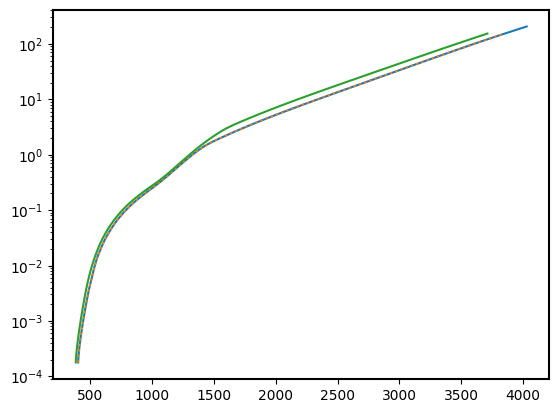

In [104]:
#check that it worked:
#plt.semilogy( tdiam, pdiam )
#plt.semilogy( tdiam_bob[ temps, gravs, fseds, : ] , p_bobs[ temps, gravs, fseds, : ] , linestyle =":")
#dm = plt.semilogy( t_bobs[ temps, gravs, fseds, : ] , p_bobs[ temps, gravs, fseds, : ] )

t0=0
p0=0
f0 = 4
plt.semilogy(  tdiam_bob_init[ t0, p0, f0, : ], pdiam_bob_init[ t0, p0, f0, : ])
plt.semilogy( tdiam_bob[ t0, p0, f0, : ], p_bobs[ t0, p0, f0, : ] , linestyle =":")
dm = plt.semilogy(  t_bobs[ t0, p0, f0, : ], p_bobs[ t0, p0, f0, : ])

#print( len( tt), len(gg), len(np.flip(tdiam_bob-t_bobs,0)))

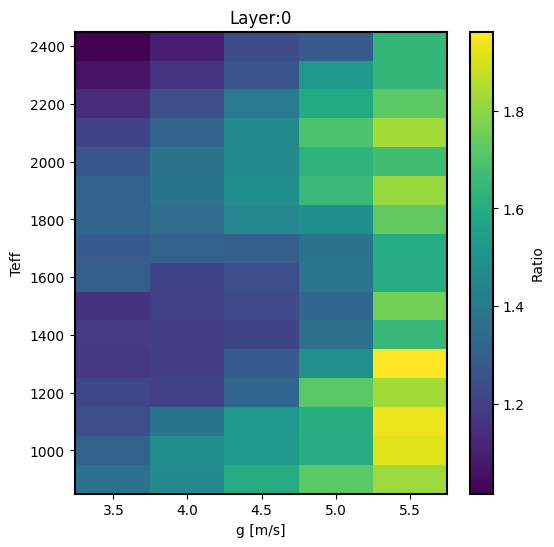

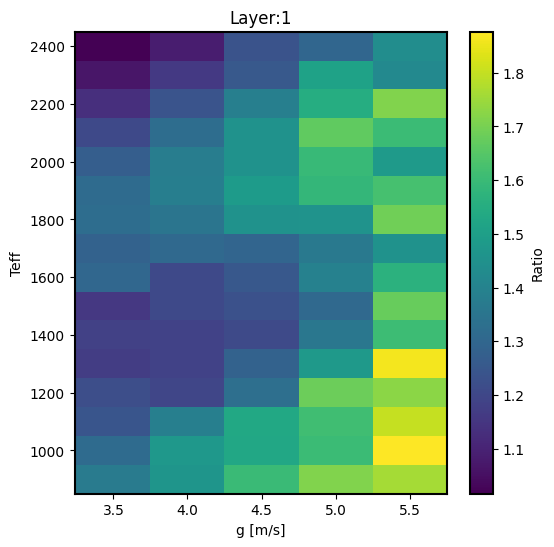

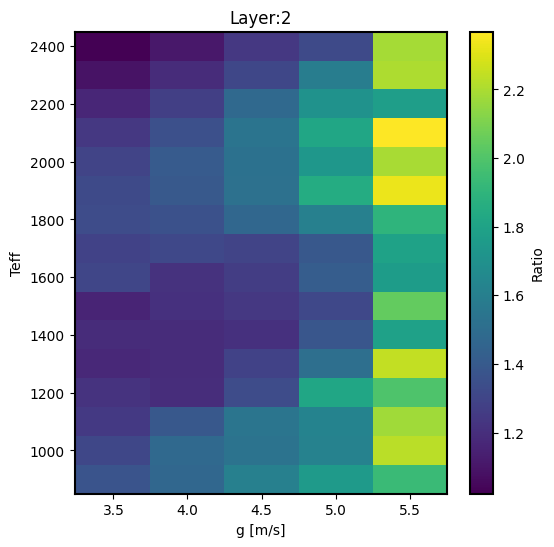

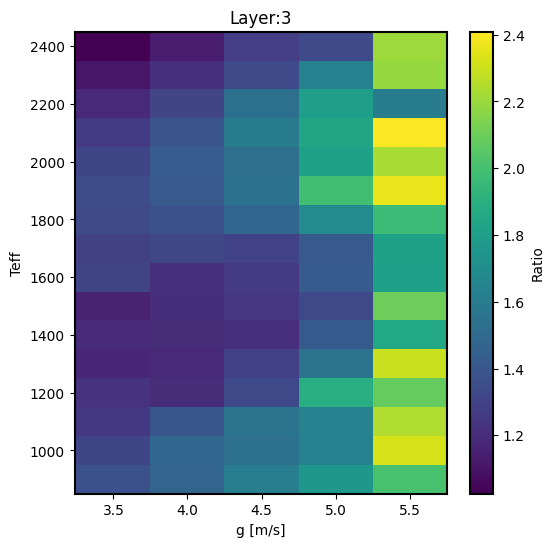

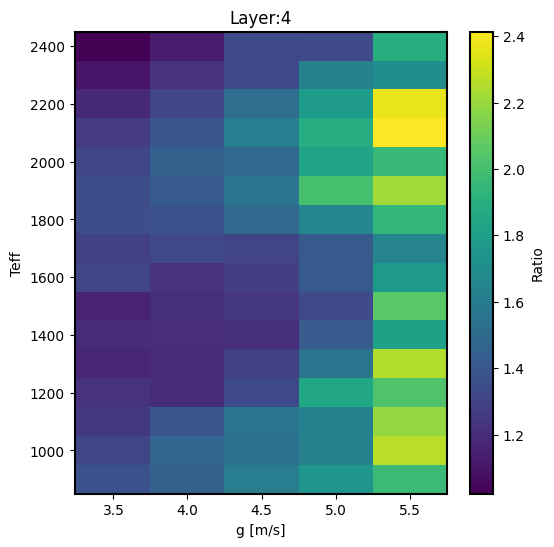

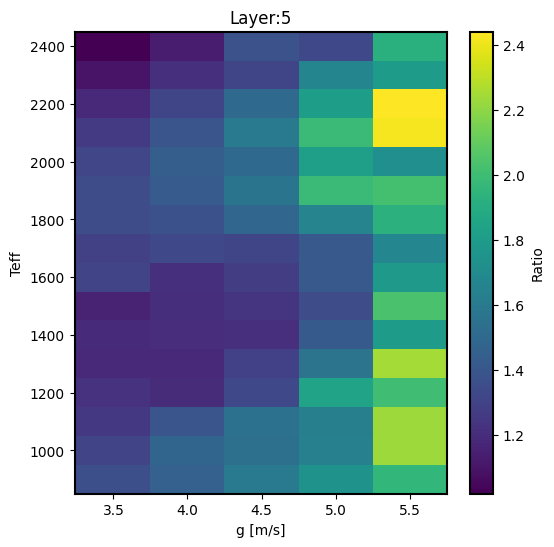

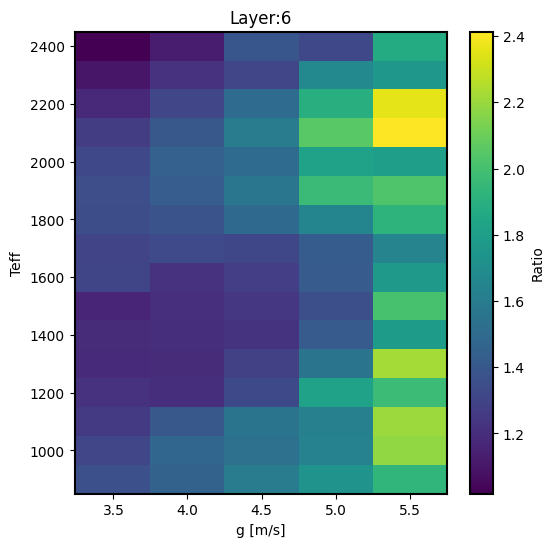

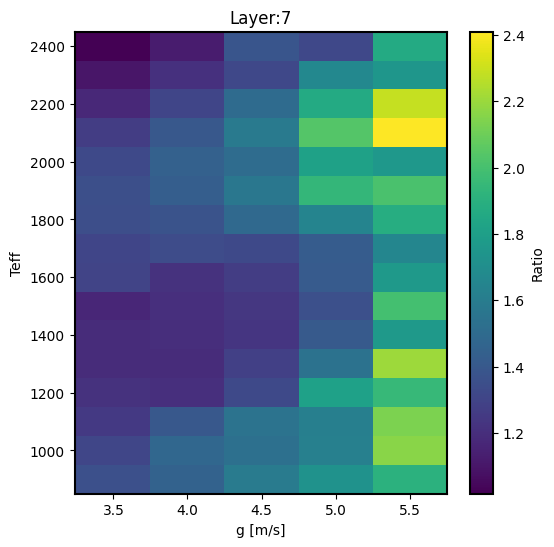

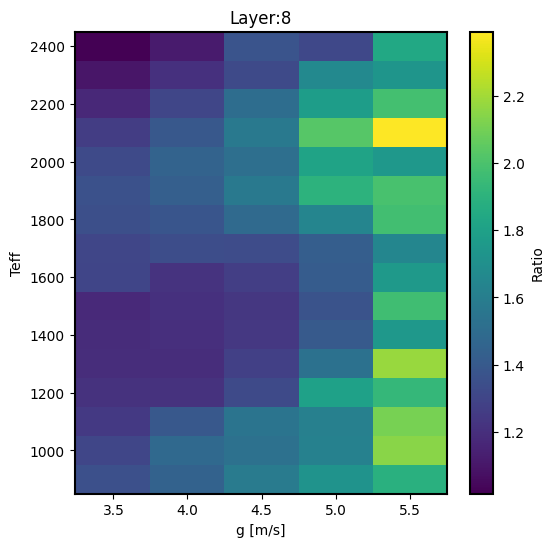

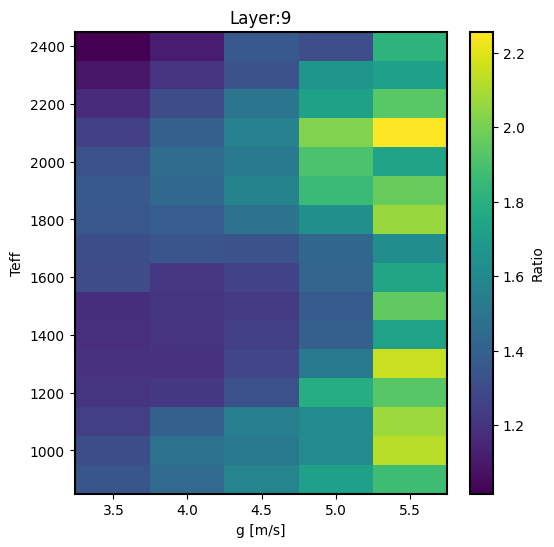

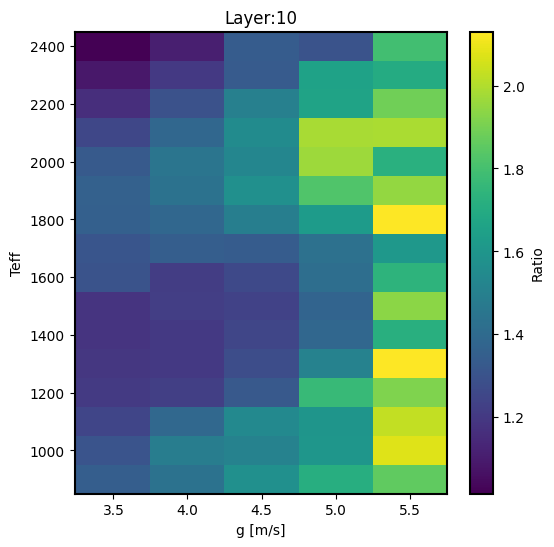

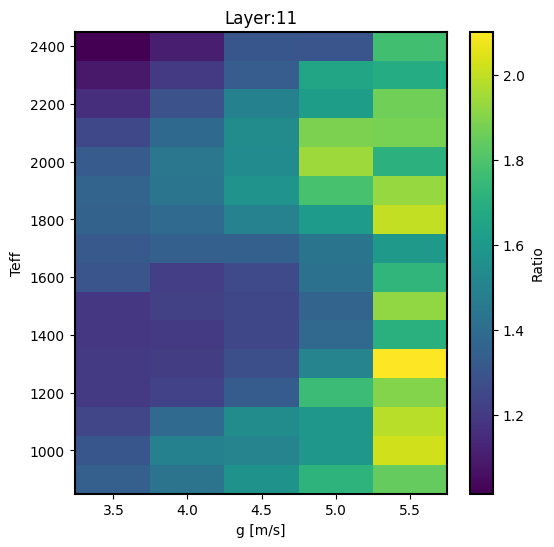

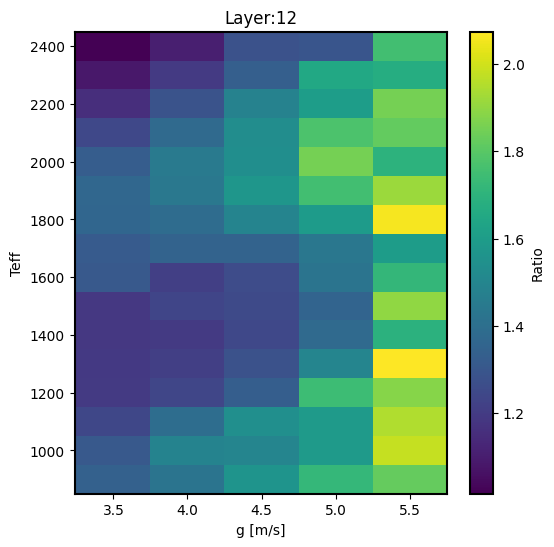

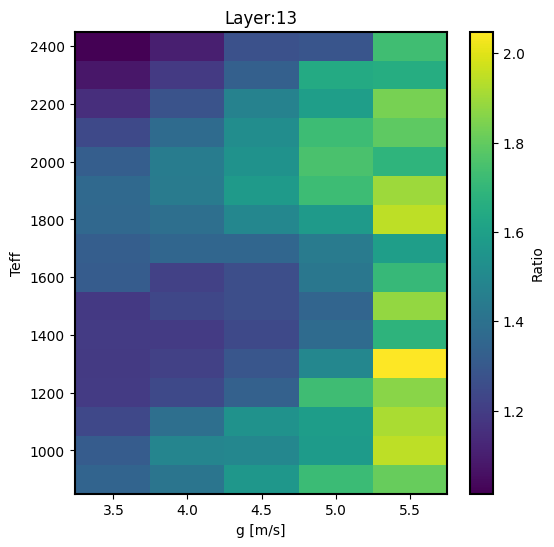

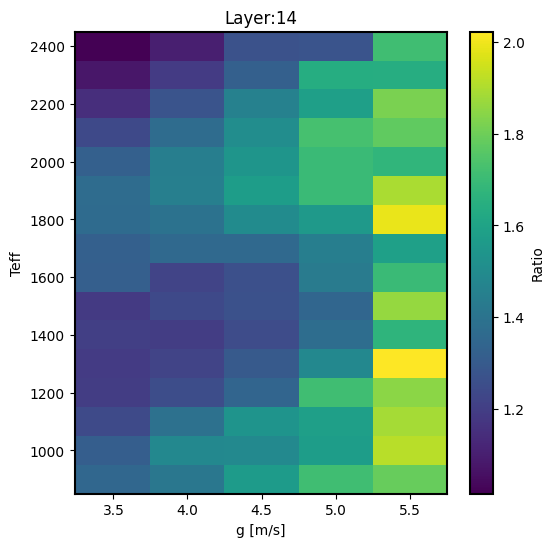

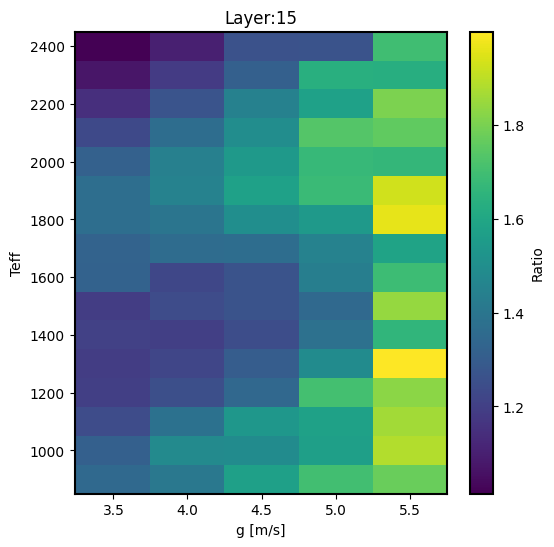

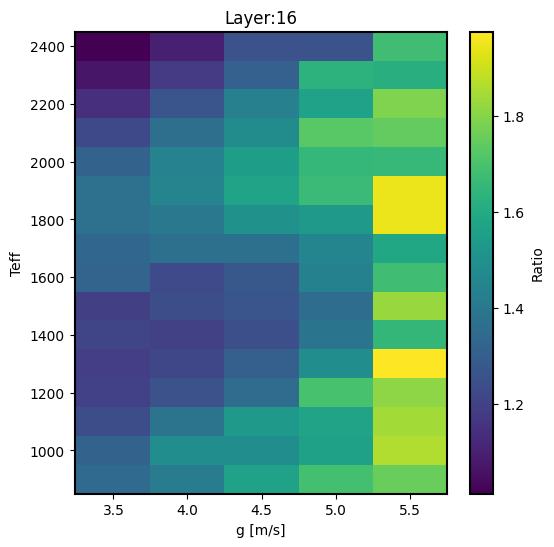

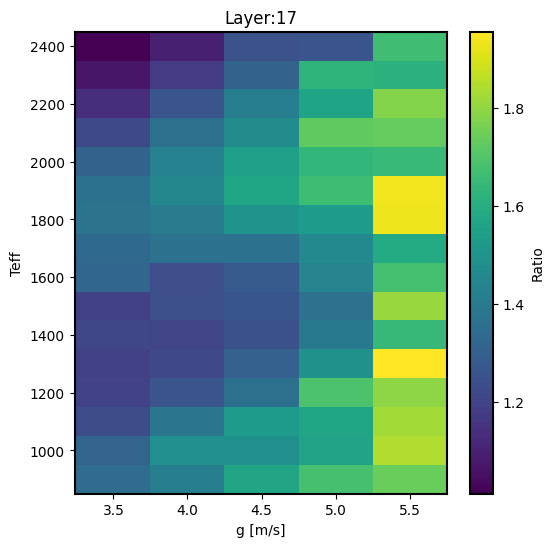

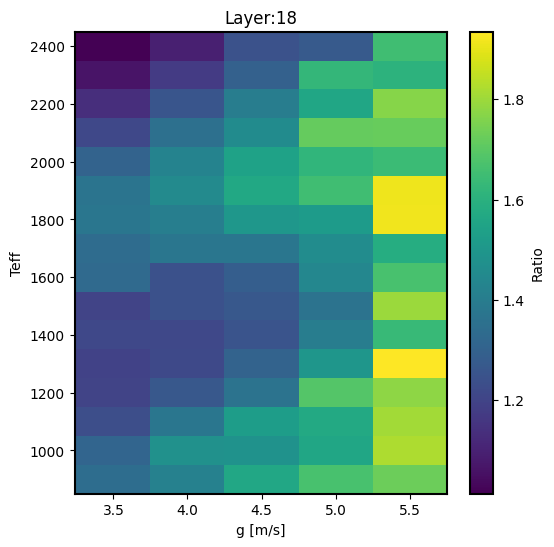

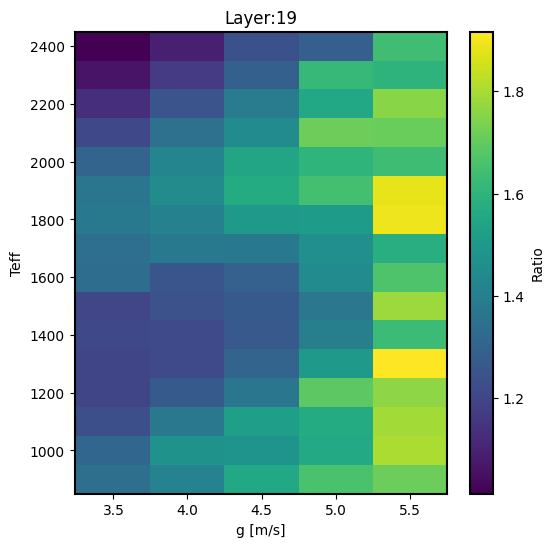

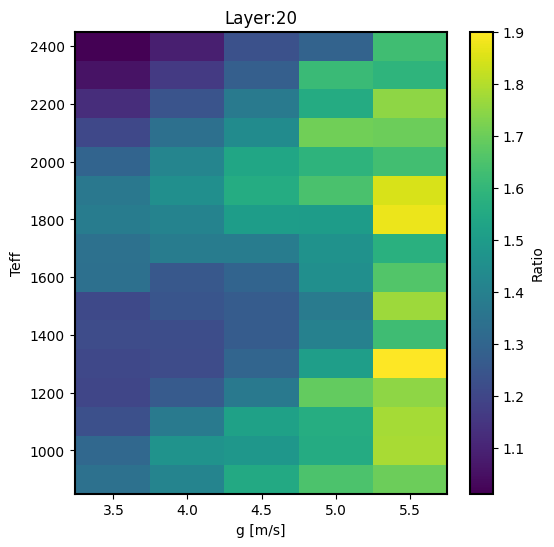

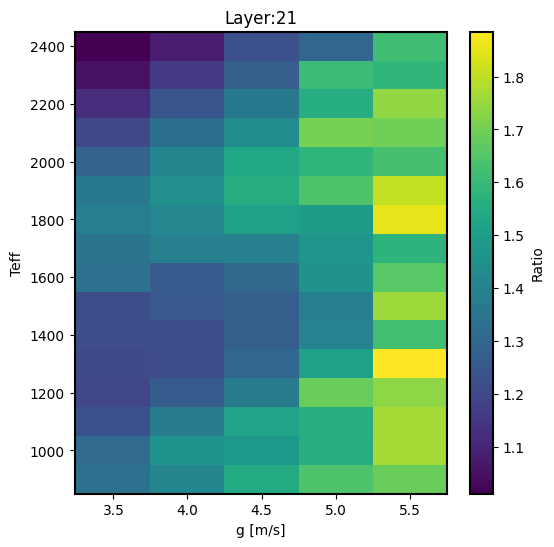

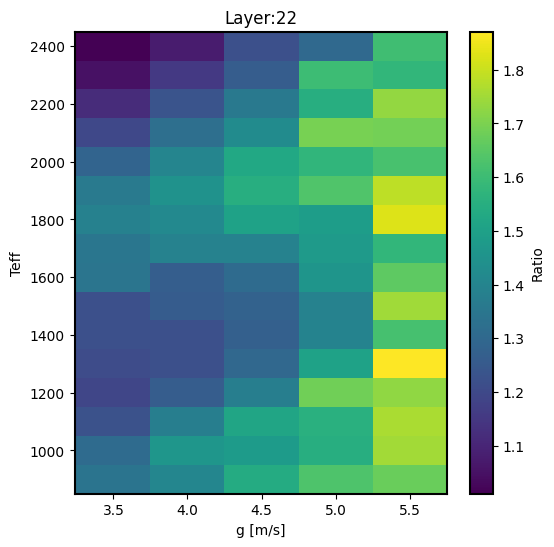

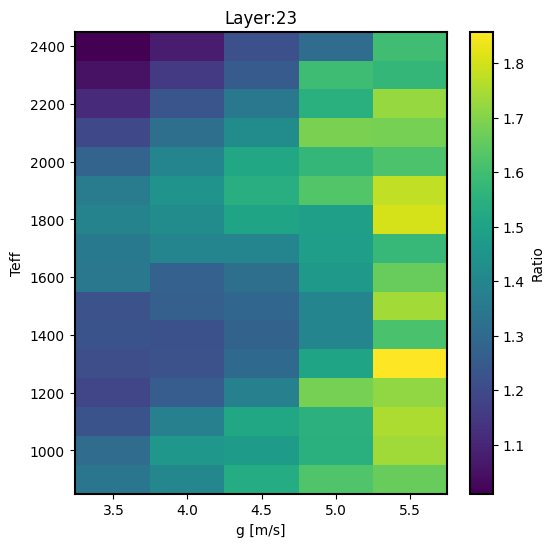

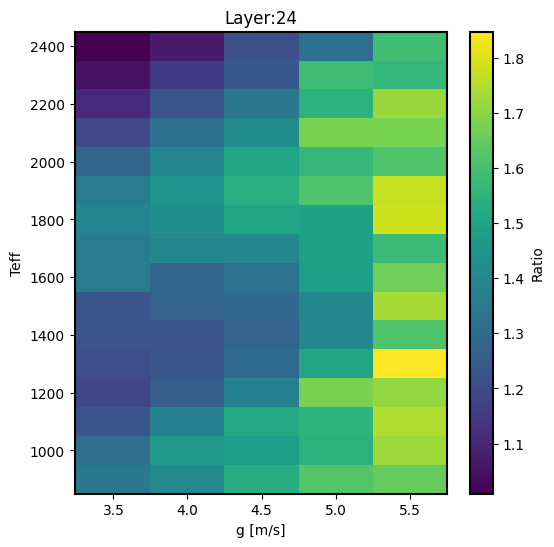

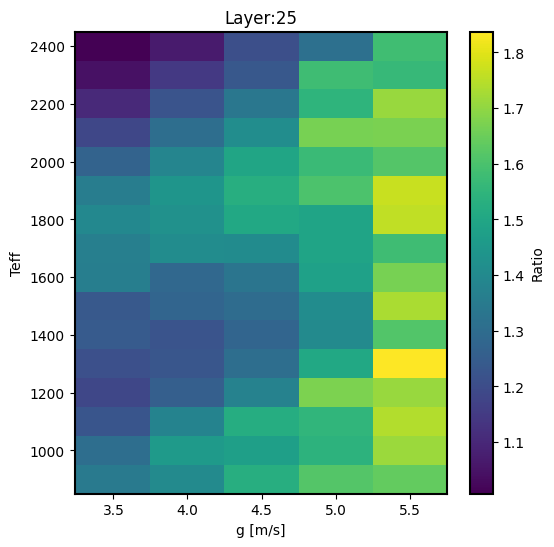

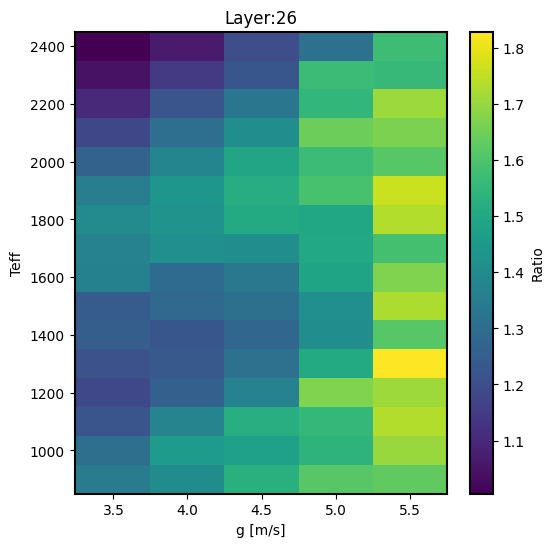

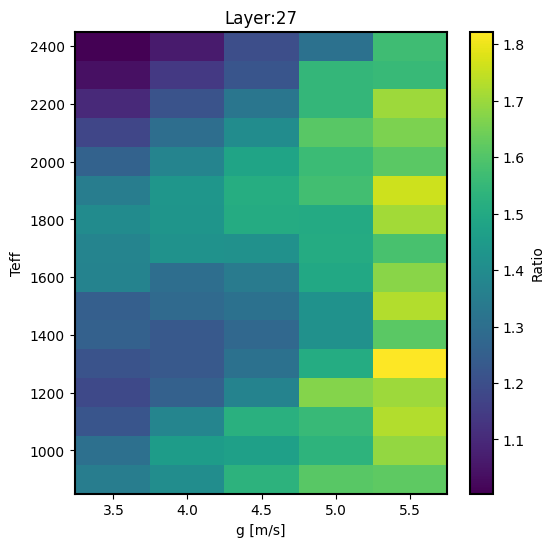

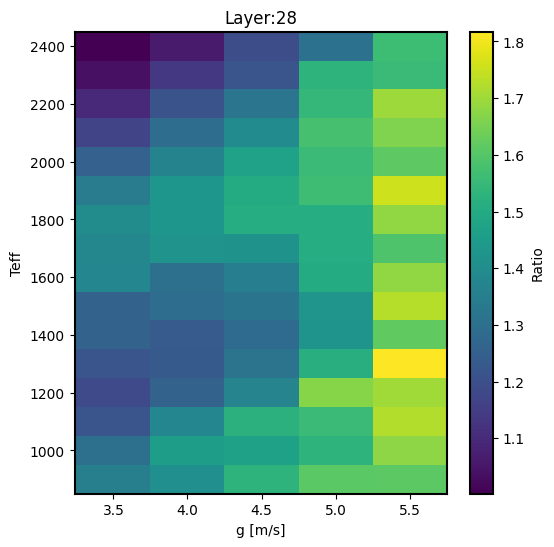

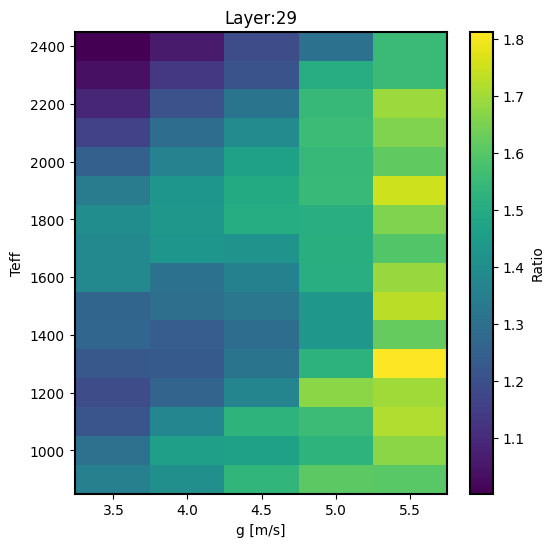

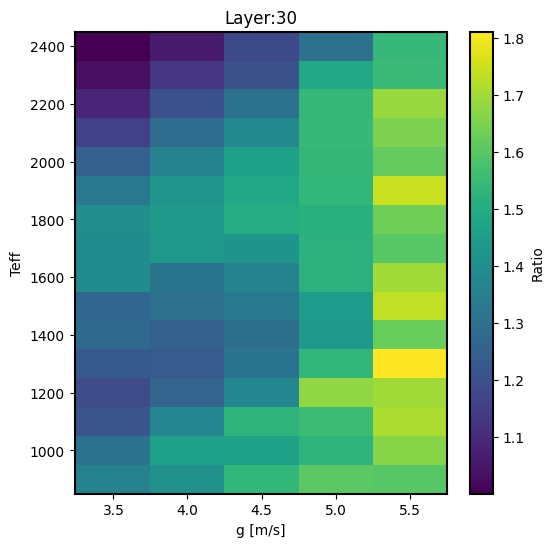

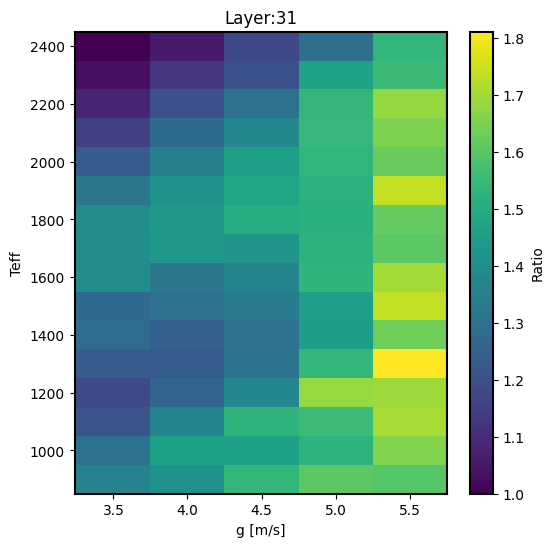

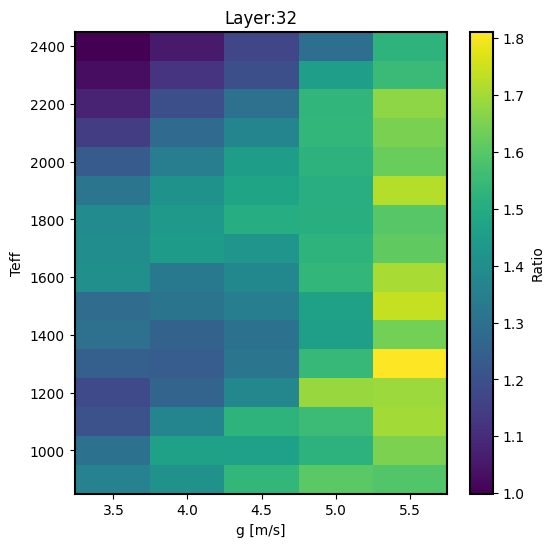

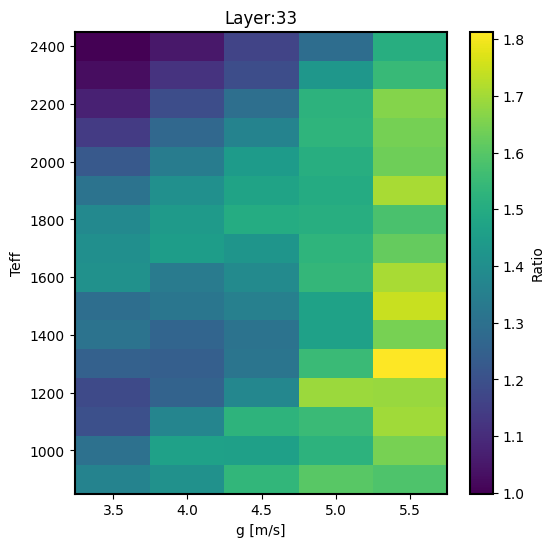

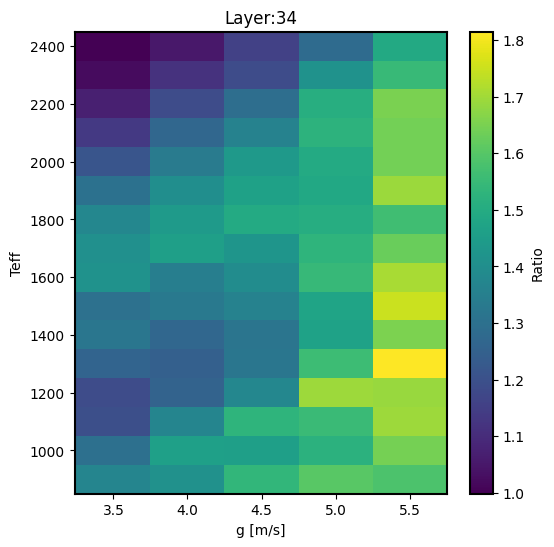

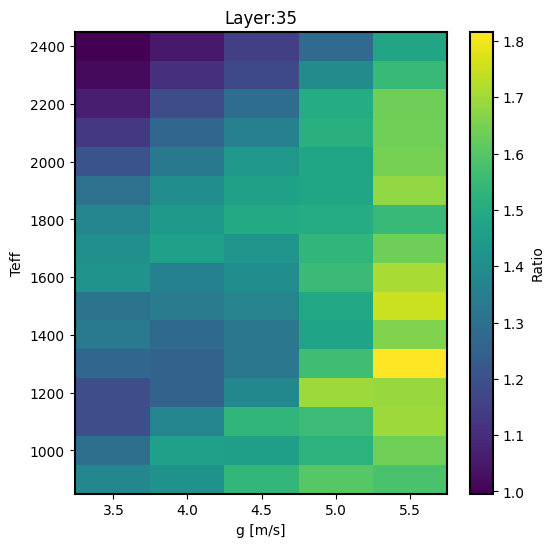

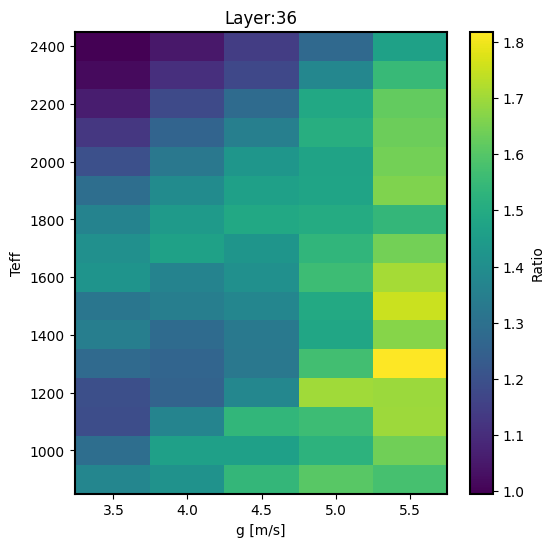

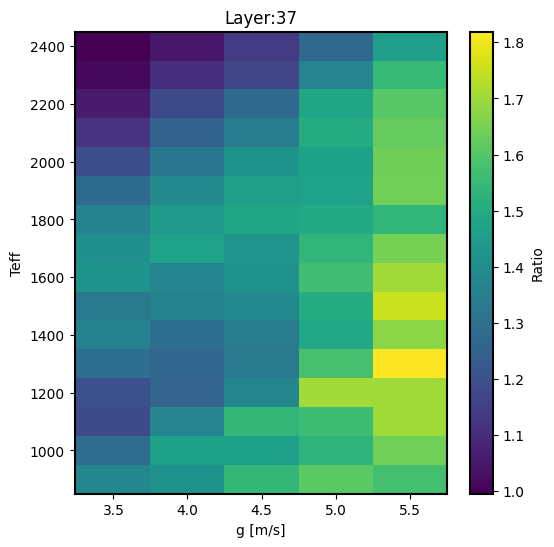

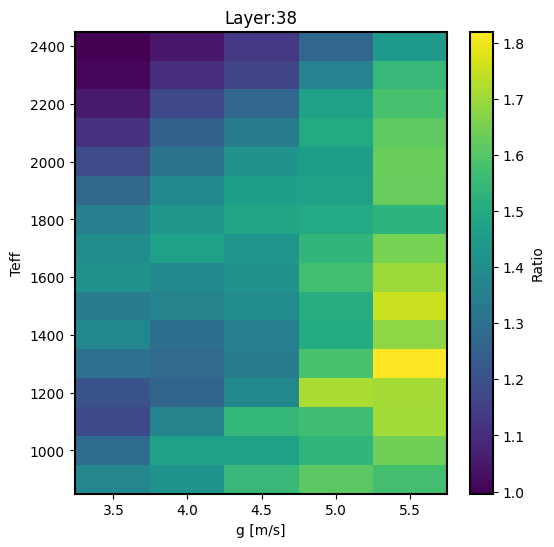

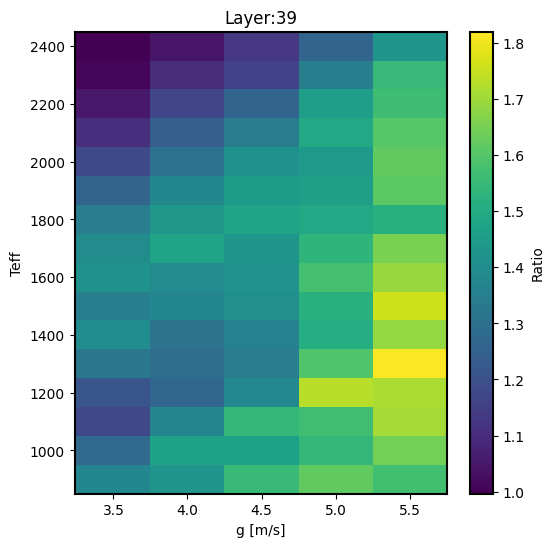

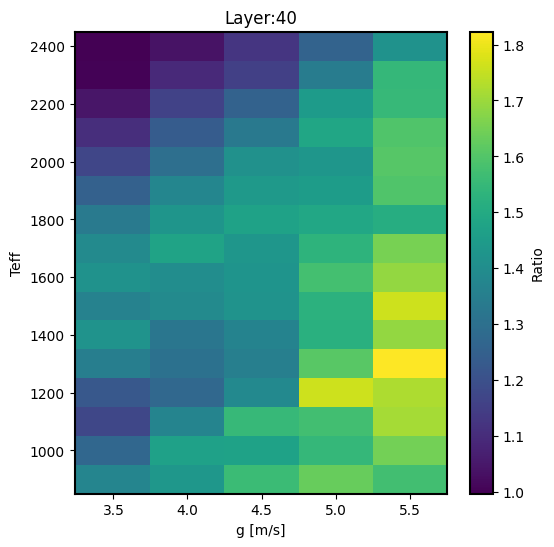

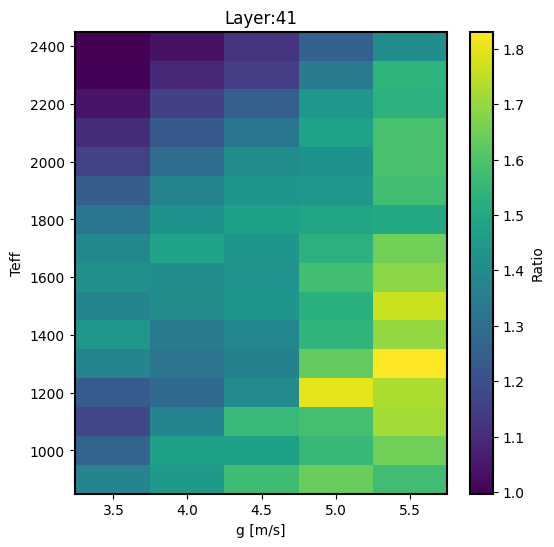

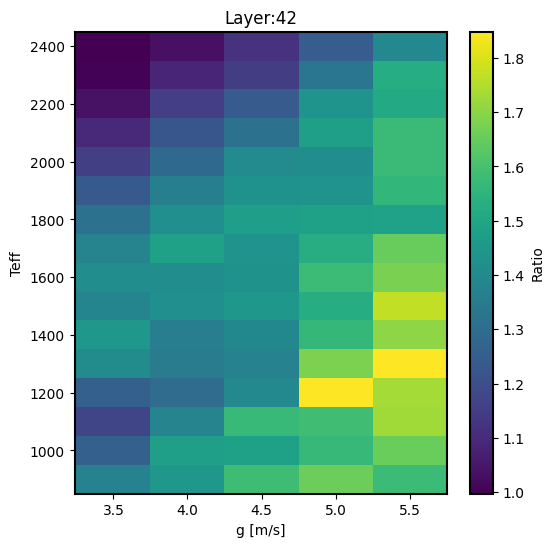

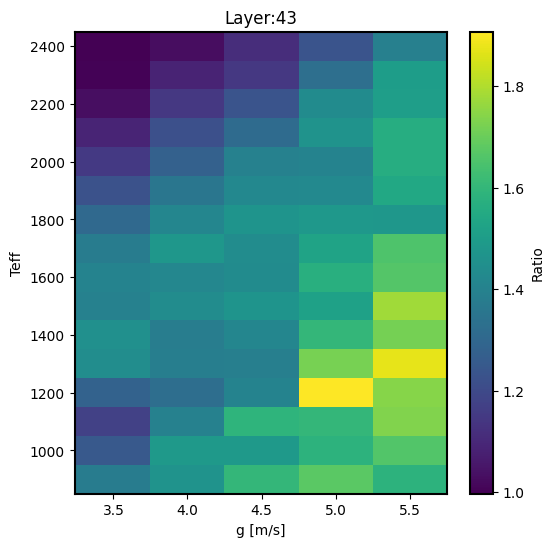

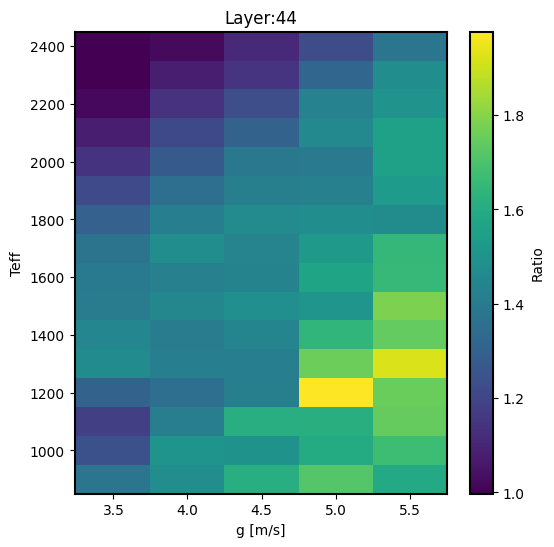

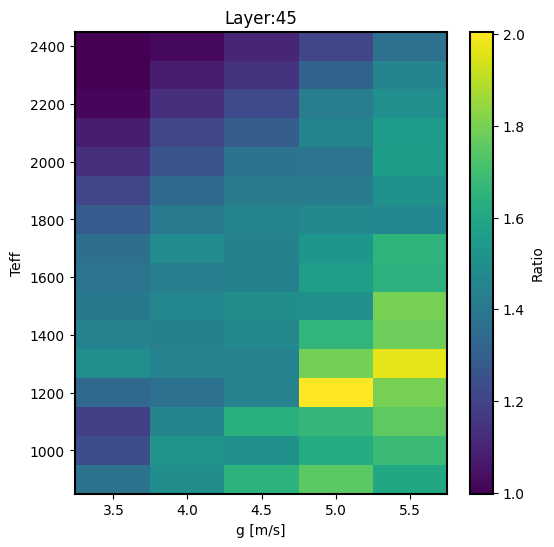

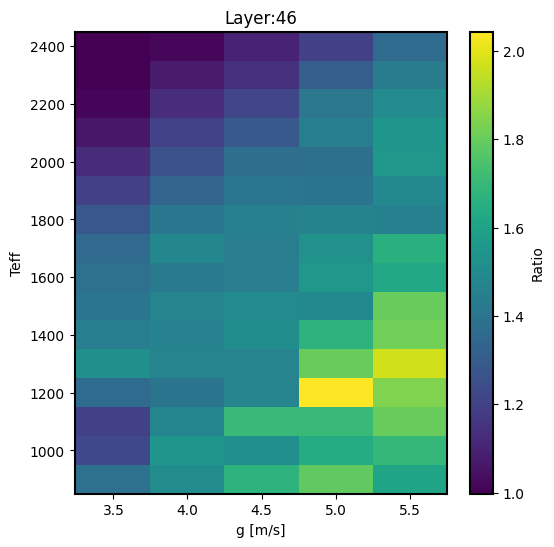

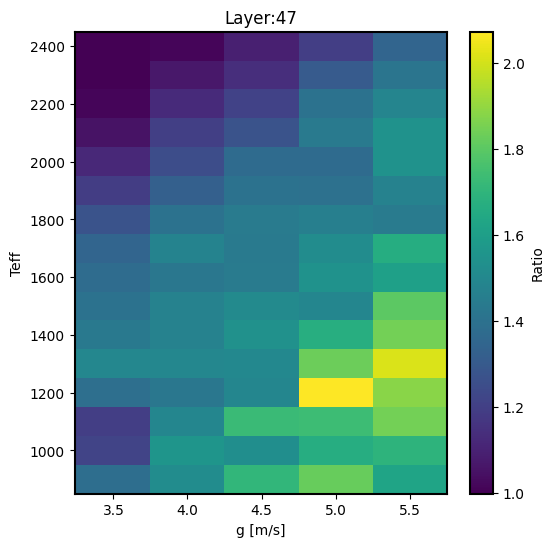

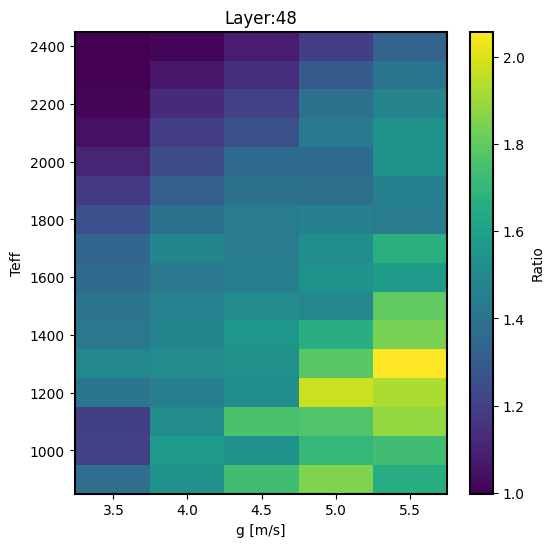

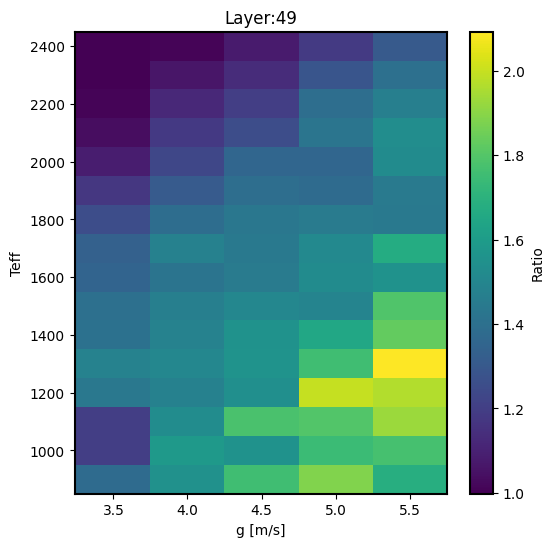

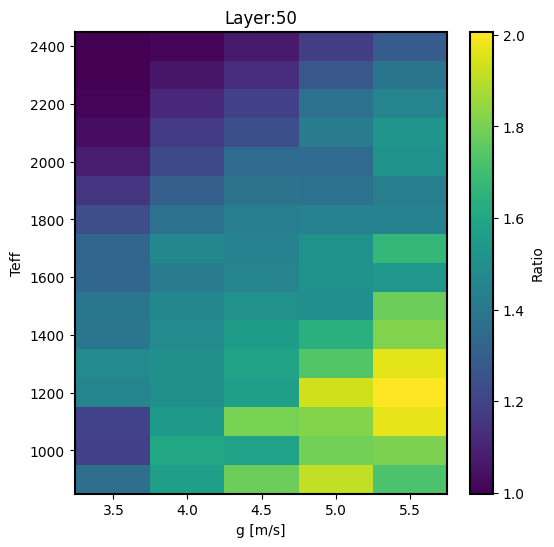

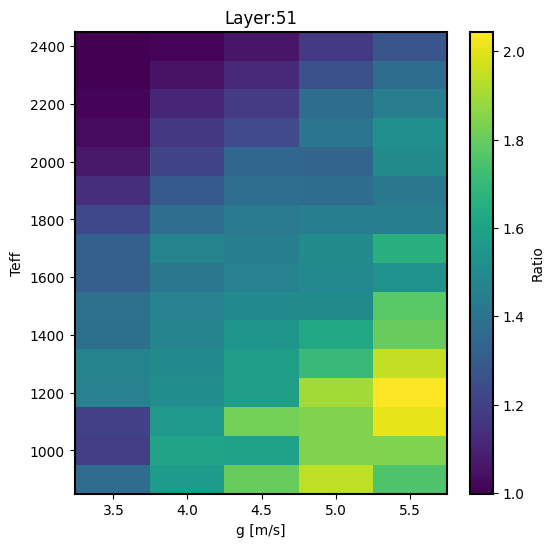

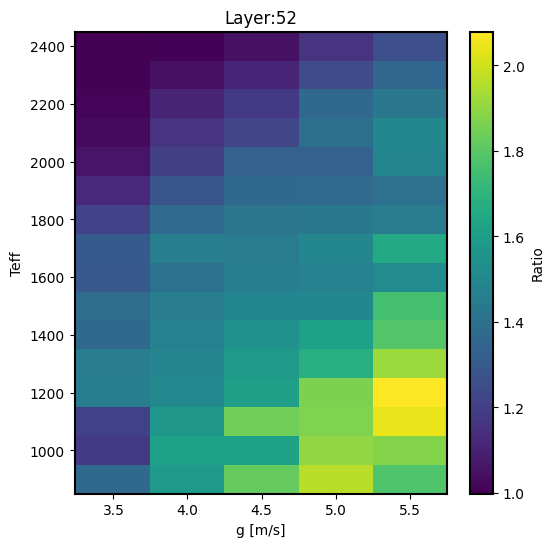

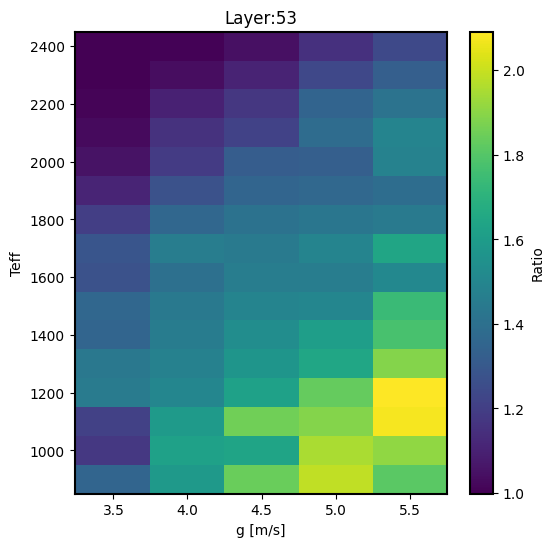

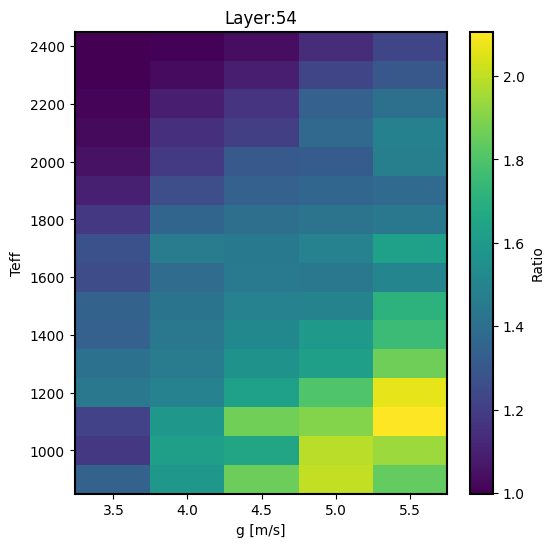

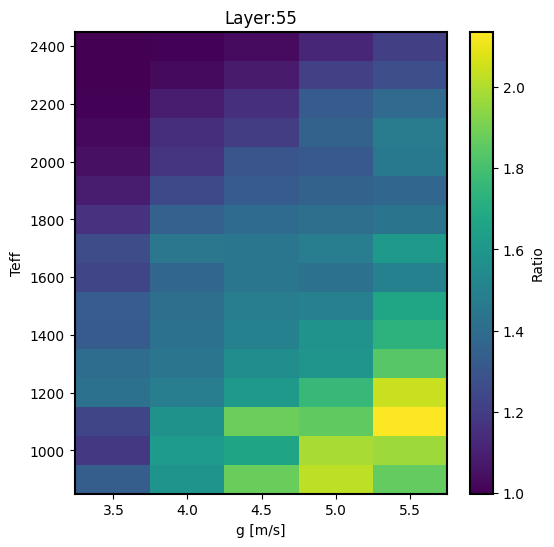

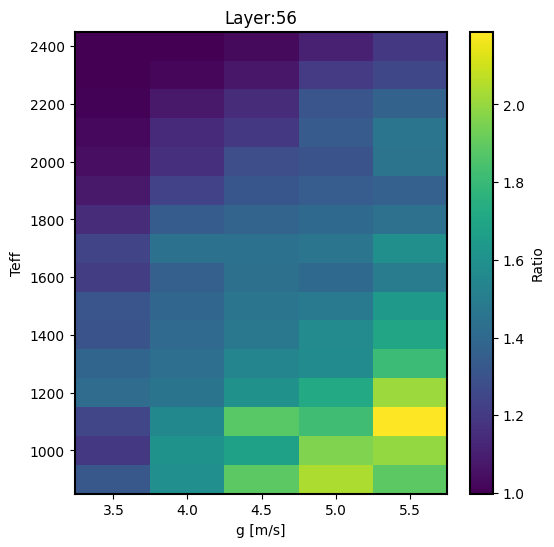

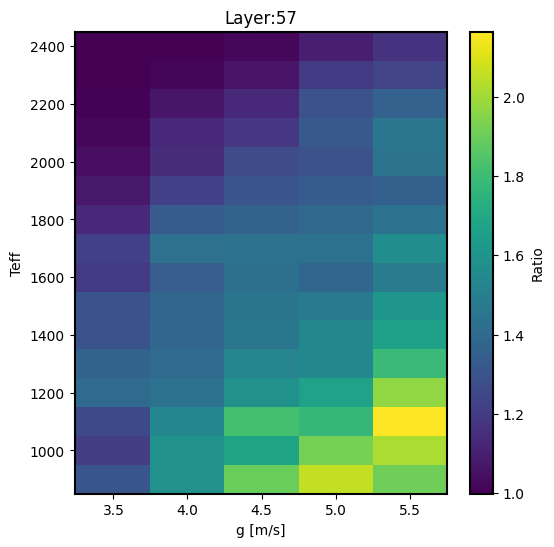

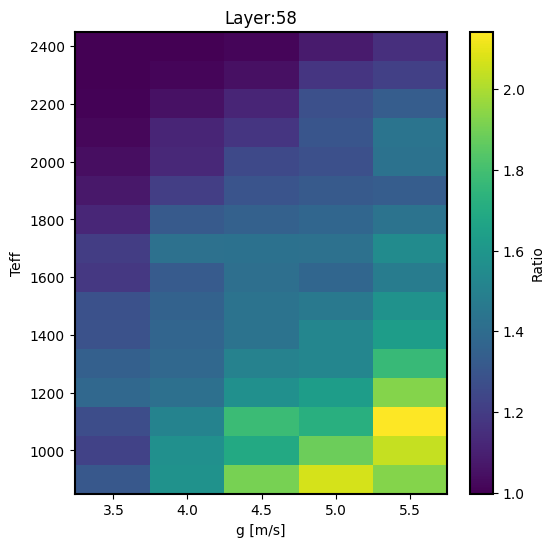

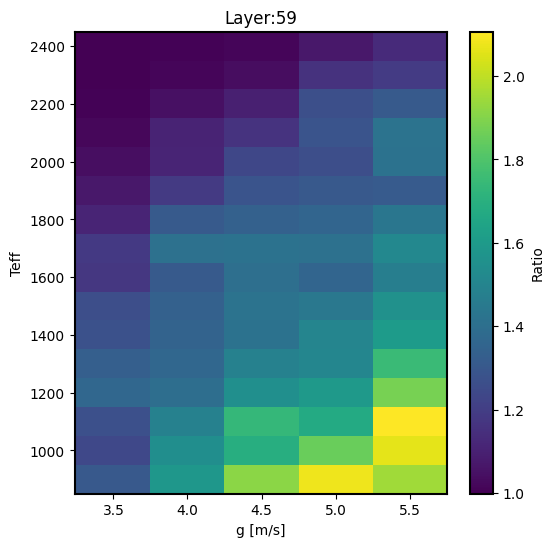

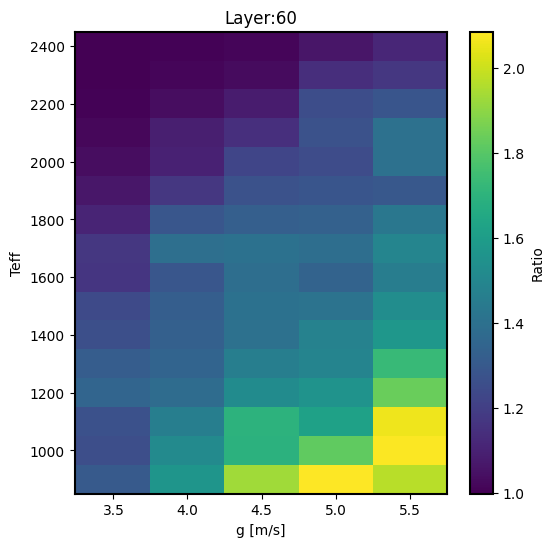

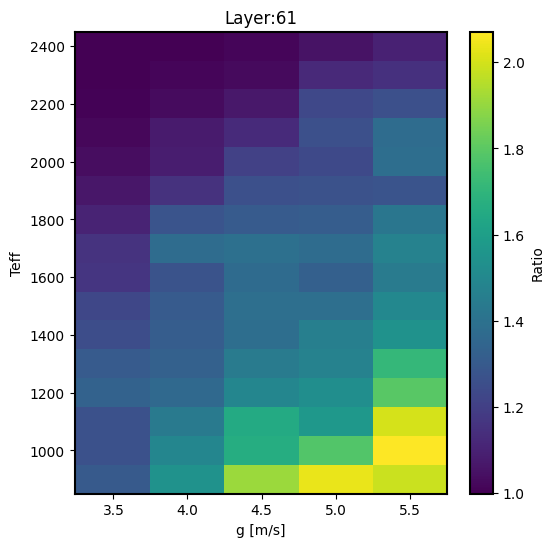

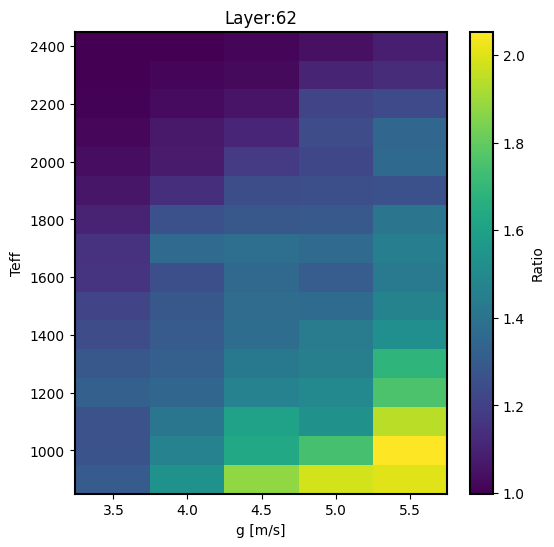

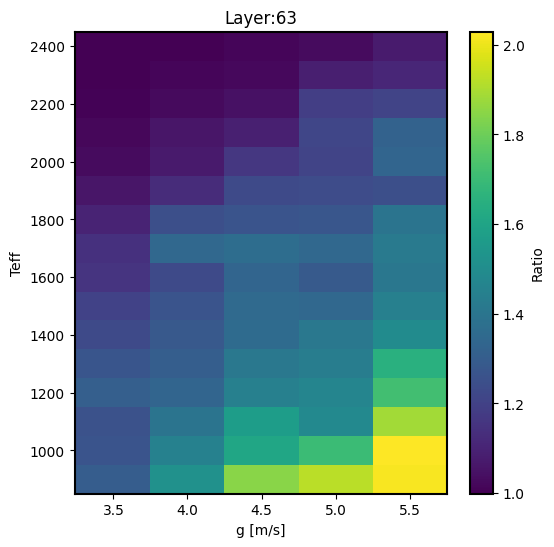

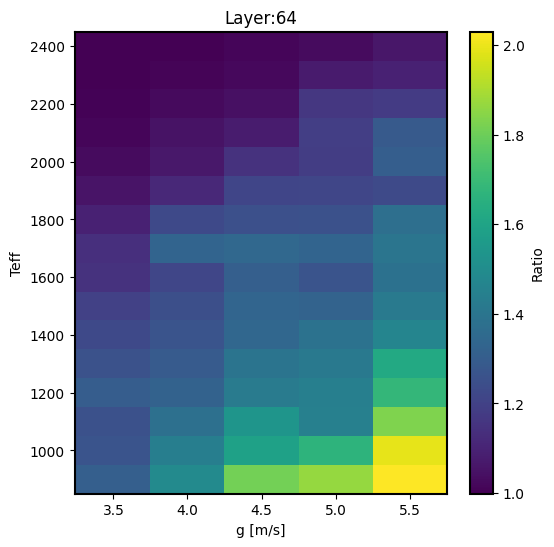

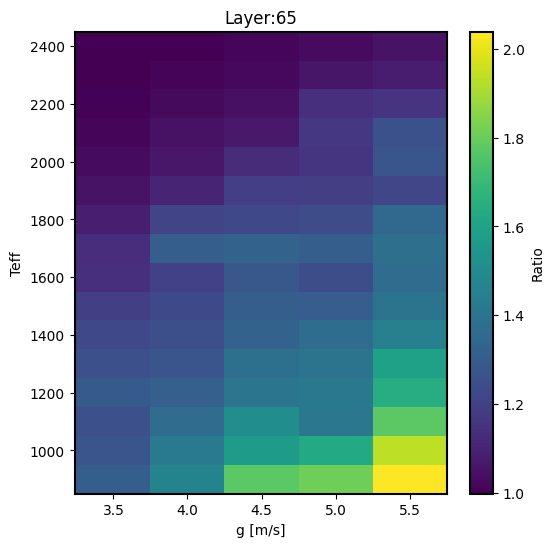

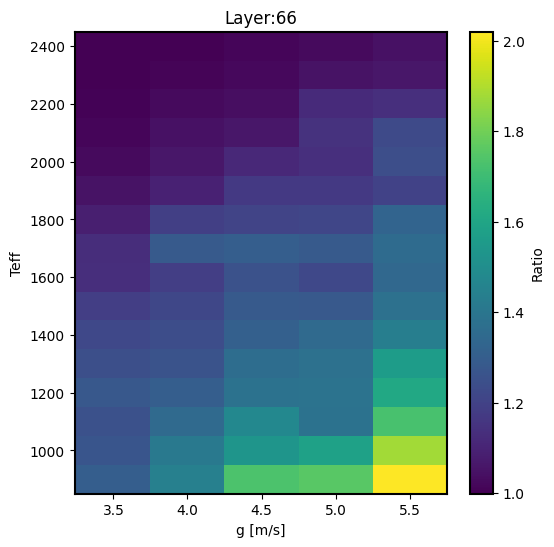

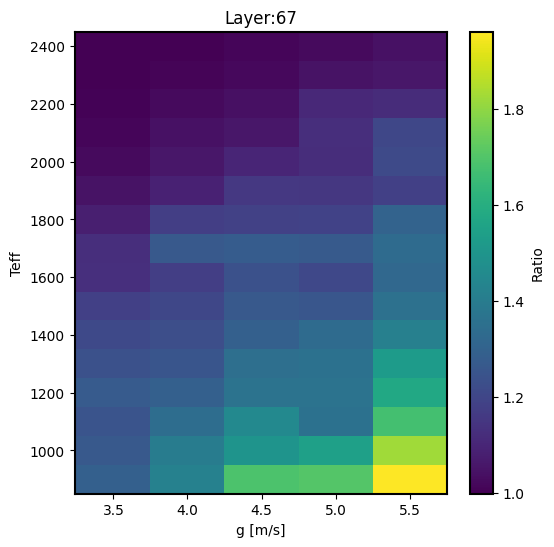

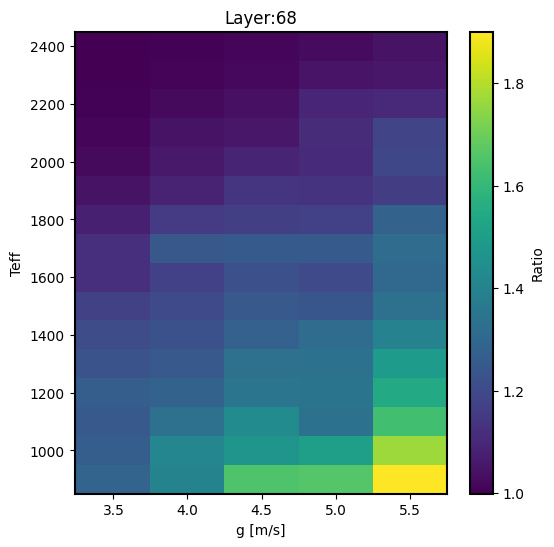

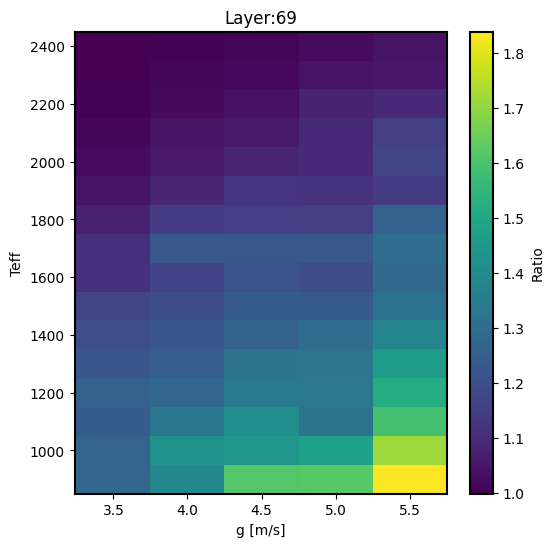

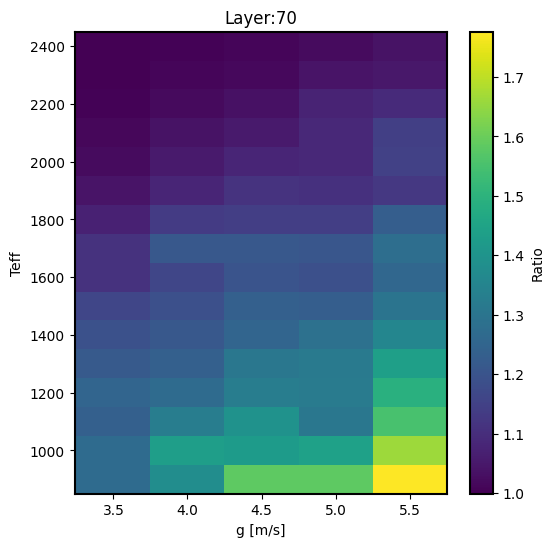

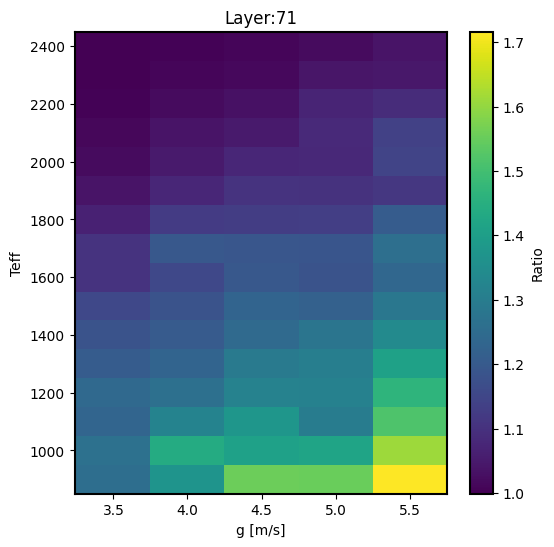

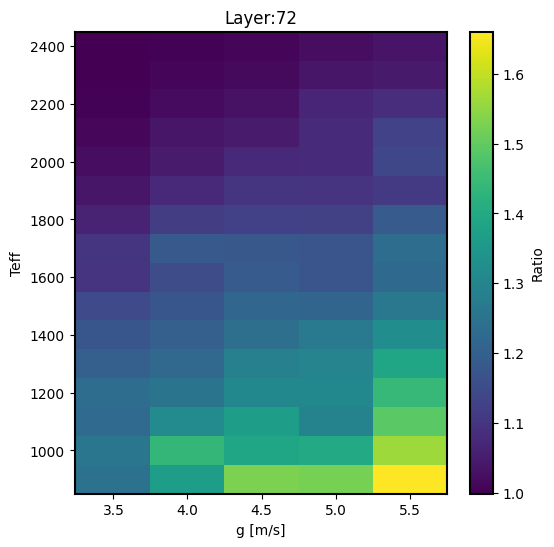

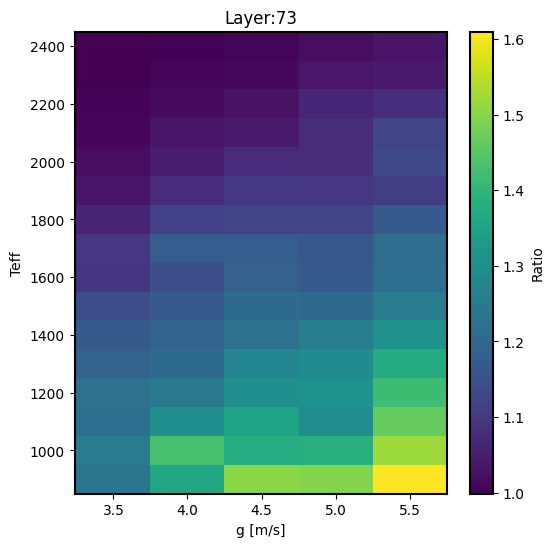

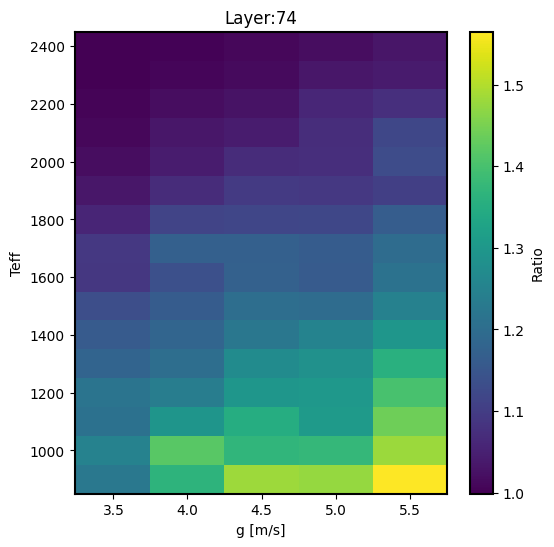

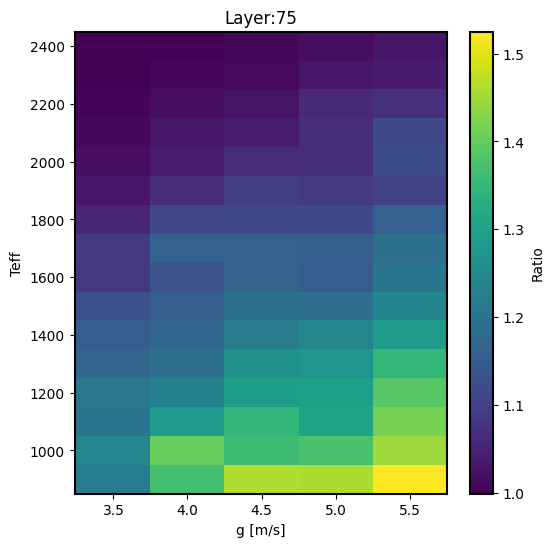

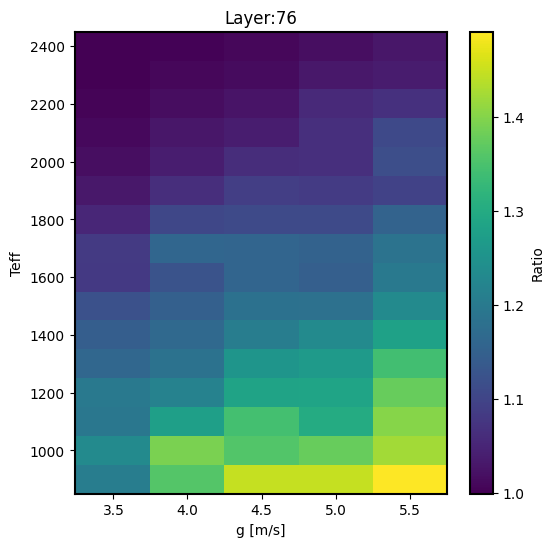

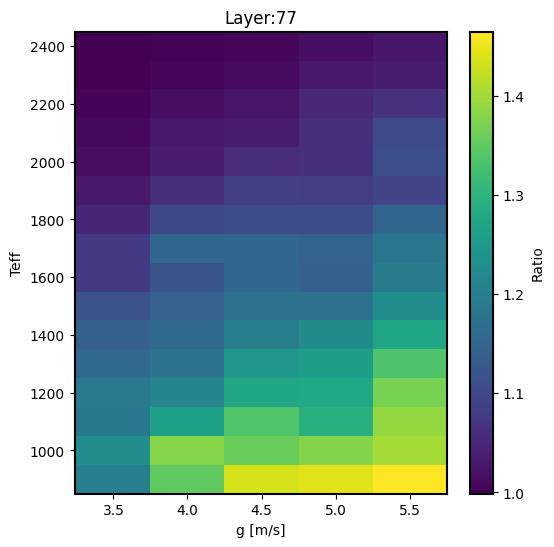

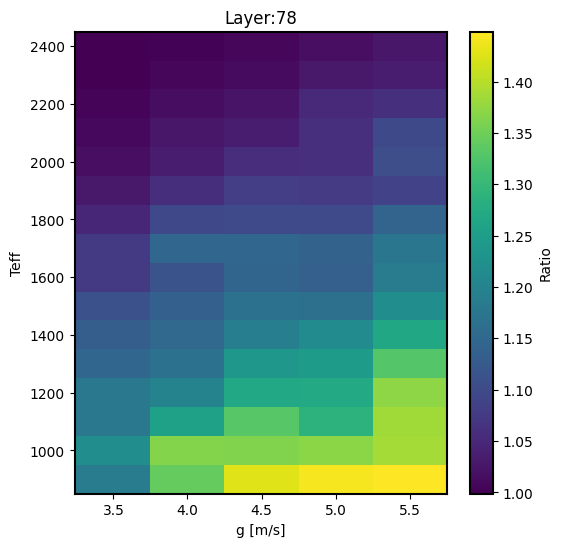

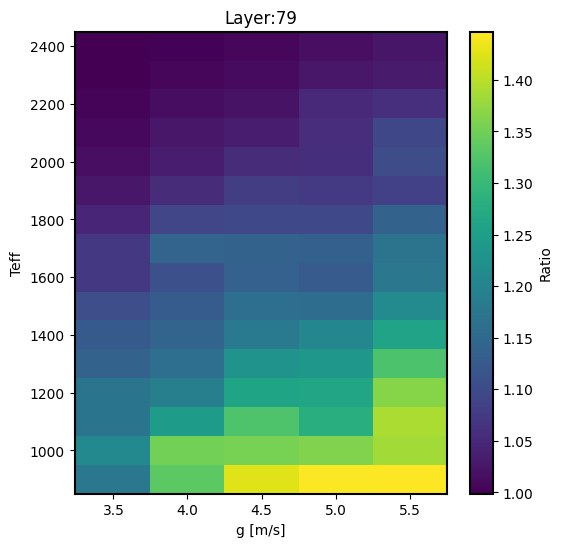

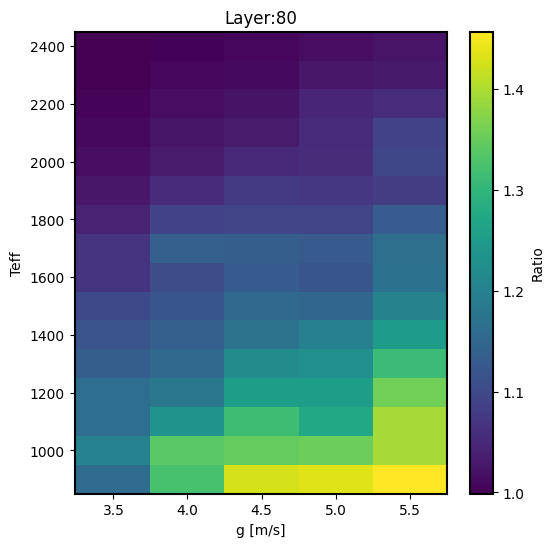

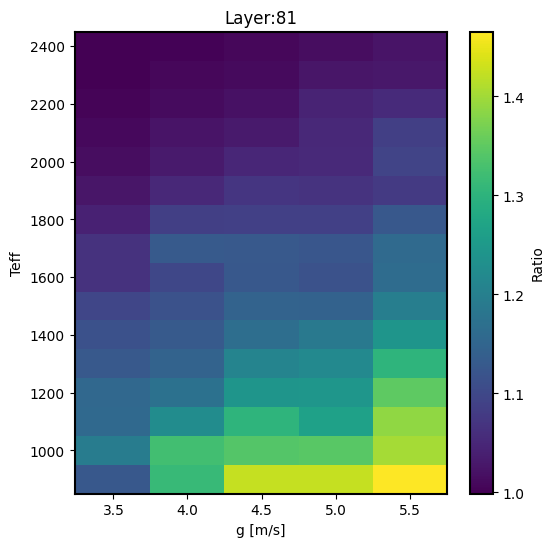

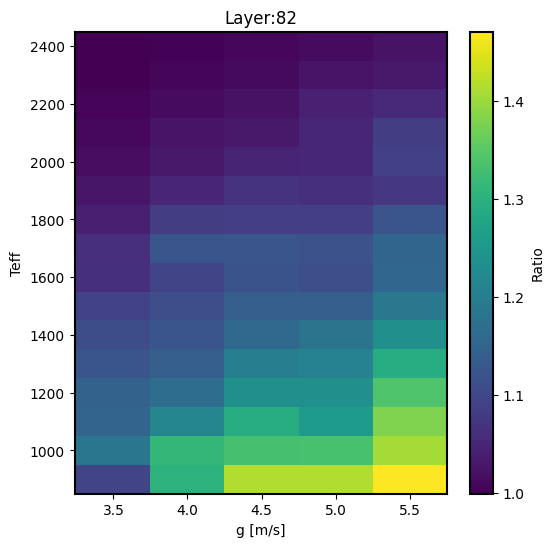

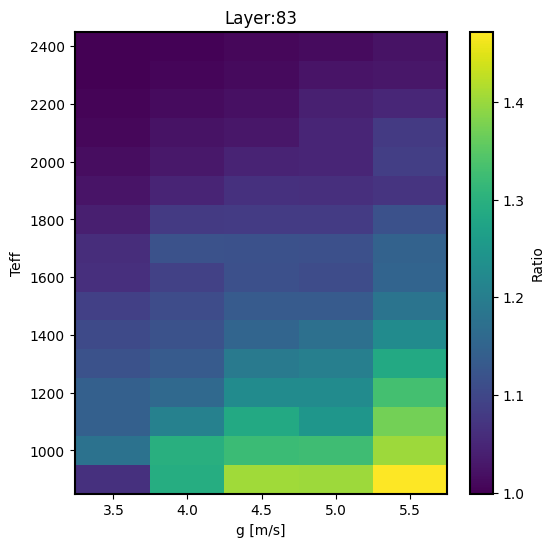

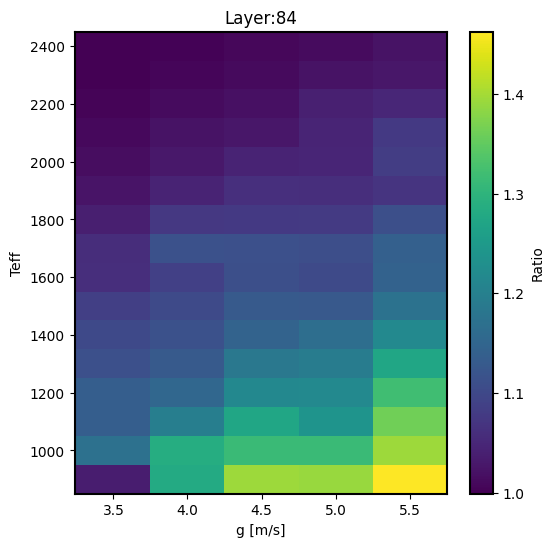

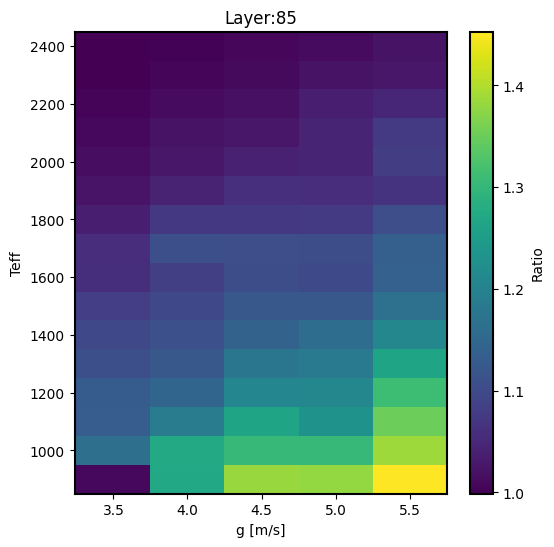

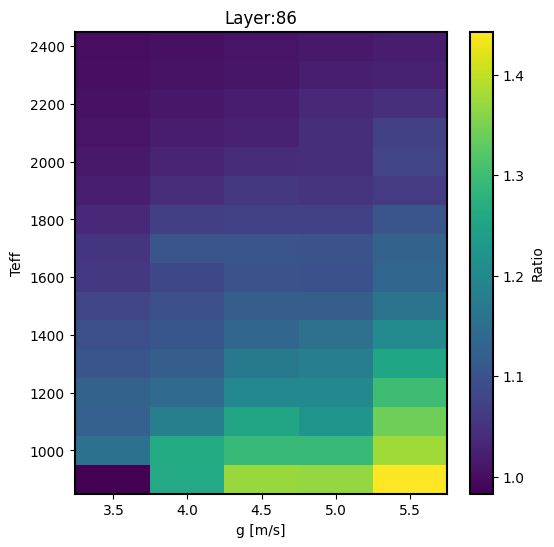

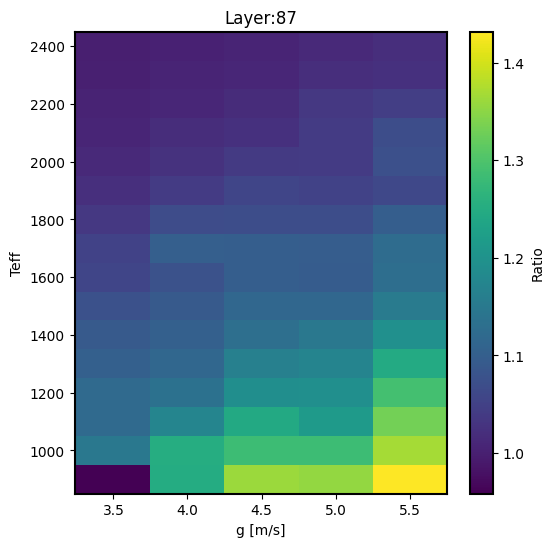

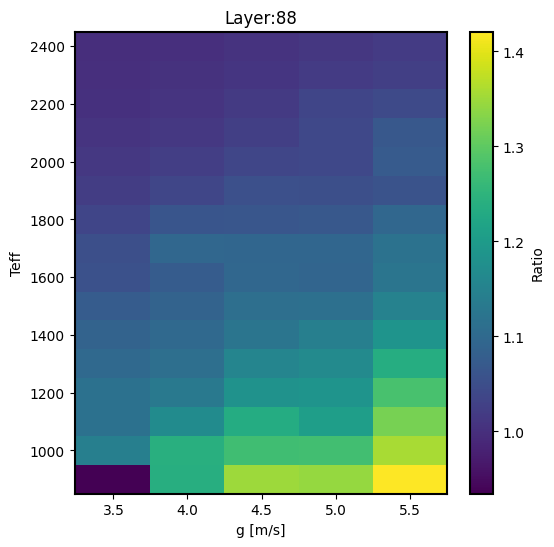

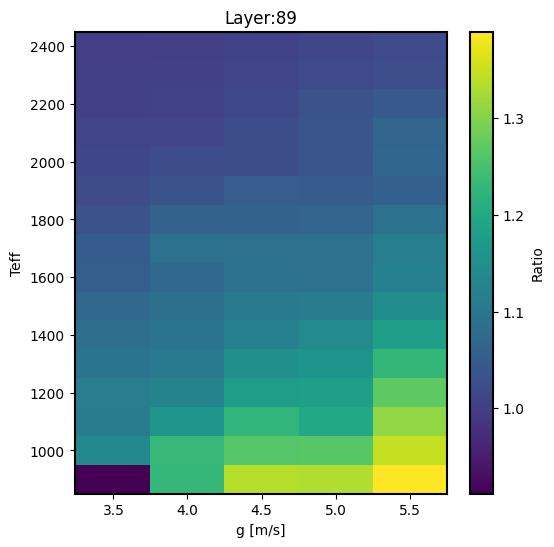

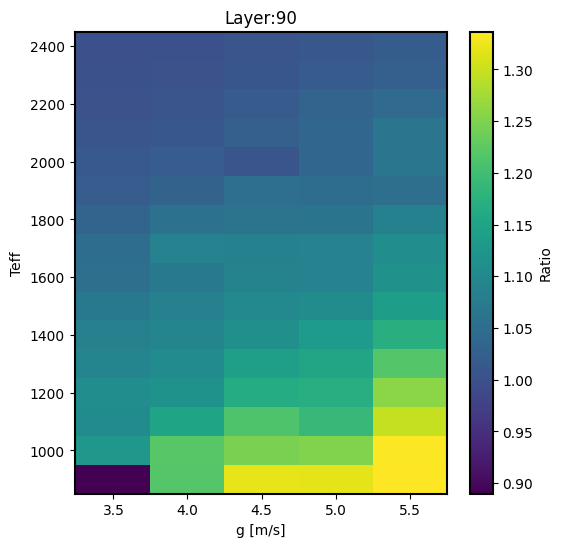

In [122]:
#make contour maps with differences:
ggpl = np.log10(gg*100)


fsed_ch = 0
p_ch    = 0

for p_ch in range(91):
    fig, ax = plt.subplots( 1,1, figsize = (6,6))

    bounds = np.linspace( 0, 240, 400)
    norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
    pcm = ax.pcolormesh( ggpl,tt , tdiam_bob[ :, :, fsed_ch, p_ch] / t_bobs [ :, :, fsed_ch, p_ch ])#, 
#                 cmap = 'RdYlBu')
    plt.title('Layer:'+str( p_ch ) )
    plt.colorbar(pcm, label='Ratio')
    plt.xlabel('g [m/s]')
    dm = plt.ylabel('Teff')
    plt.show()

    

#fig, ax = plt.subplots( 1,1, figsize = (6,6))

#bounds = np.linspace( 0, 240, 400)
#norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)

#pcm = ax.contourf( ggpl,tt , tdiam_bob[ :, :, fsed_ch, p_ch] / t_bobs [ :, :, fsed_ch, p_ch ], 
#                 cmap = 'RdYlBu')
#plt.colorbar(pcm, label='Ratio')

#plt.xlabel('g [m/s]')
#dm = plt.ylabel('Teff')


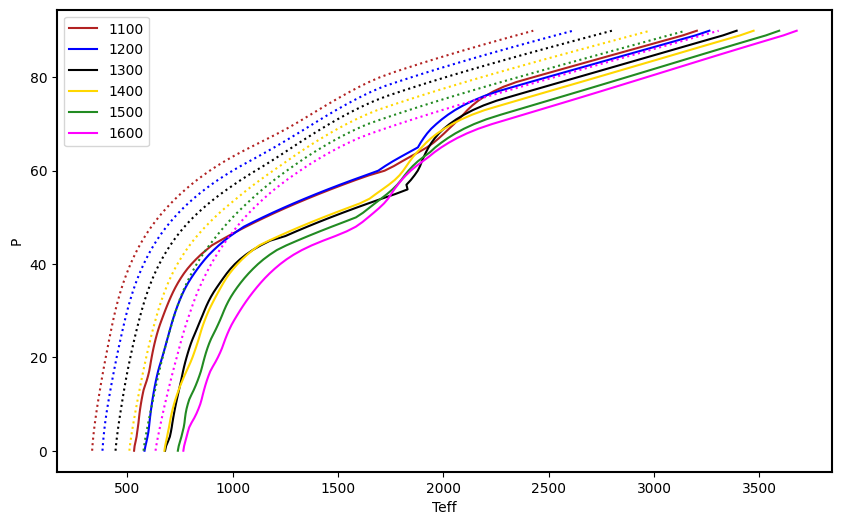

In [124]:
#do some plots of all layers (aka TP) across properties where it shows up yellow
ggpl = np.log10(gg*100)

#for p_ch in range(91):
 #   
#    pcm = ax.pcolormesh( ggpl,tt , tdiam_bob[ :, :, fsed_ch, p_ch] / t_bobs [ :, :, fsed_ch, p_ch ])#, 
#                 cmap = 'RdYlBu')
#fig, ax = plt.subplots( 1,1, figsize = (6,6))
#bounds = np.linspace( 0, 240, 400)
#norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)

tplots = [2,3, 4, 5, 6, 7]
clrs= ['firebrick', 'blue', 'black', 'gold', 'forestgreen', 'magenta']

fsed_ch = 0
g_ch = 2

plt.figure( figsize = (10, 6))

for mm in range(len(tplots)):
    plt.plot(tdiam_bob[ mm, g_ch, fsed_ch, :], np.arange( len(p_bobs[ mm, g_ch, fsed_ch, :])), color= clrs[ mm ], label = tt[tplots[mm]])
    plt.plot(t_bobs[ mm, g_ch, fsed_ch, :], np.arange( len(p_bobs[ mm, g_ch, fsed_ch, :])), clrs[mm], linestyle= ':')


#plt.colorbar(pcm, label='Ratio')
plt.xlabel('Teff')
plt.legend()
dm =plt.ylabel('P')


In [256]:
from astropy.convolution import convolve, convolve_fft
from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans, Box2DKernel

In [232]:
#a1 = np.arange(900, 2505, 5)#np.round(np.arange(3.5, 5.52, 0.05), decimals = 3) 

#a2 = tt #np.round(np.log10(gg*100), decimals =1 ) #np.round(ggpl, decimals = 1) 

#inds = np.zeros( len(a1) )

#print(a1)
#print(a2)

#for ii in range( len(a2)):
#    print(a2[ii])
#    inds[ii] = np.where( a1 == a2[ii] )[0][0]

#print(inds)




array([3.5, 4. , 4.5, 5. , 5.5])

In [388]:
ggpl = np.round(np.log10(gg*100), decimals =1 )#np.log10(gg*100)


fsed_ch = 0
p_ch    = 60

#make the finer grid and make a new image that has NaNs where we don't have a data point:
tnew = np.arange(900, 2405, 5)
gnew = np.round(np.arange(3.5, 5.54, 0.05), decimals = 3)  #np.floor(10**np.arange(3.5, 5.52, 0.05)/100)

inxtrp = np.empty((len(gnew),len(tnew),))
inxtrp[:] = np.nan


#make stupid code to find the indices where tnew/gnew match the old tg grid:
indst = np.zeros( len(tt), dtype = int )
indsg = np.zeros( len(ggpl), dtype = int )

for ii in range( len(tt)):
    indst[ii] = np.where( tnew== tt[ii] )[0][0]

for ii in range( len(ggpl)):
    
    indsg[ii] = np.where( gnew== ggpl[ii] )[0][0]

    
img = tdiam_bob[ :, :, fsed_ch, p_ch] / t_bobs [ :, :, fsed_ch, p_ch ]
    
iin = 0 
for ii in indst:
    jin = 0
    for jj in indsg:
        inxtrp[ jj, ii ] = img[ iin, jin ]
        jin +=1
    iin +=1

inxtrp = np.swapaxes(inxtrp,0,1) 

# for i in range(len(gnew)):
#    for j in range( len(tnew)):
#        locs = np.where( (tnew[j] == ) )


In [365]:
from scipy.interpolate import RegularGridInterpolator#griddata#CloughTocher2DInterpolator
import itertools

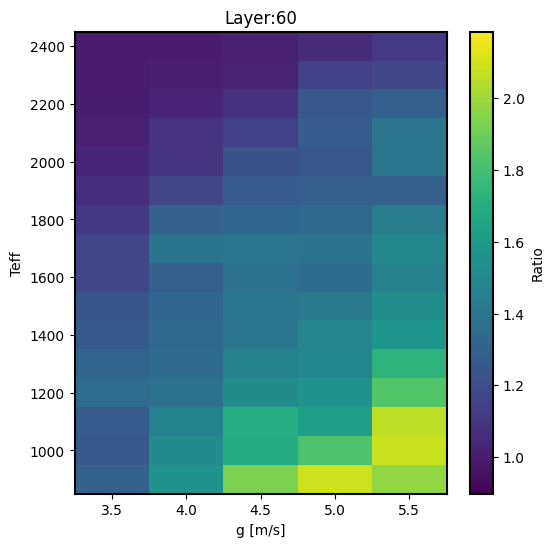

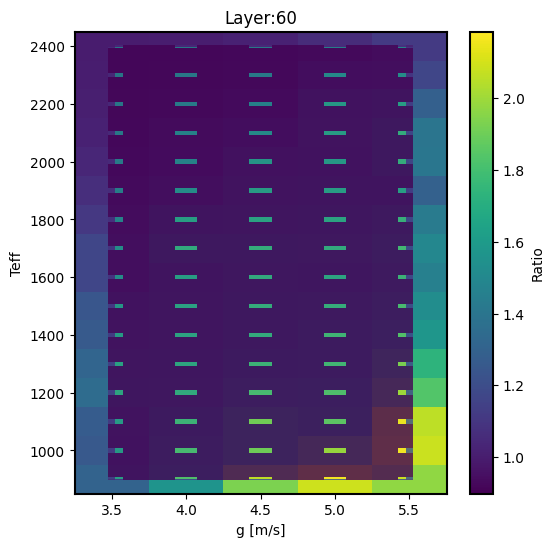

In [389]:
iin =60
iout = iin+1
#for p_ch in range(91):

for p_ch in range(91):#(iin,iout):
    fig, ax = plt.subplots( 1,1, figsize = (6,6))
    
   # kernel = Box2DKernel(3)
    bounds = np.linspace( 0, 240, 400)
    norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
    pcm = ax.pcolormesh( ggpl,tt , 
                        img,
                       vmin= np.min(img)-.1, vmax = np.max(img) +.1)#, 
    
   # pcm2 = ax.contour( gnew, tnew,np.flip(inxtrp,0))
#                 cmap = 'RdYlBu')
    plt.title('Layer:'+str( p_ch ) )
    plt.colorbar(pcm, label='Ratio')
    plt.xlabel('g [m/s]')
    dm = plt.ylabel('Teff')
    plt.show()
    
for p_ch in range(iin,iout):
    fig, ax = plt.subplots( 1,1, figsize = (6,6))
    
    kernel = Box2DKernel(3)
    
    reconstructed_image = convolve_fft(inxtrp, kernel)
   # reconstructed_image = Box2DKernel( inxtrp, kernel )
    bounds = np.linspace( 0, 240, 400)
    norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
    pcm = ax.pcolormesh( ggpl,tt , 
                        img,
                       vmin= np.min(img)-.1, vmax = np.max(img) +.1)#, 
    
    pcm2 =  ax.pcolormesh( gnew, tnew, reconstructed_image, alpha = .8 )
    #ax.pcolormesh( gnew,tnew , reconstructed_image, vmin= np.min(img)-.1, vmax = np.max(img)+.1)#, 
#                 cmap = 'RdYlBu')
    plt.title('Layer:'+str( p_ch ) )
    plt.colorbar(pcm, label='Ratio')
    plt.xlabel('g [m/s]')
    dm = plt.ylabel('Teff')
    plt.show()
    
    
     



In [376]:
#img.shape, tt.shape
#interp_func  = RegularGridInterpolator((tt, ggpl), img)
#reconstructed_image2 = interp_func((tnew[:, np.newaxis], gnew))

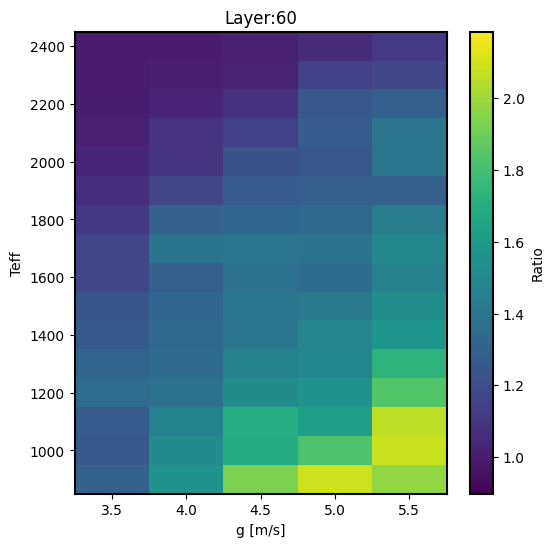

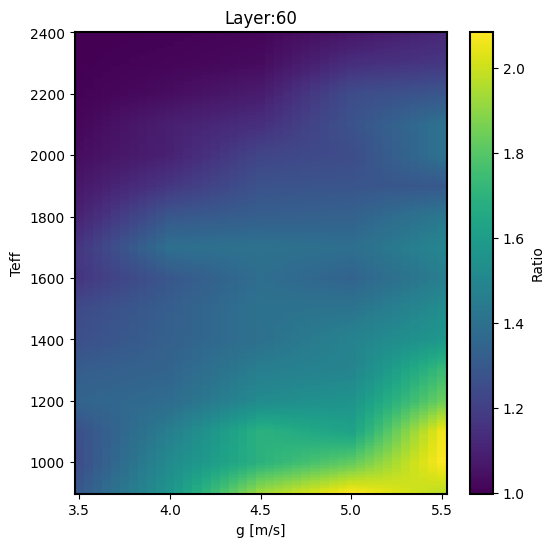

In [390]:
for p_ch in range(iin,iout):
    fig, ax = plt.subplots( 1,1, figsize = (6,6))
    
   # kernel = Box2DKernel(3)
    bounds = np.linspace( 0, 240, 400)
    norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
    pcm = ax.pcolormesh( ggpl,tt , 
                        img,
                       vmin= np.min(img)-.1, vmax = np.max(img) +.1)#, 
    
   # pcm2 = ax.contour( gnew, tnew,np.flip(inxtrp,0))
#                 cmap = 'RdYlBu')
    plt.title('Layer:'+str( p_ch ) )
    plt.colorbar(pcm, label='Ratio')
    plt.xlabel('g [m/s]')
    dm = plt.ylabel('Teff')
    plt.show()
    
for p_ch in range(iin,iout):
    fig, ax = plt.subplots( 1,1, figsize = (6,6))
    
   # kernel = Box2DKernel(13)
    #x_new, y_new = np.meshgrid(gnew, y_new)

    # Interpolation
    interp_func  = RegularGridInterpolator((tt, ggpl), img)
    reconstructed_image2 = interp_func((tnew[:, np.newaxis], gnew))
    #griddata((ggpl.ravel(), tt.ravel()), img.ravel(), (x_new, y_new), method='cubic')

   # reconstructed_image = convolve_fft(inxtrp, kernel)
   # reconstructed_image = Box2DKernel( inxtrp, kernel )
    bounds = np.linspace( 0, 240, 400)
    norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
   # pcm = ax.pcolormesh( ggpl,tt , 
   #                     img,
   #                    vmin= np.min(img)-.1, vmax = np.max(img) +.1)#, 
    
    pcm2 = ax.pcolormesh( gnew,tnew , reconstructed_image2)#, 
#                 cmap = 'RdYlBu')
    plt.title('Layer:'+str( p_ch ) )
    plt.colorbar(pcm2, label='Ratio')
    plt.xlabel('g [m/s]')
    dm = plt.ylabel('Teff')
    plt.show()
       
    


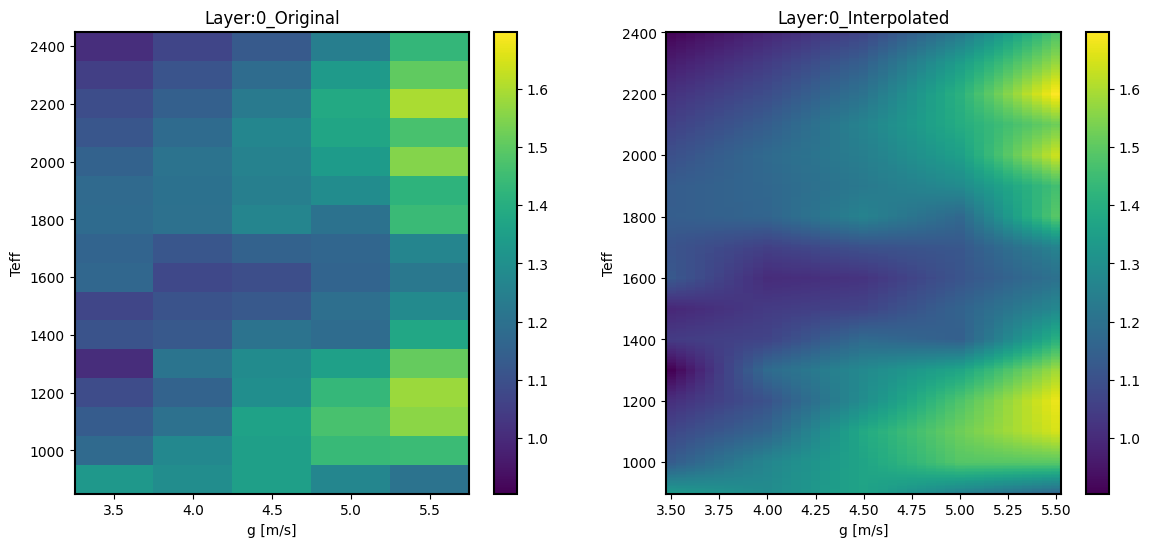

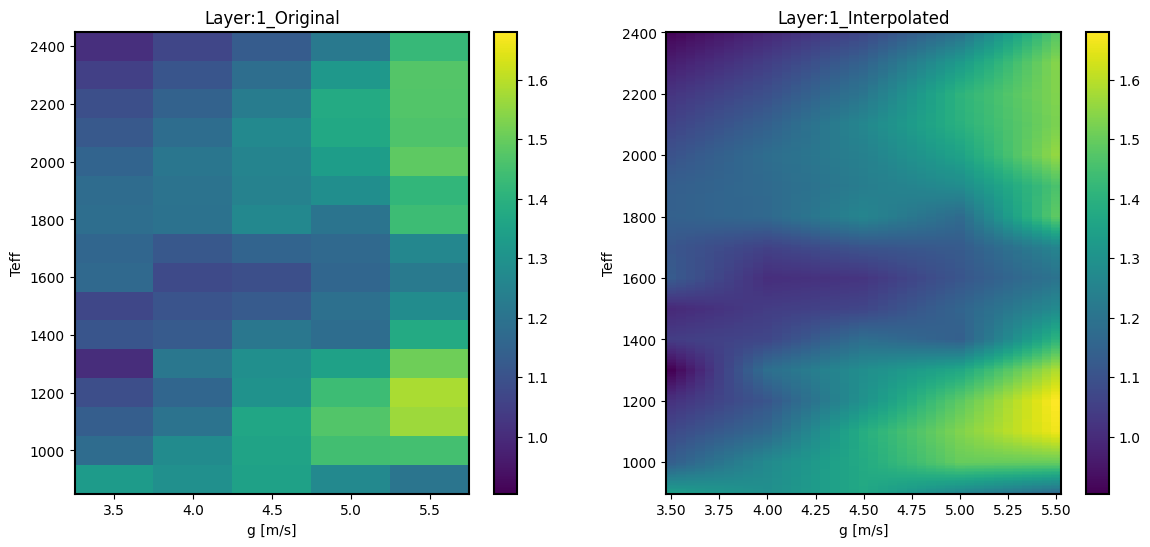

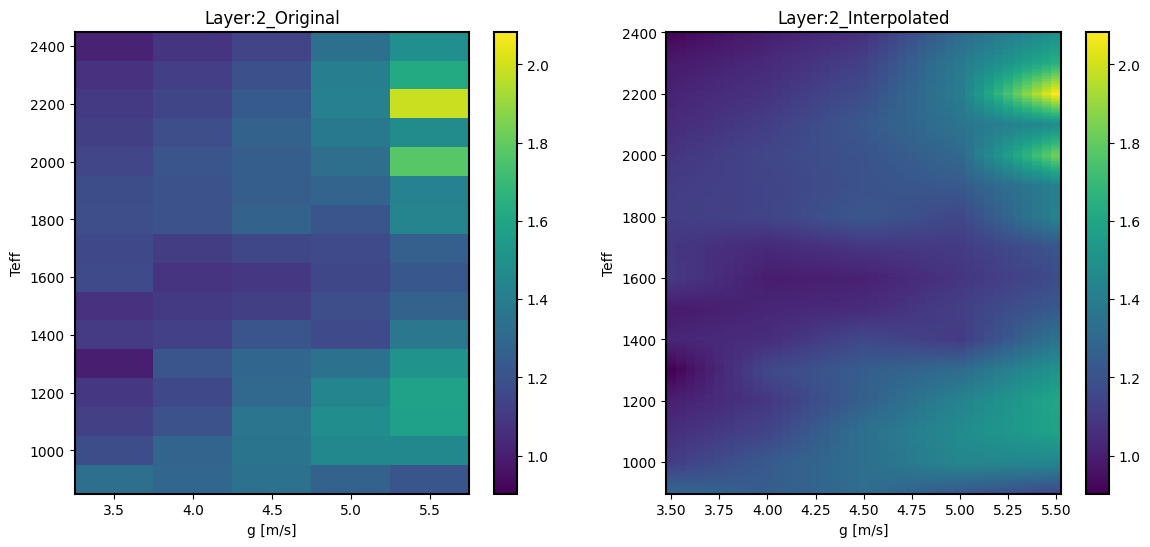

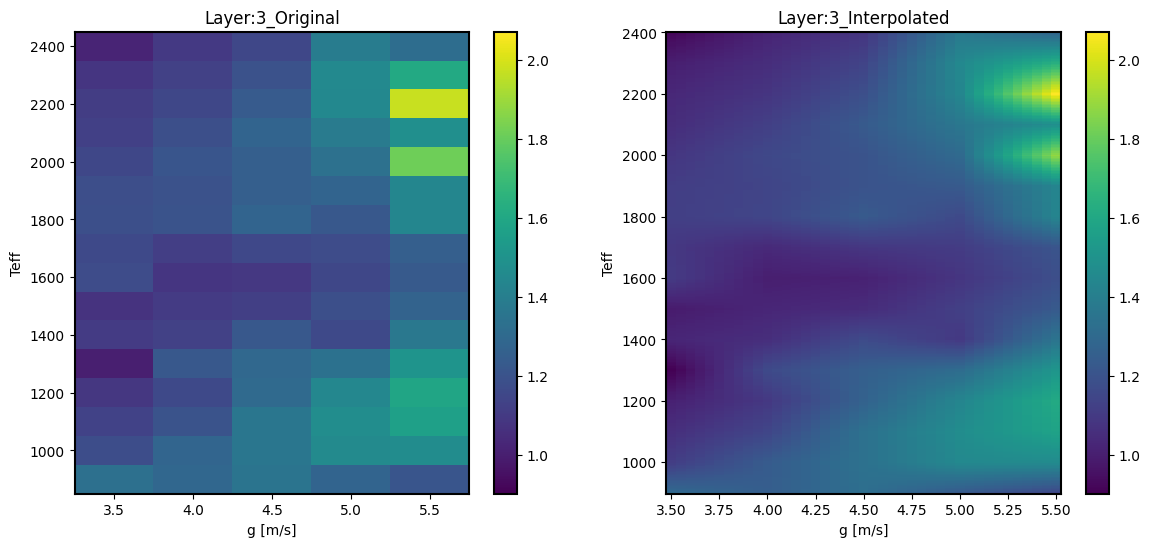

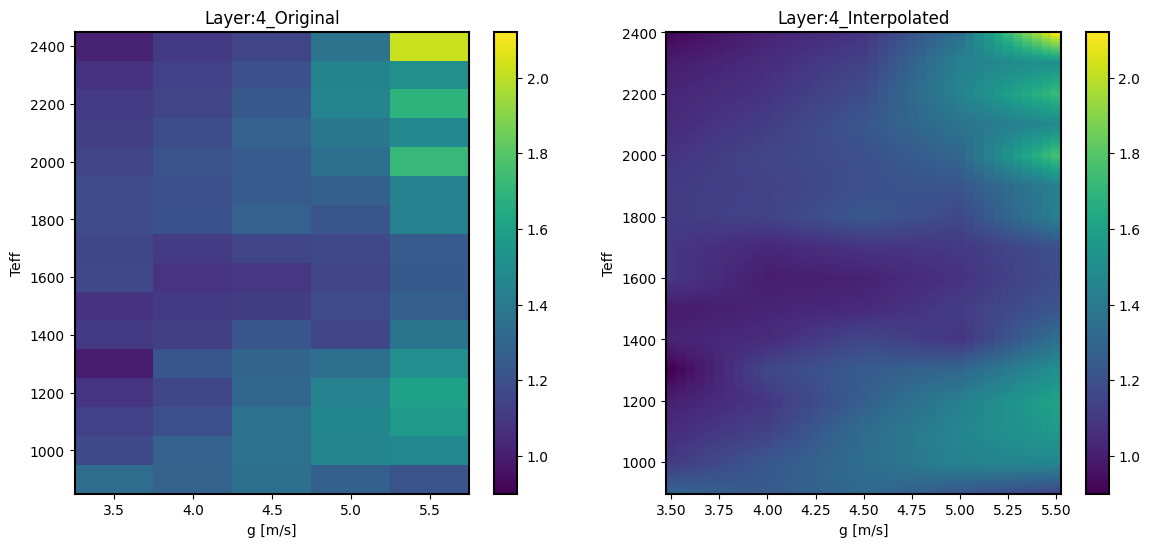

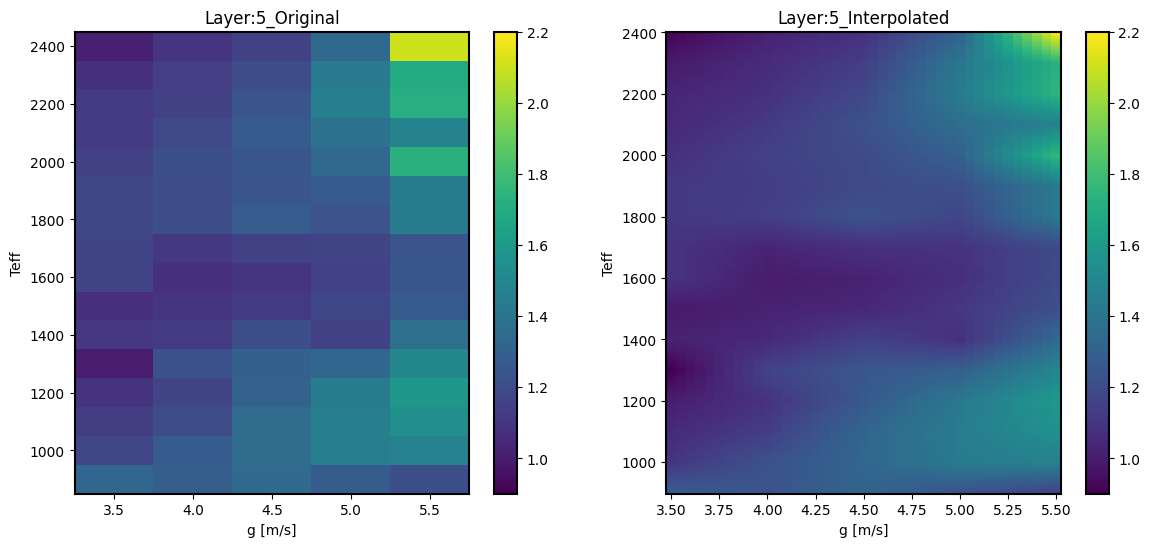

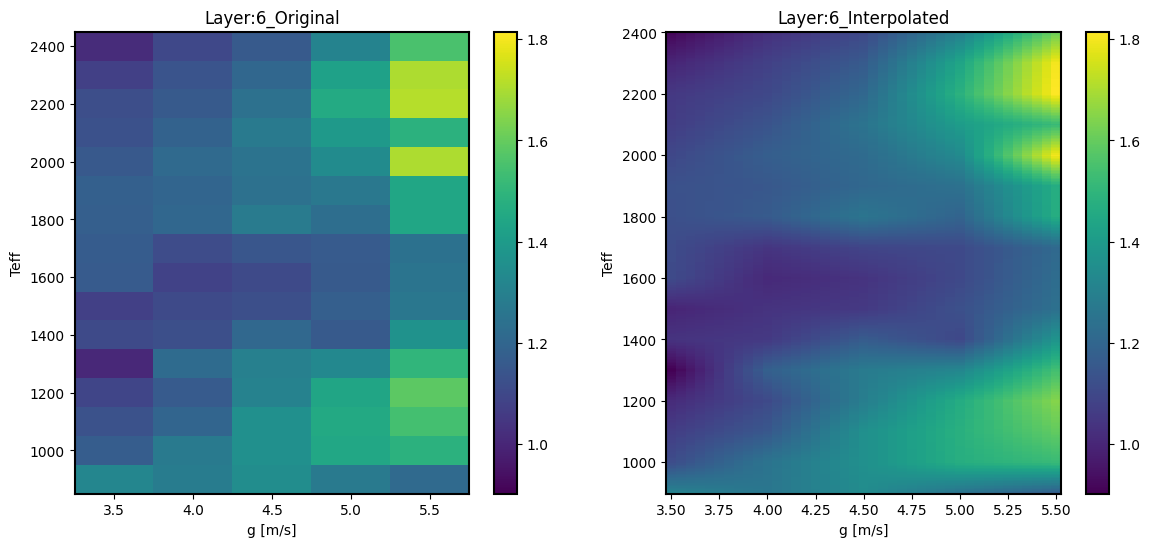

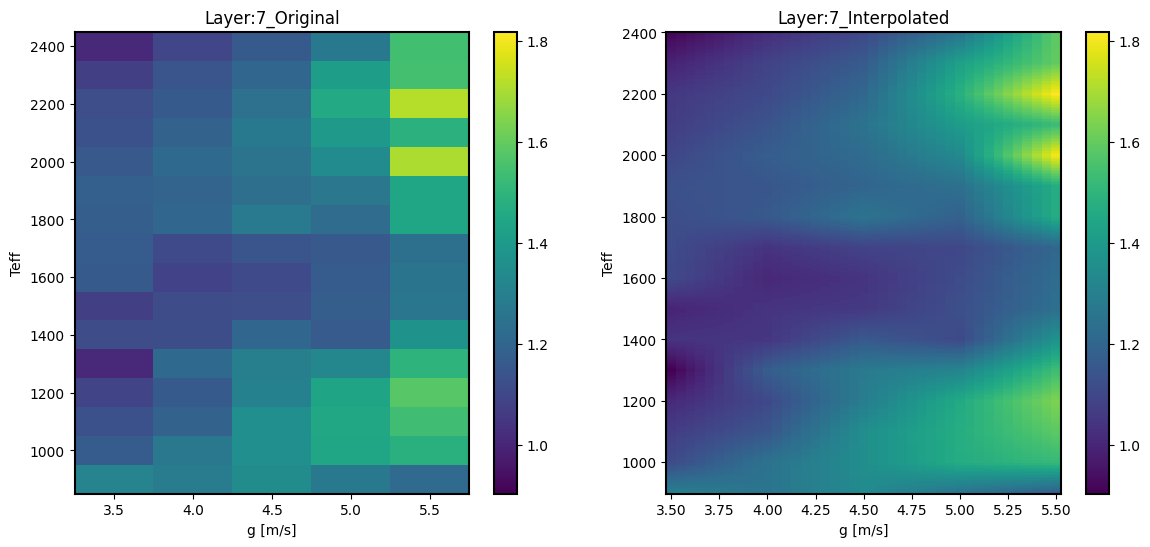

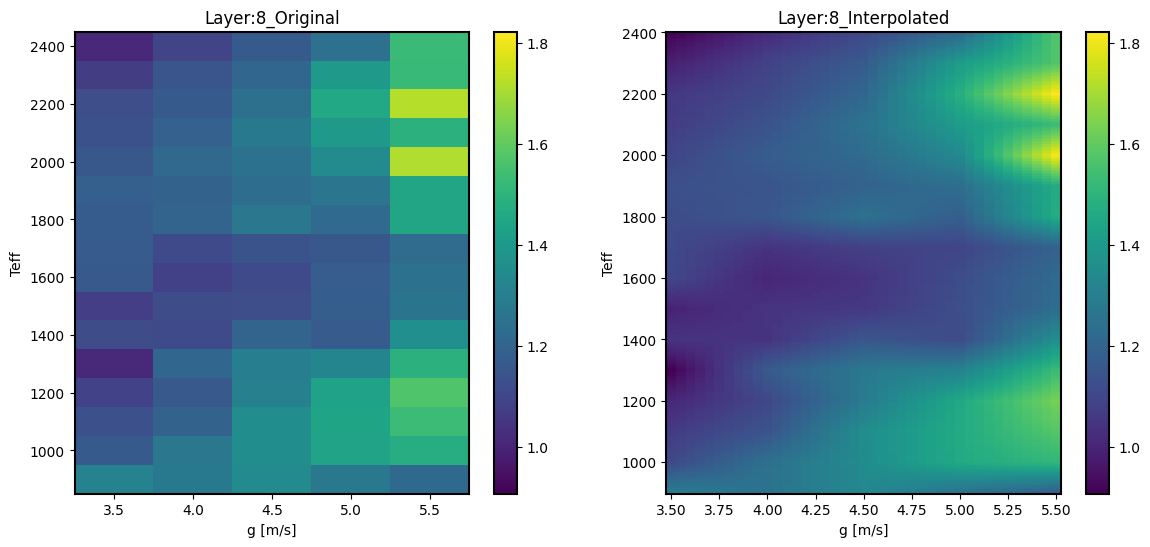

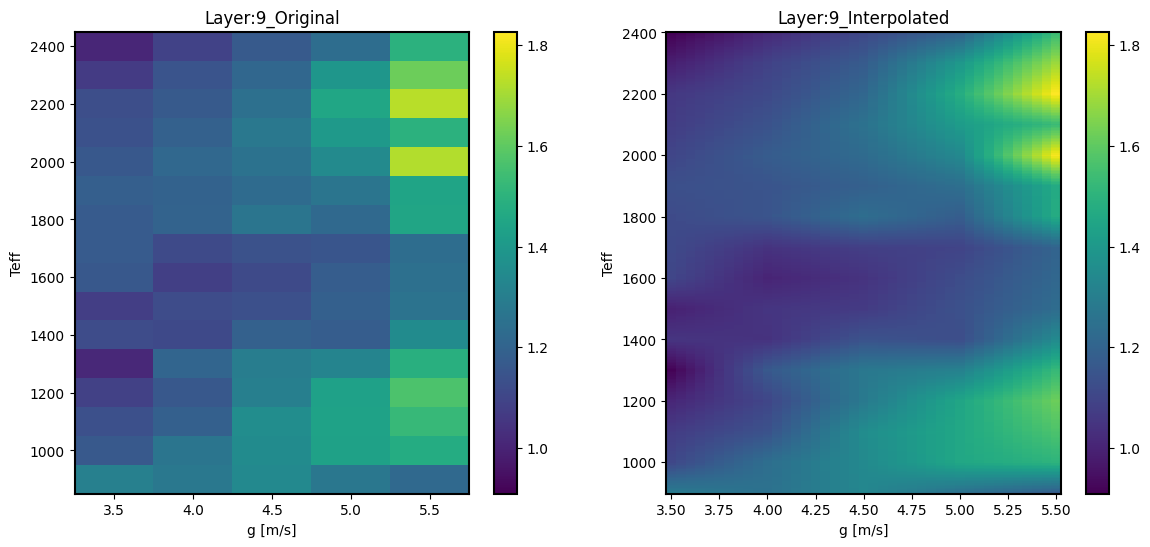

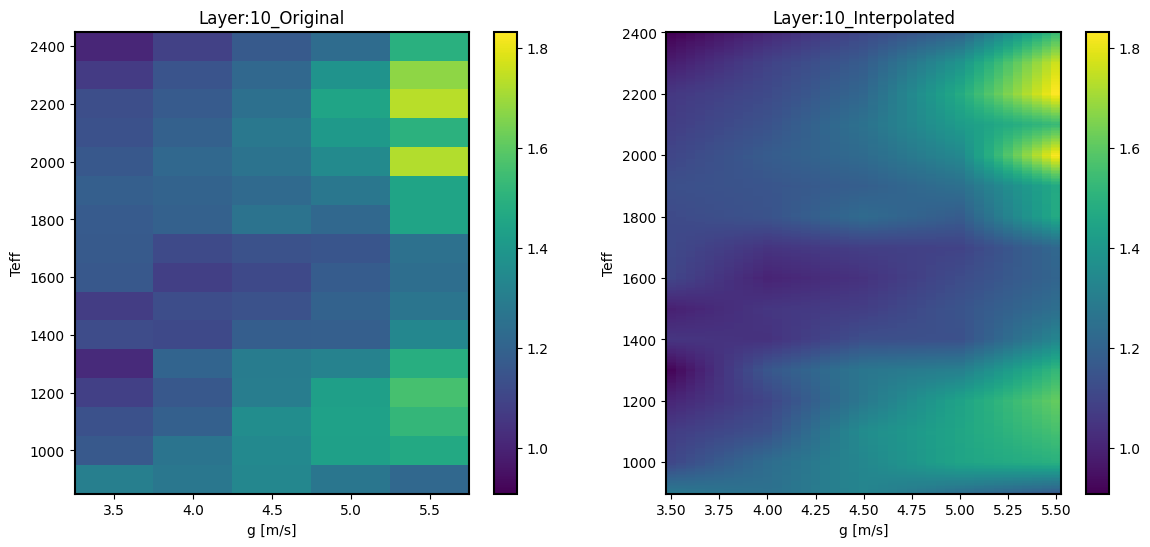

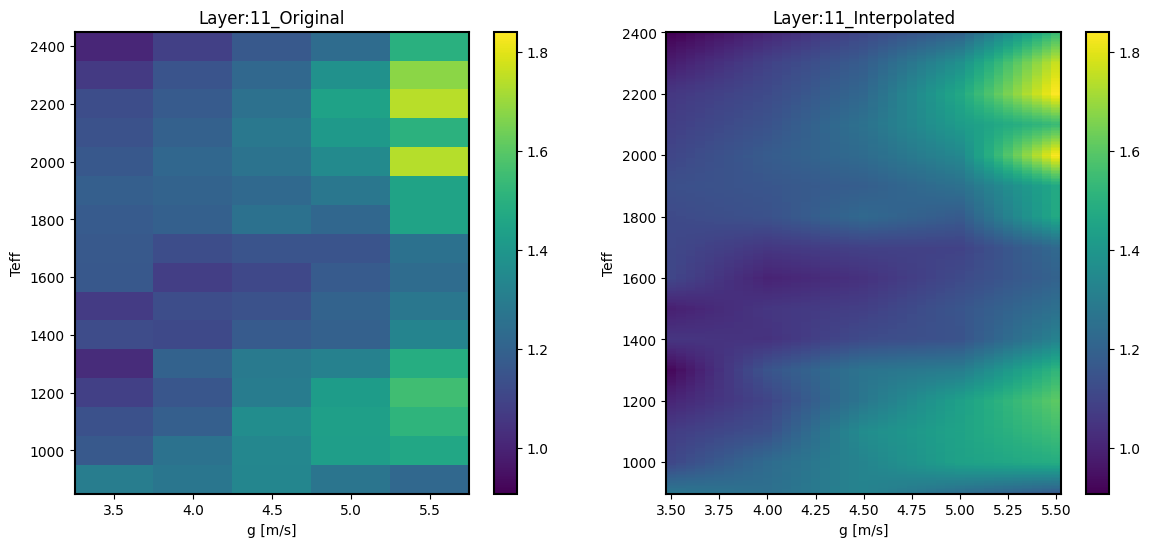

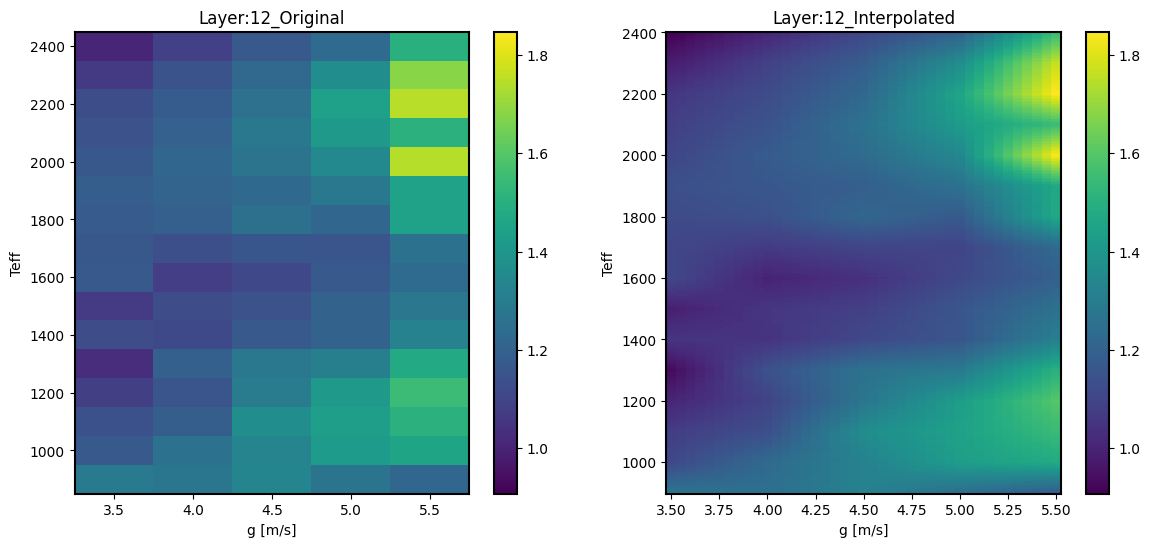

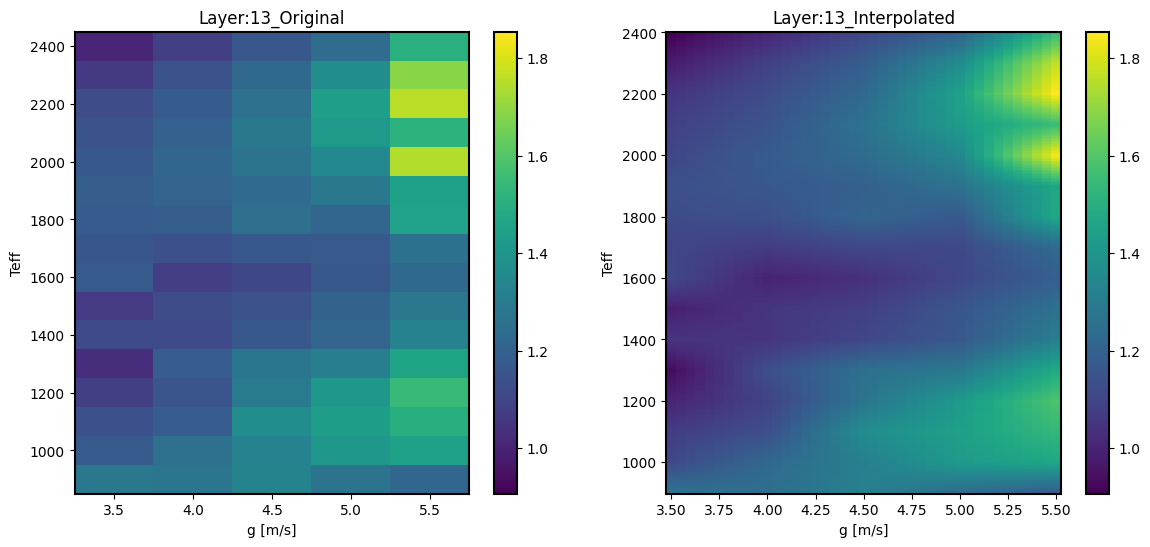

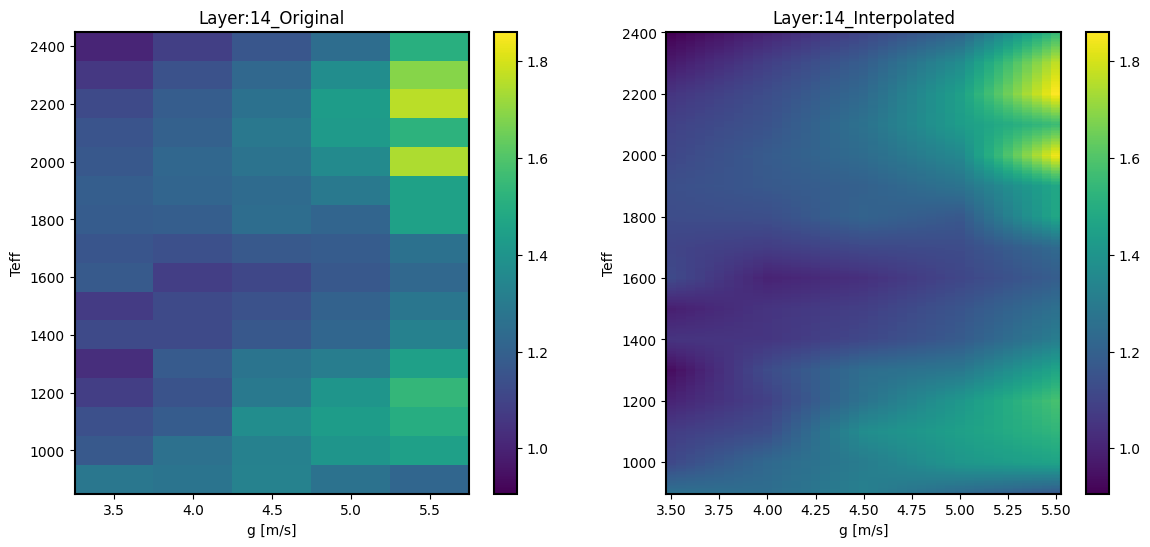

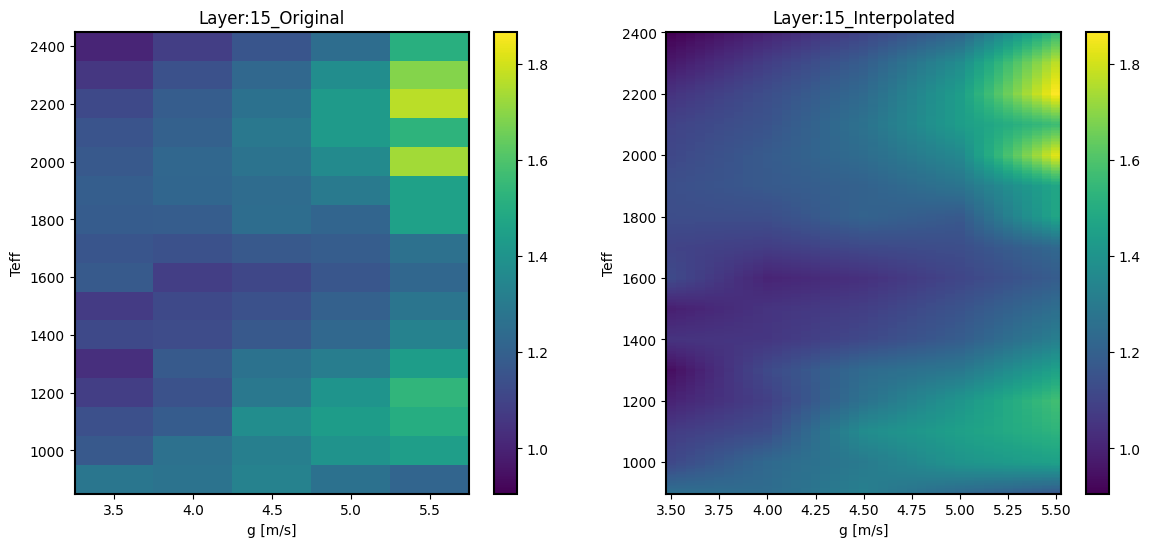

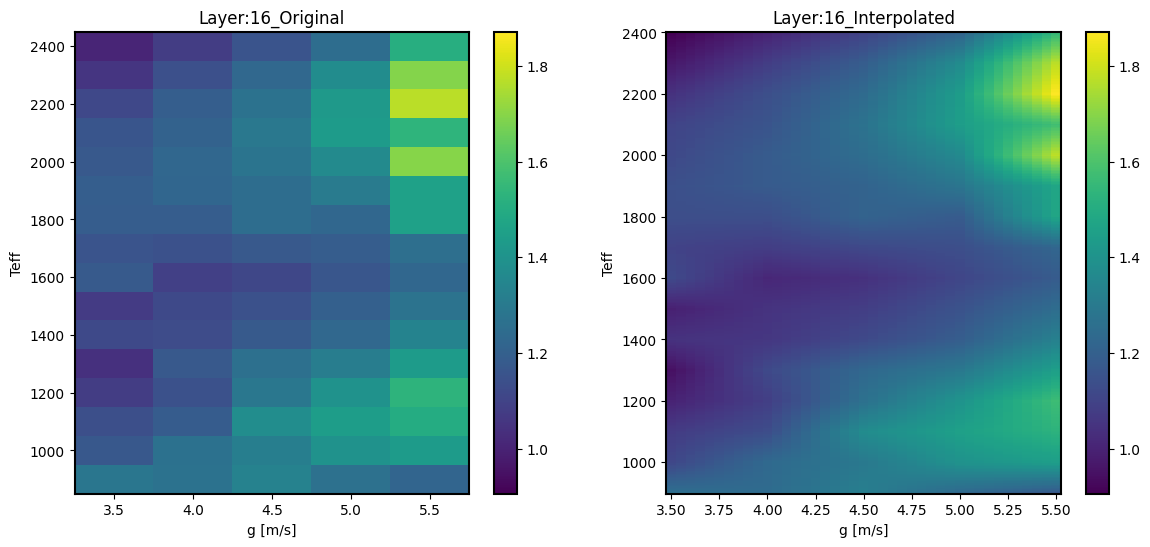

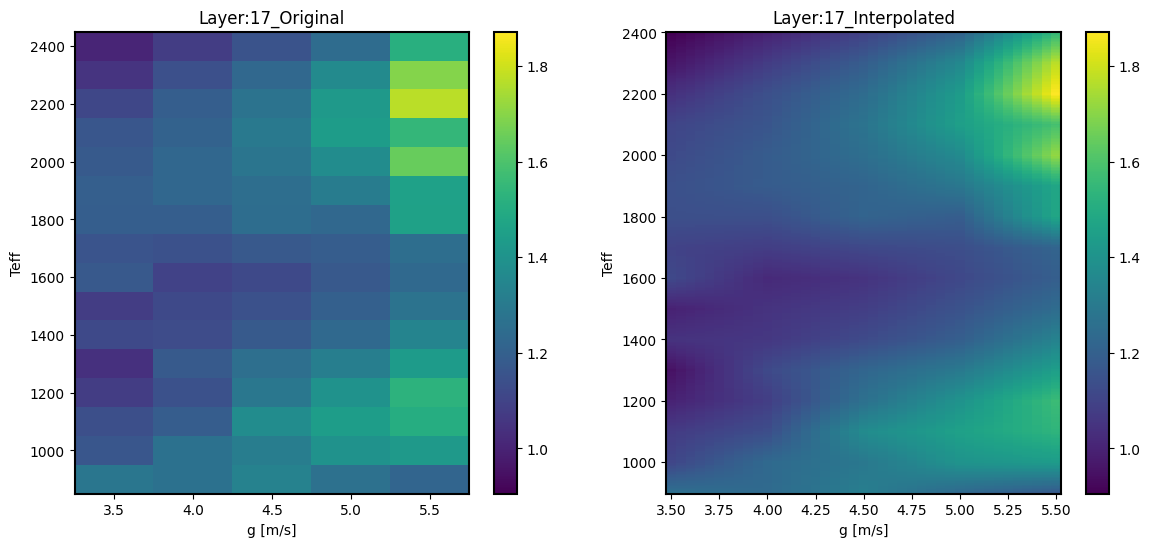

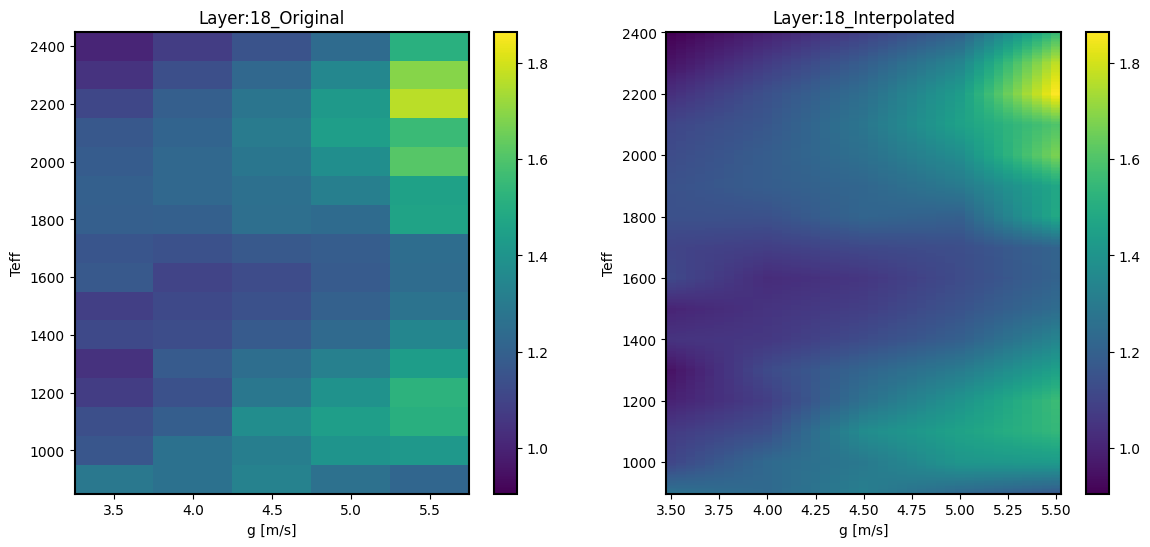

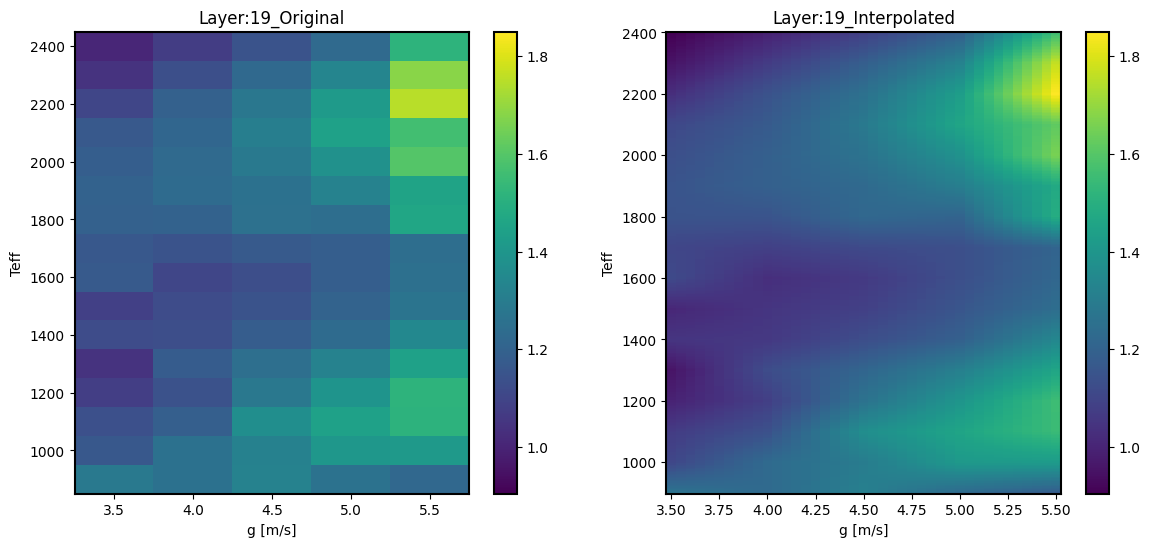

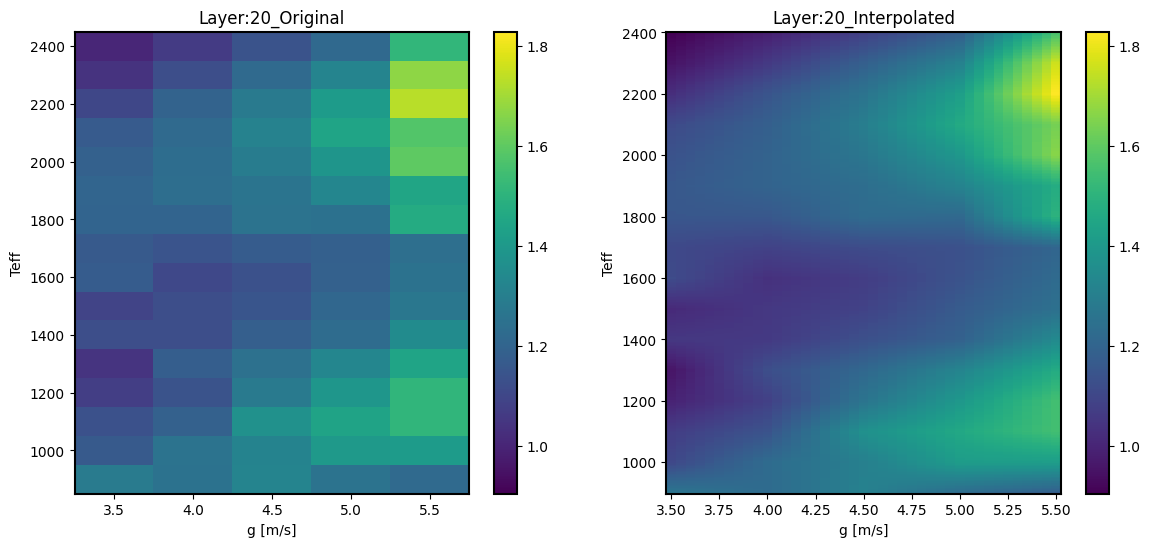

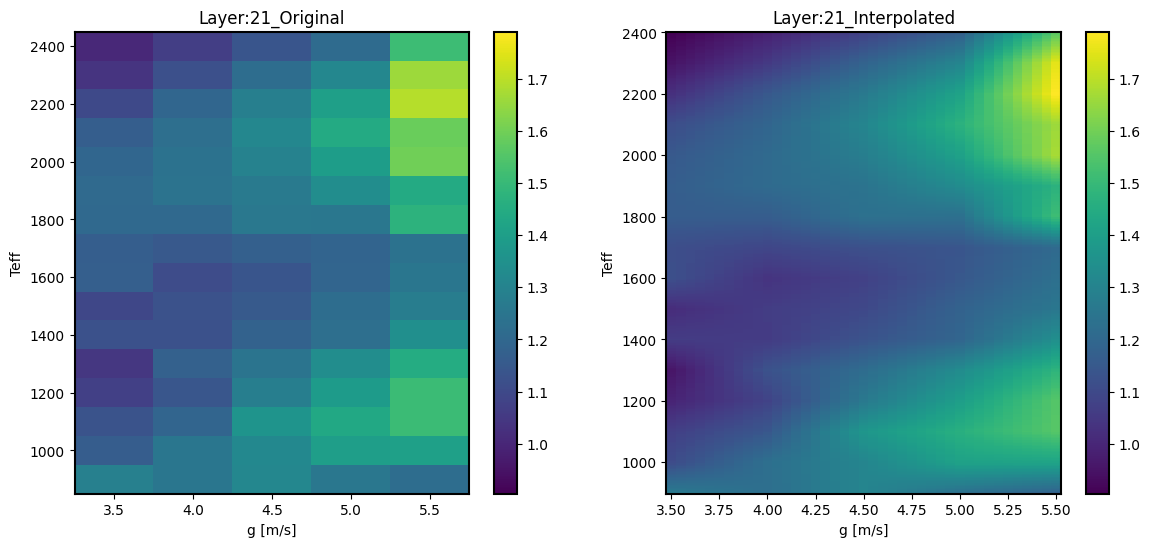

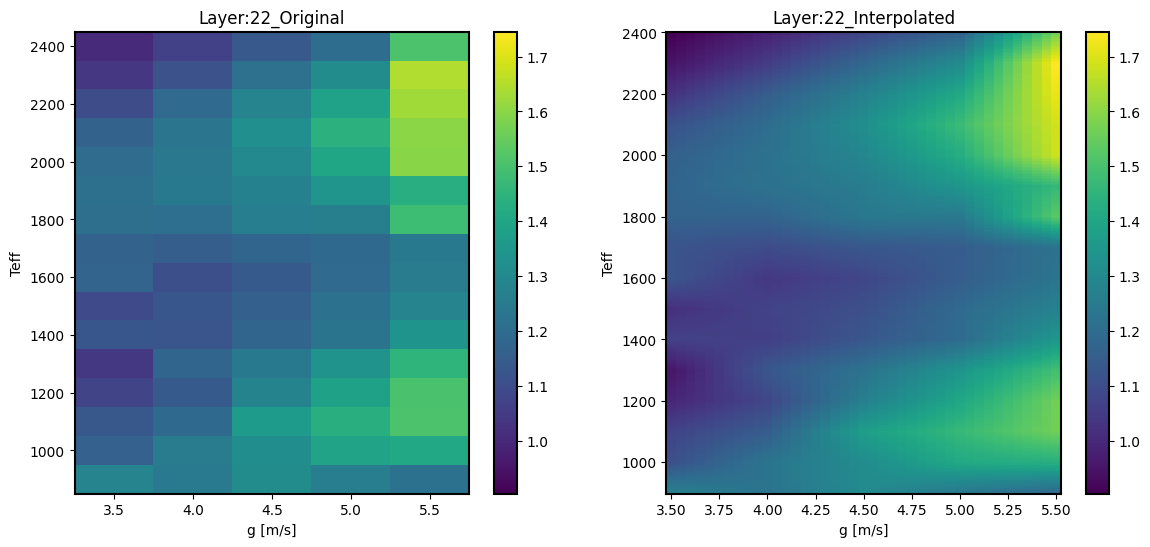

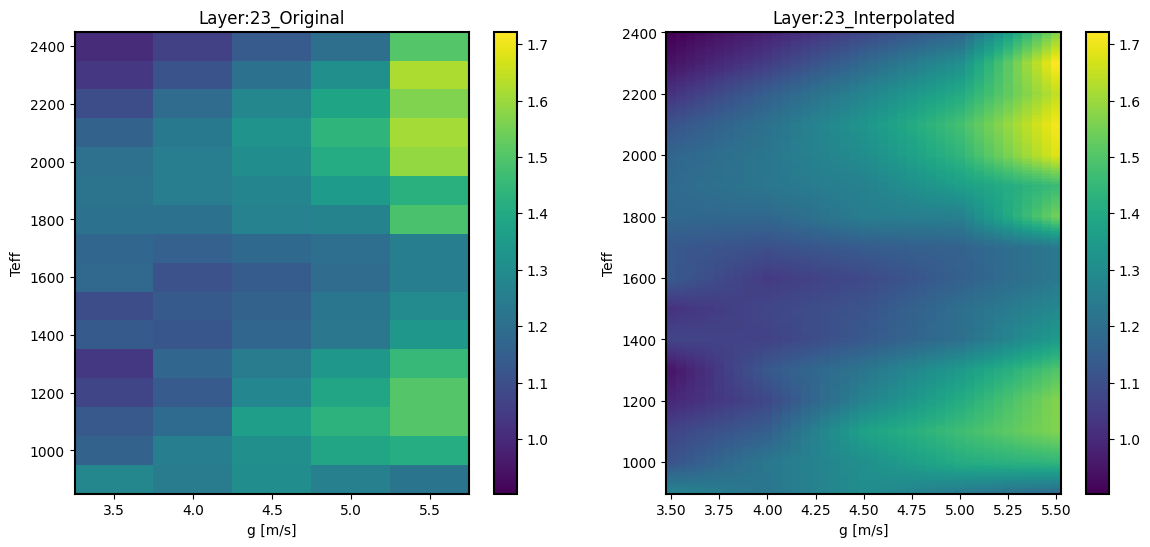

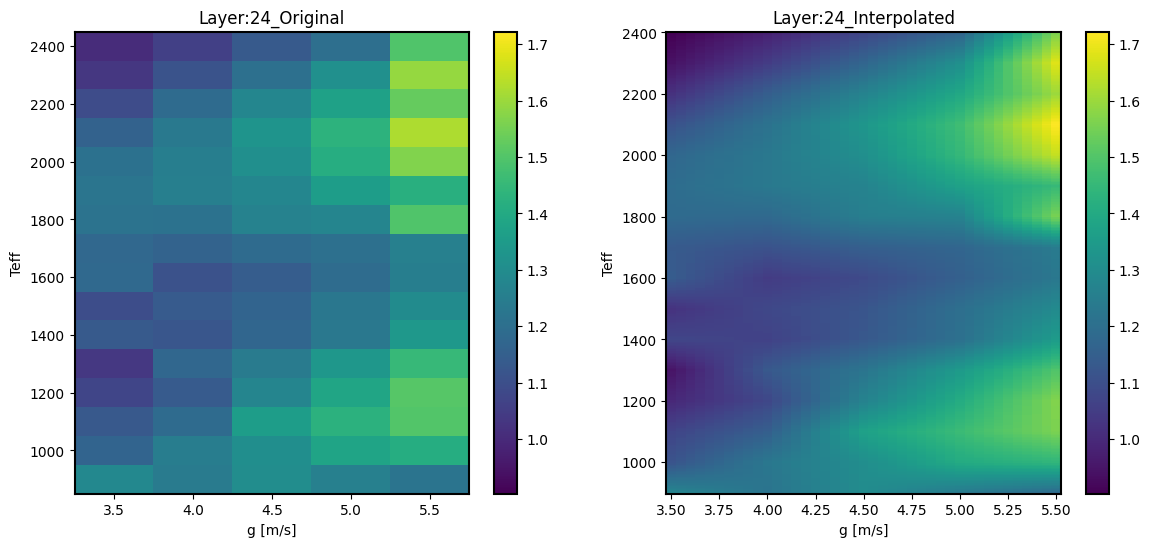

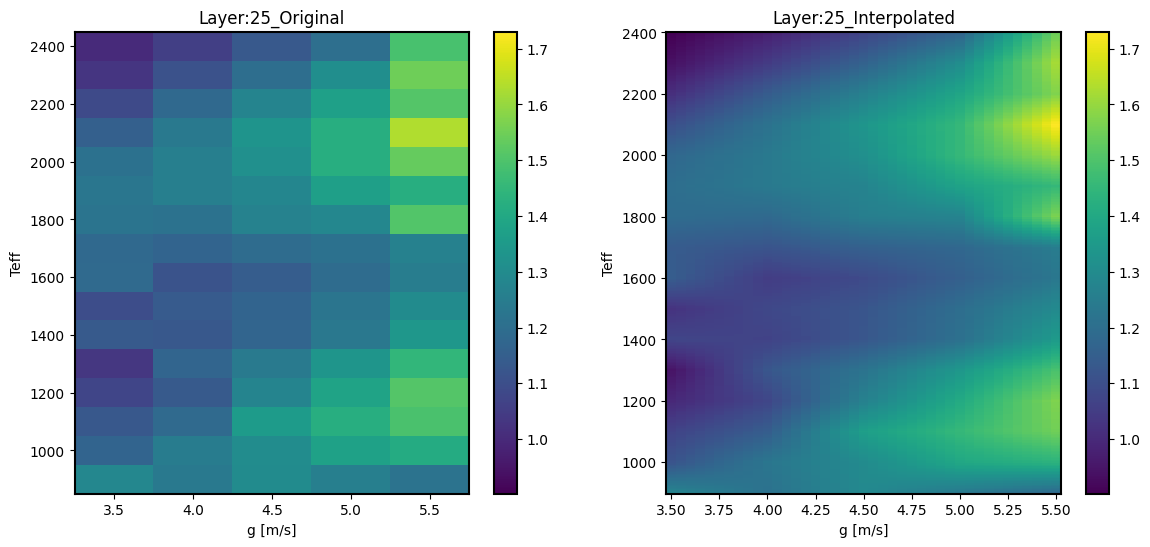

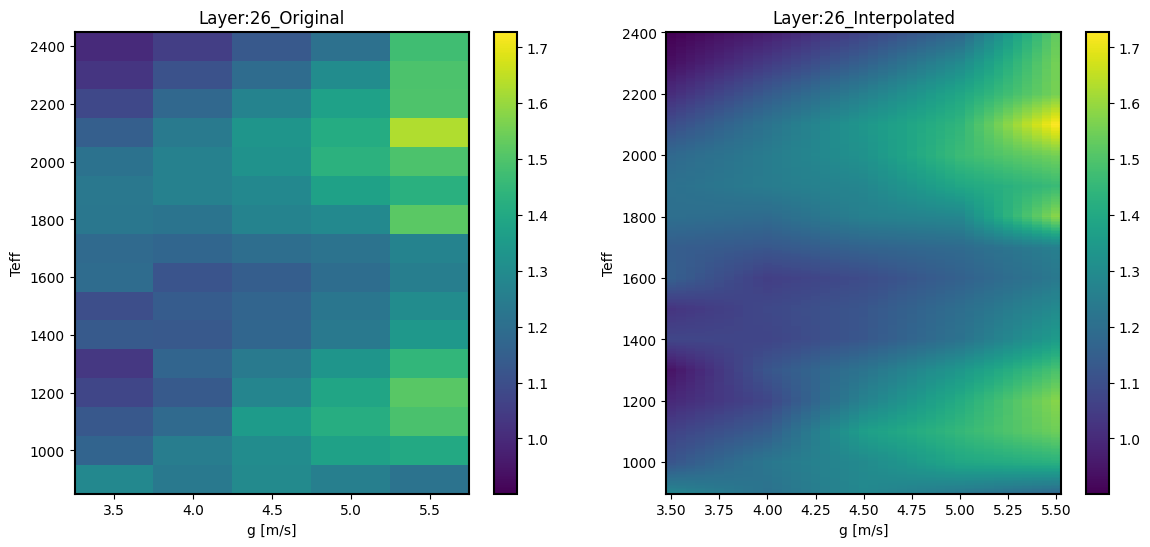

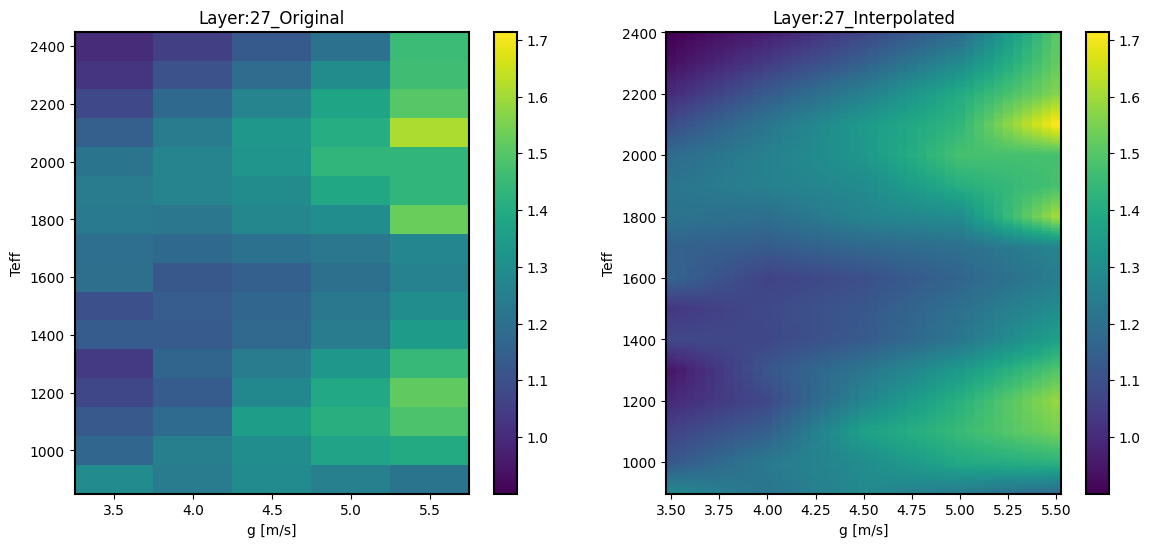

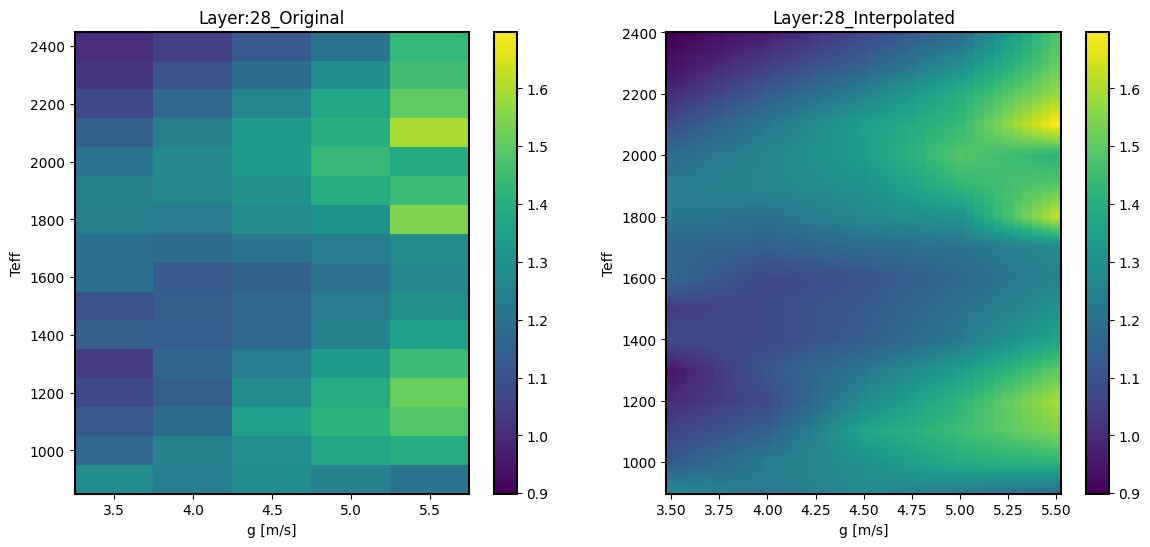

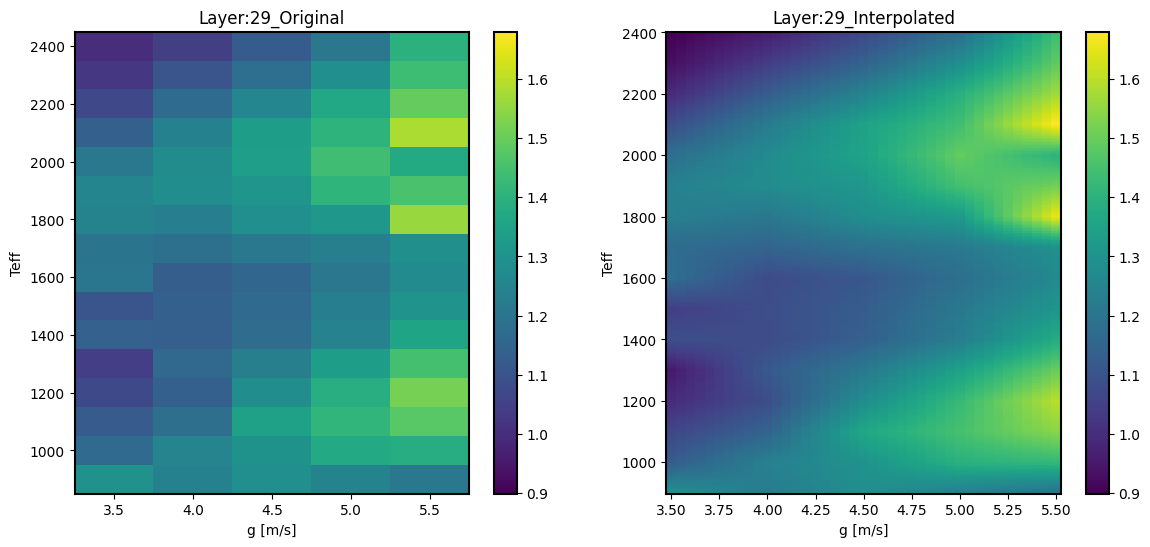

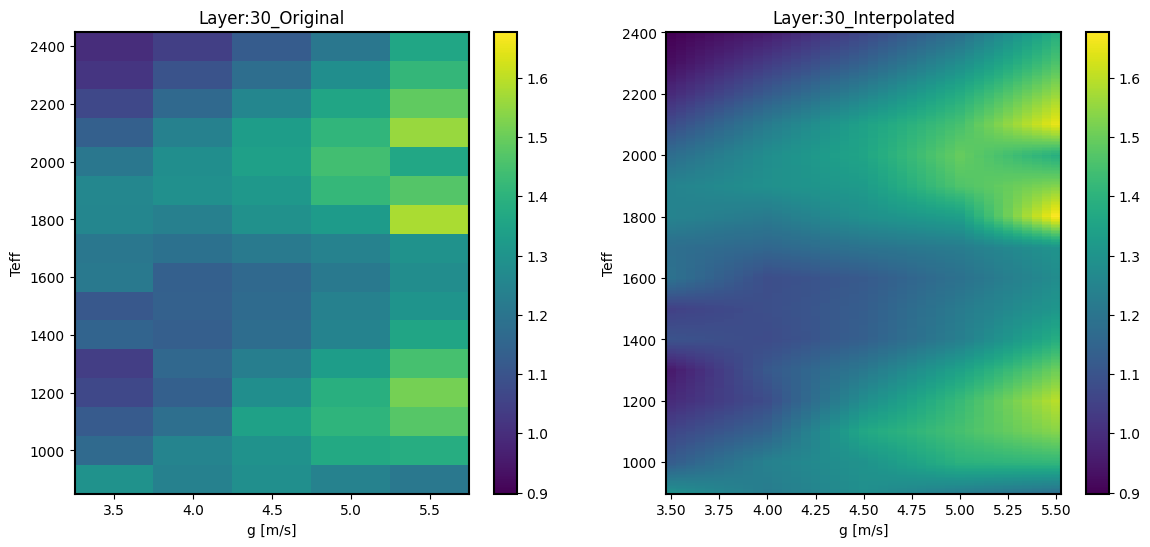

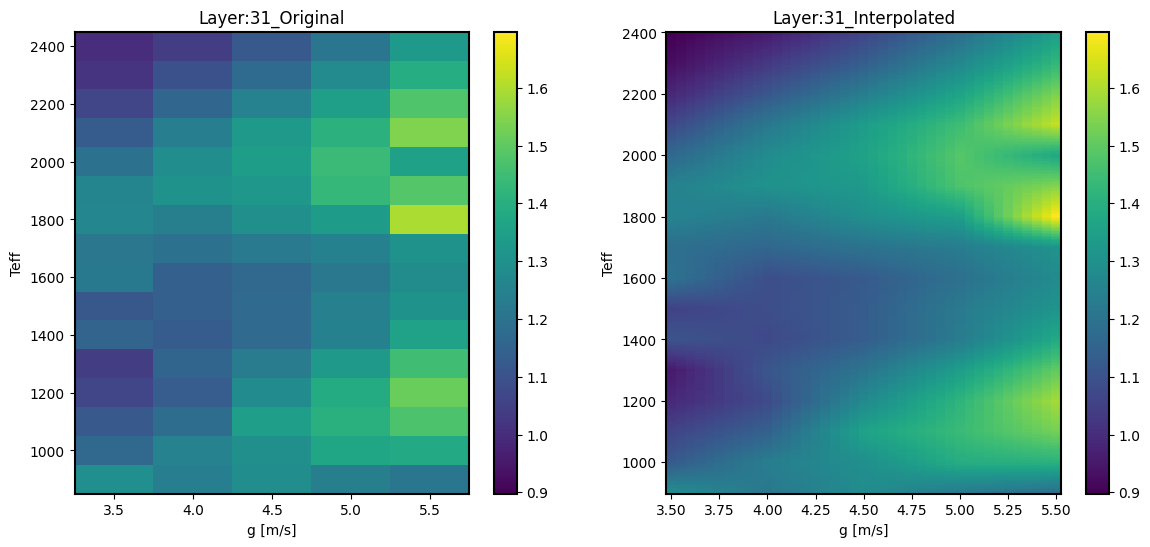

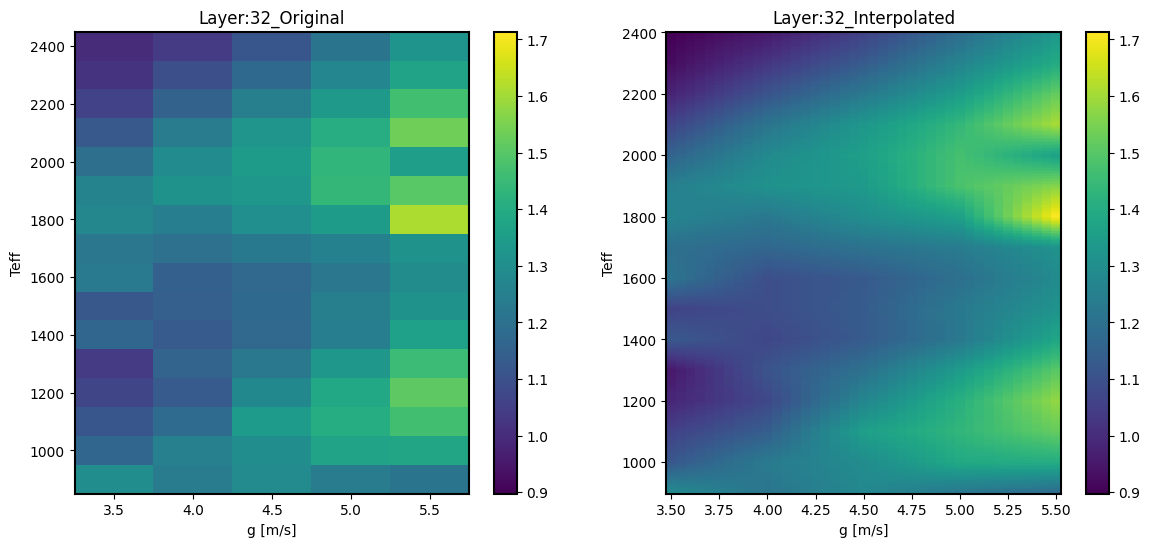

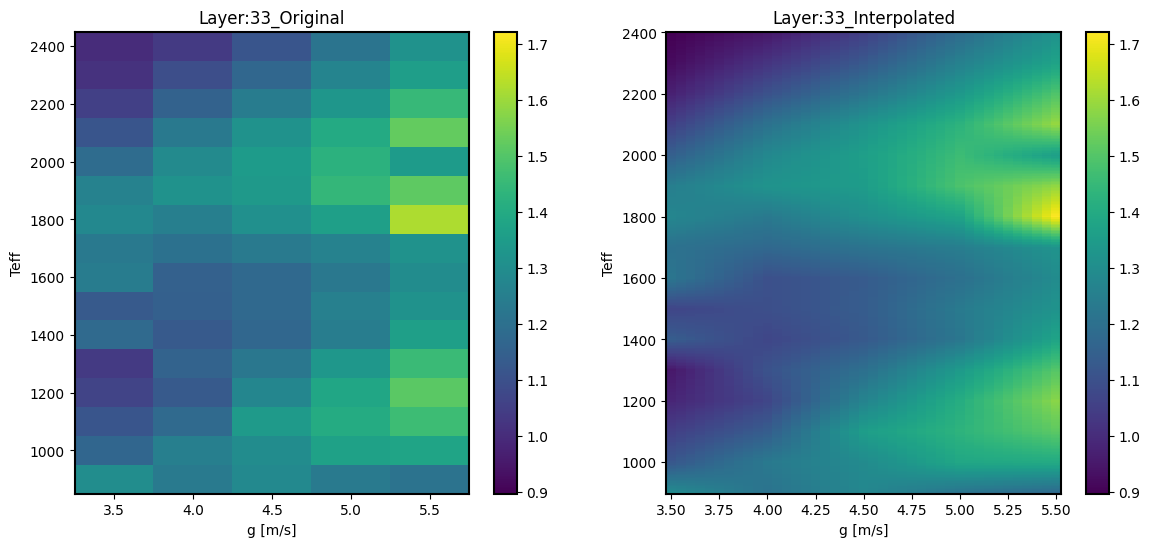

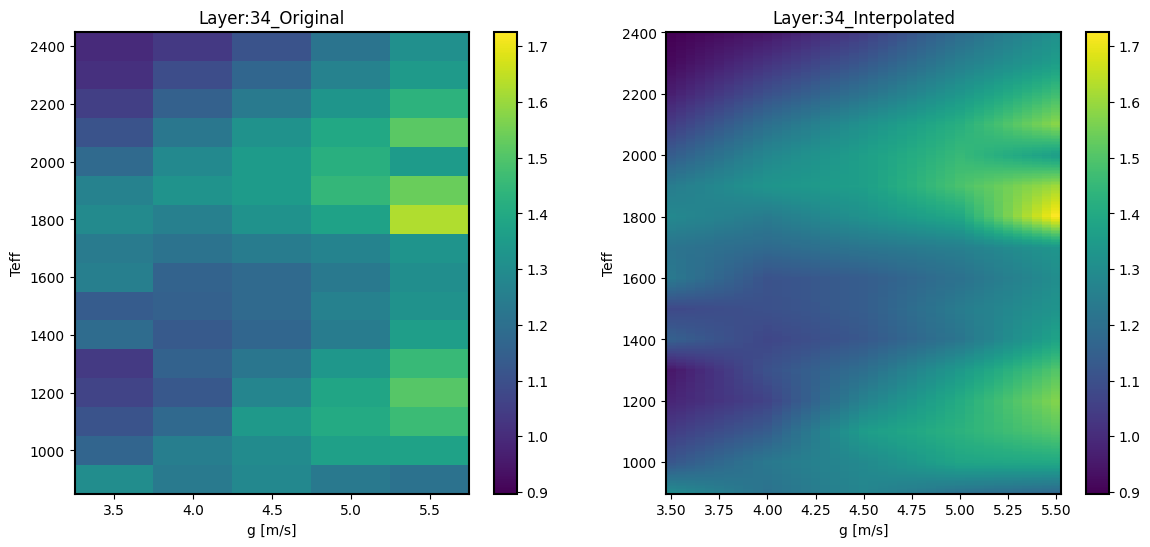

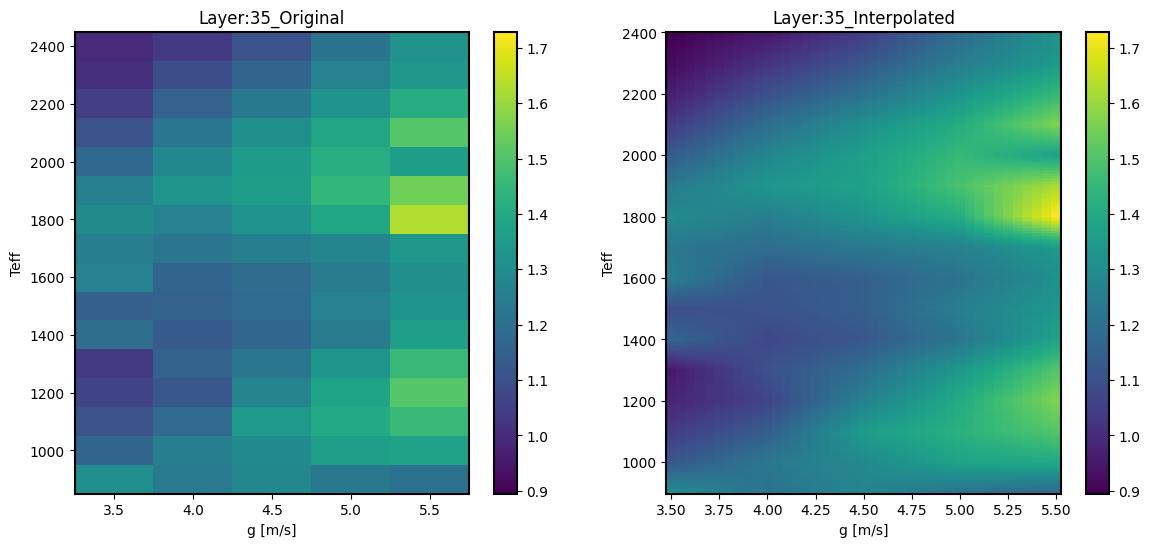

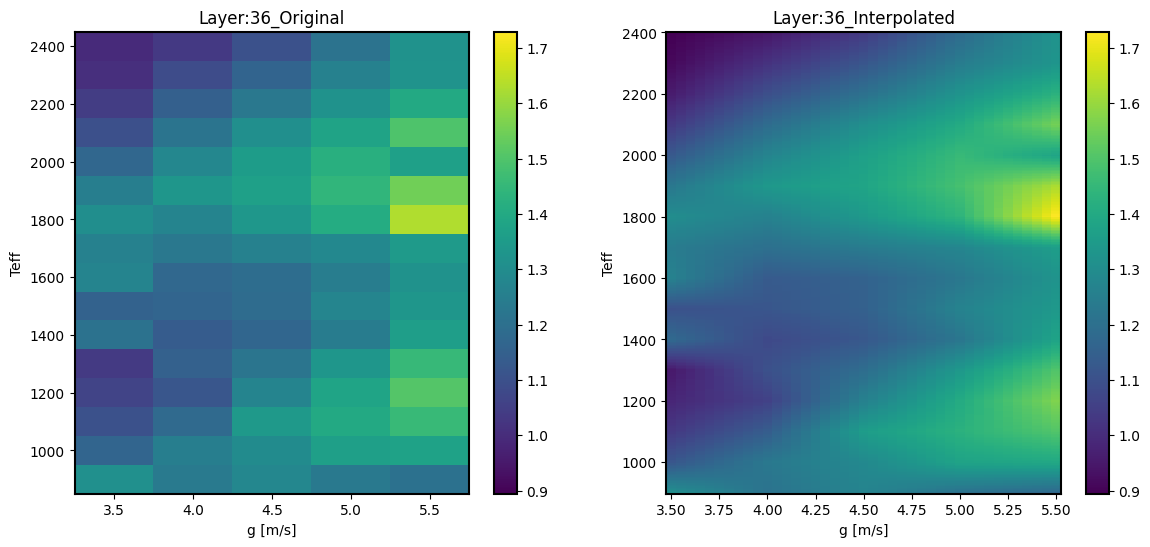

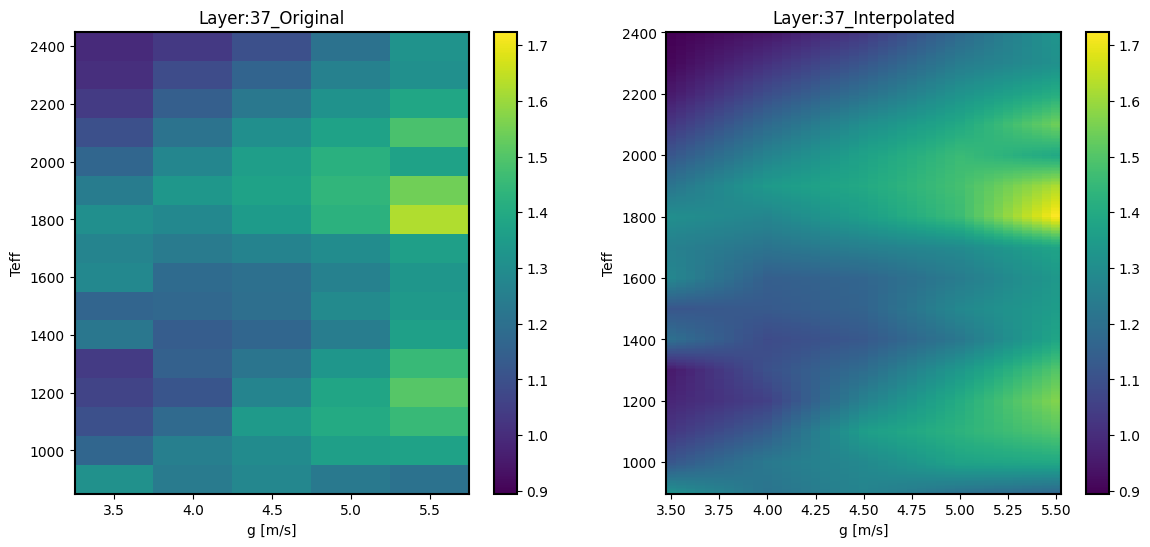

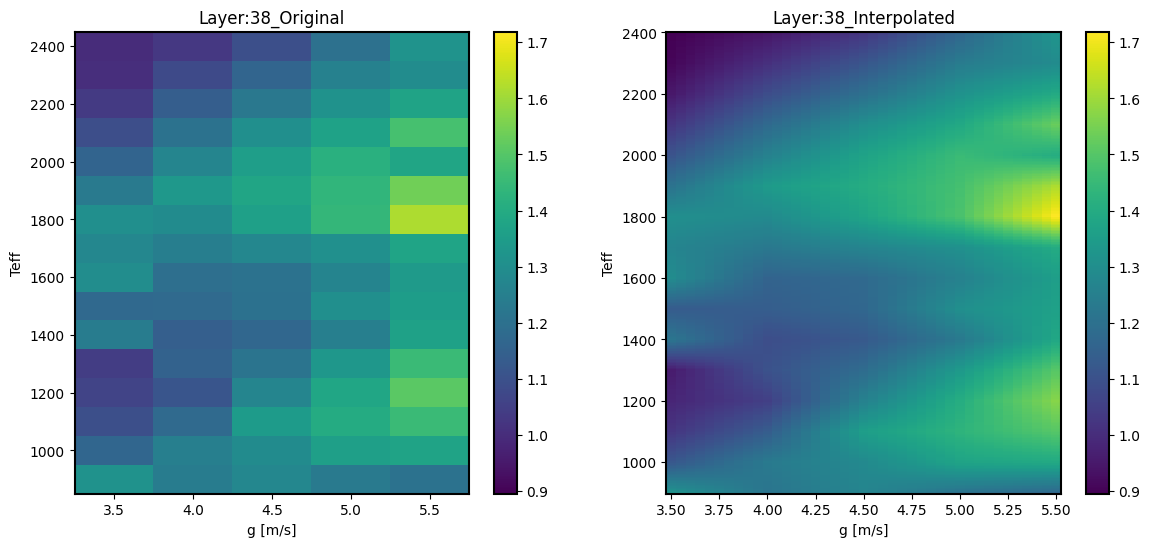

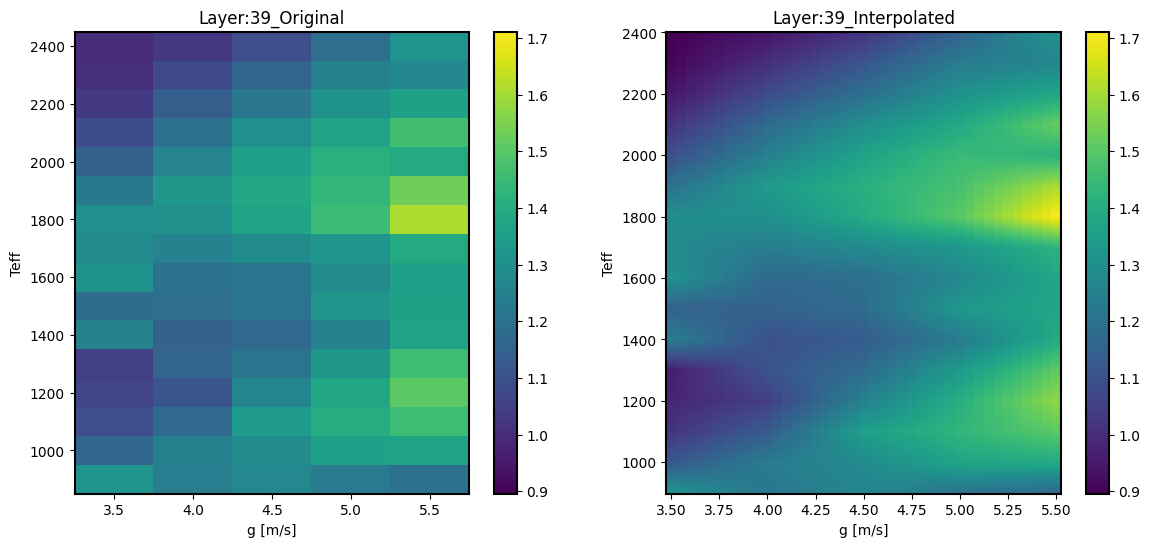

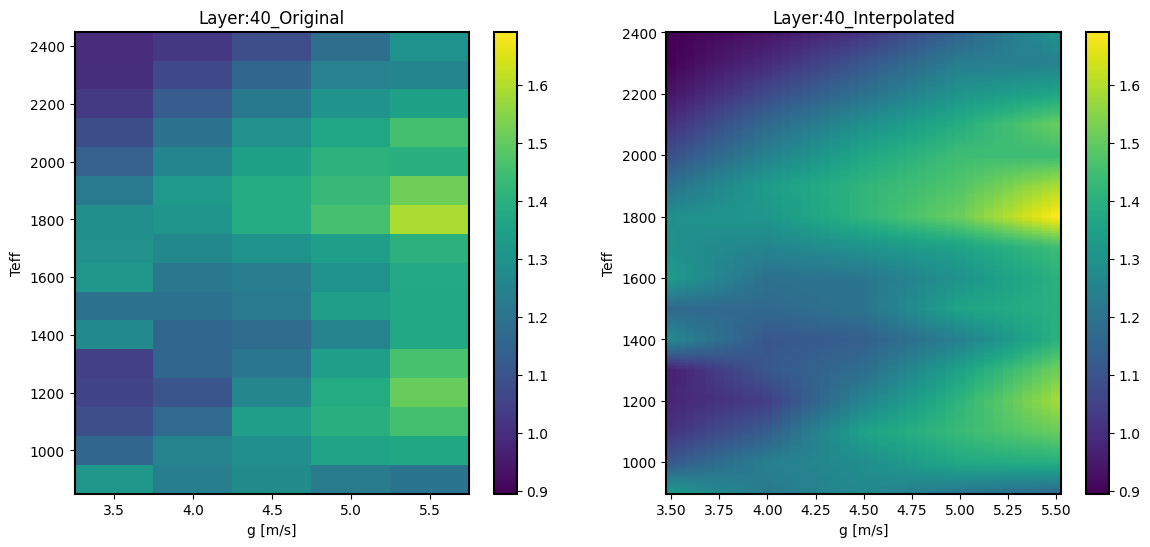

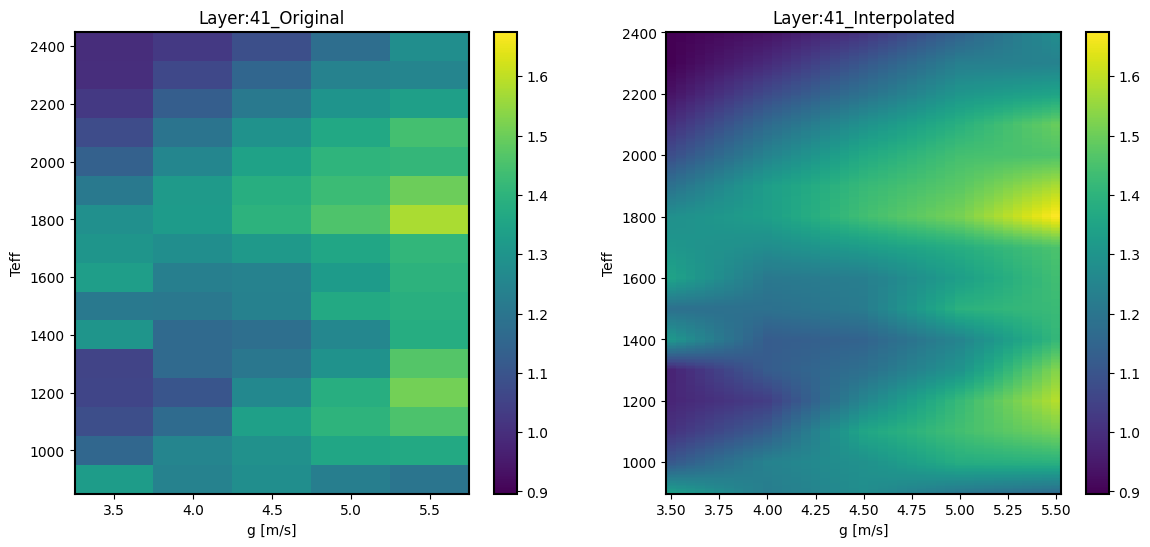

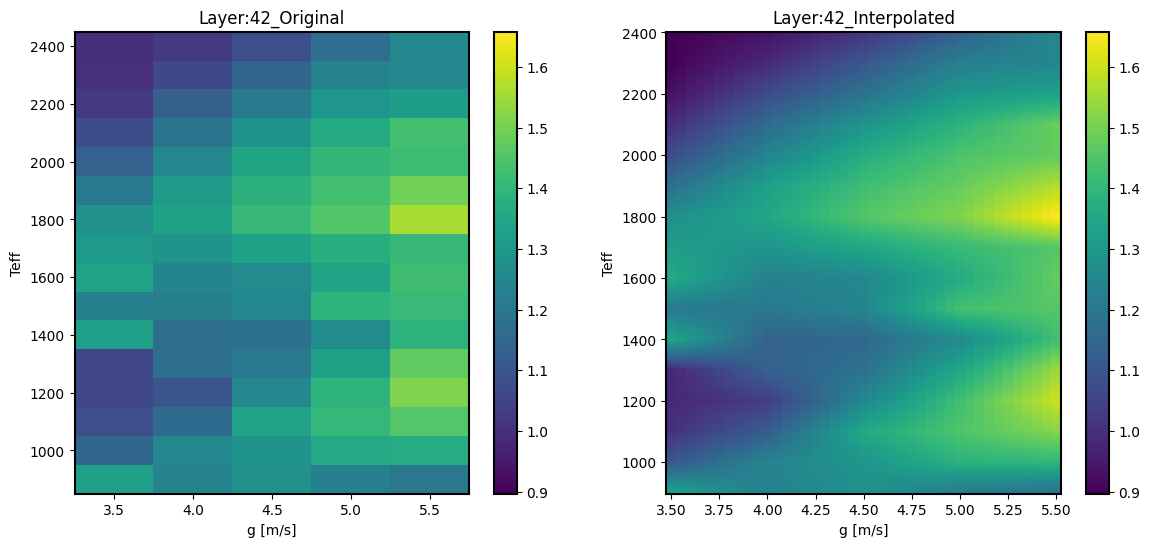

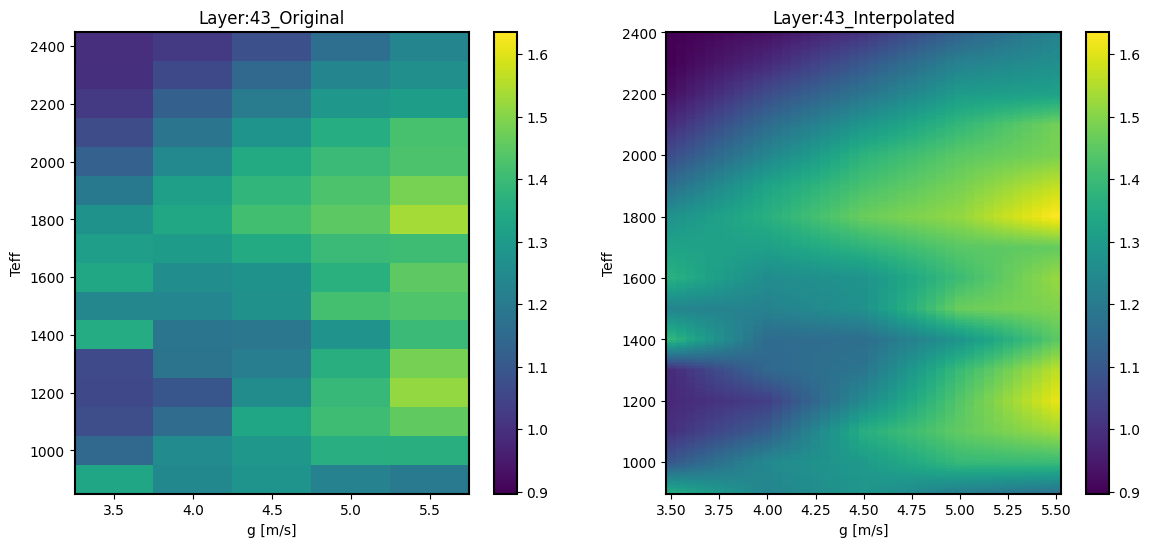

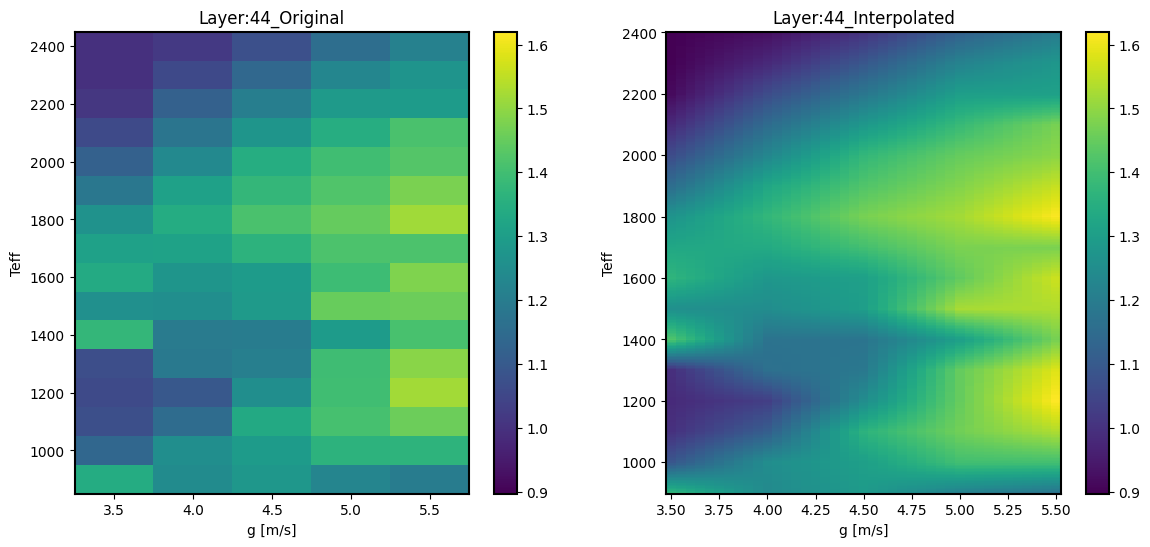

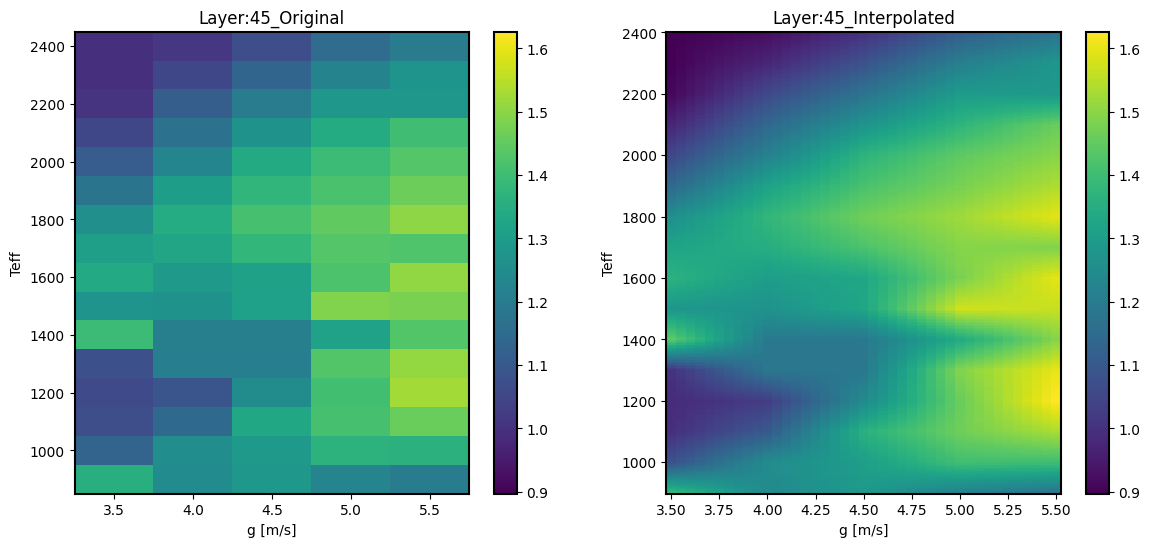

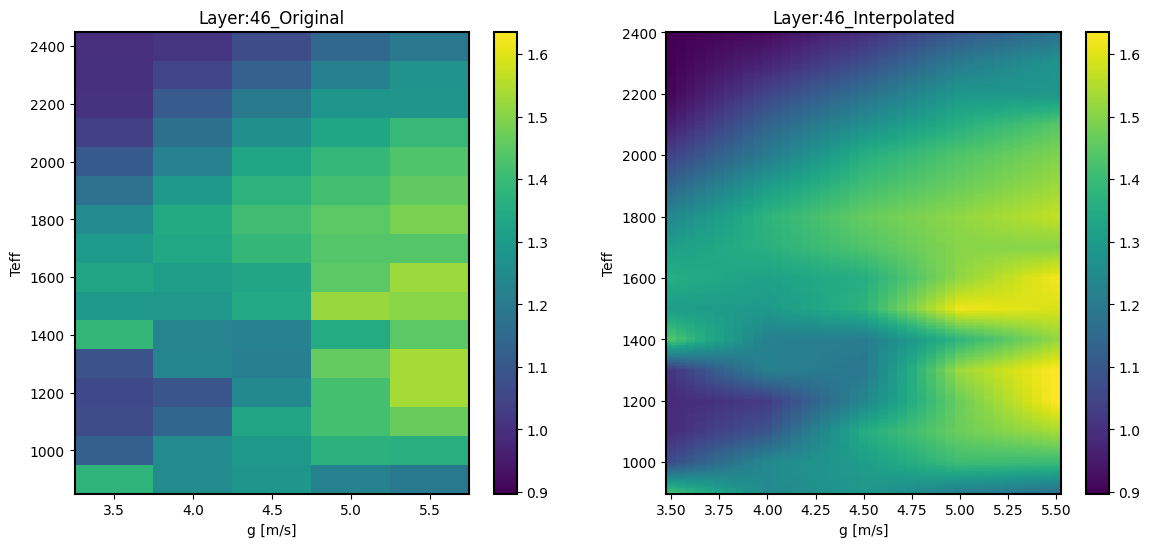

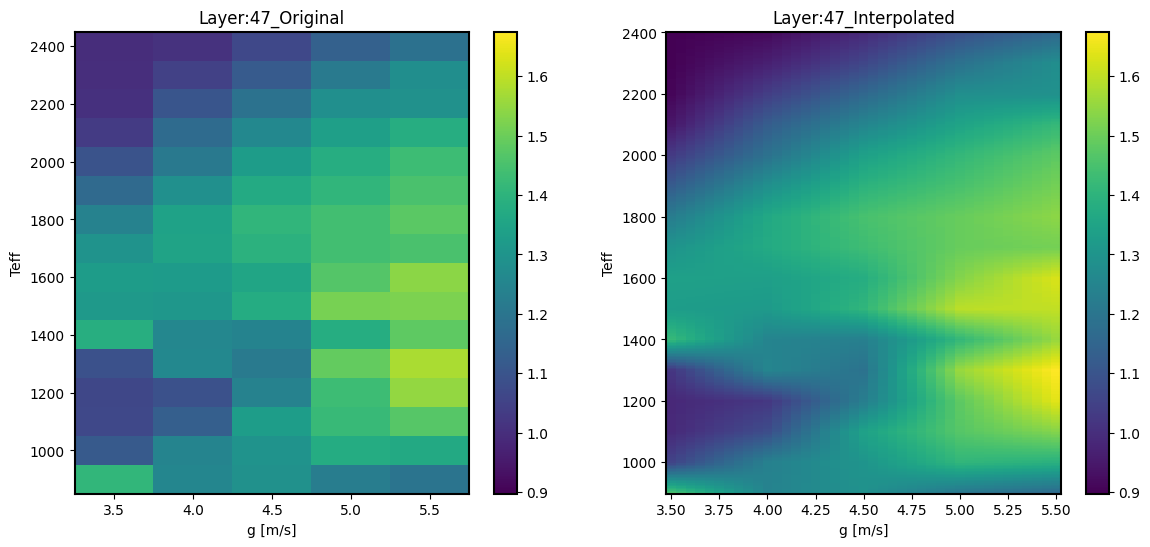

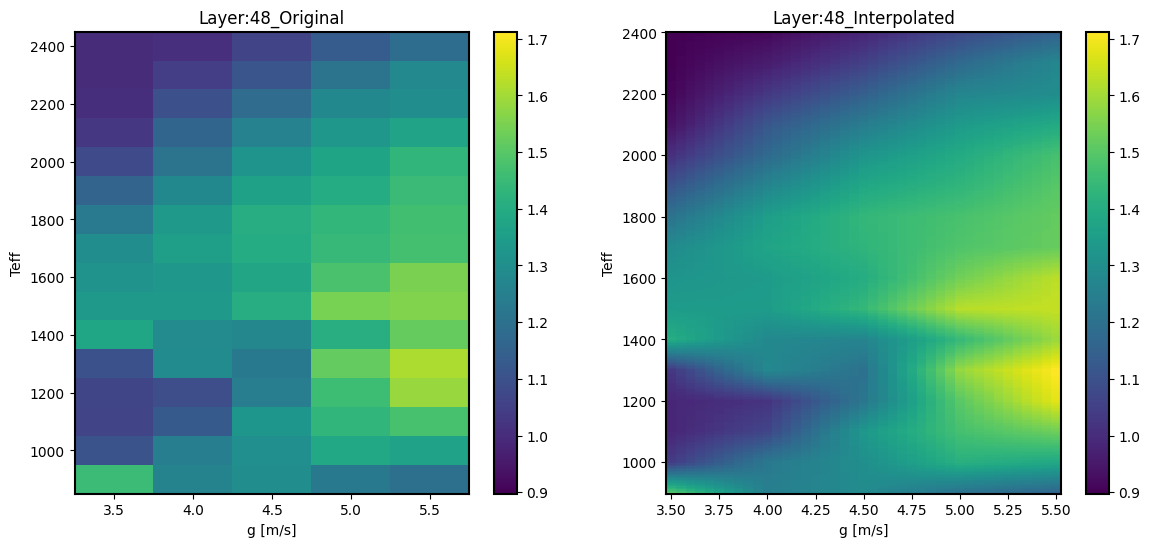

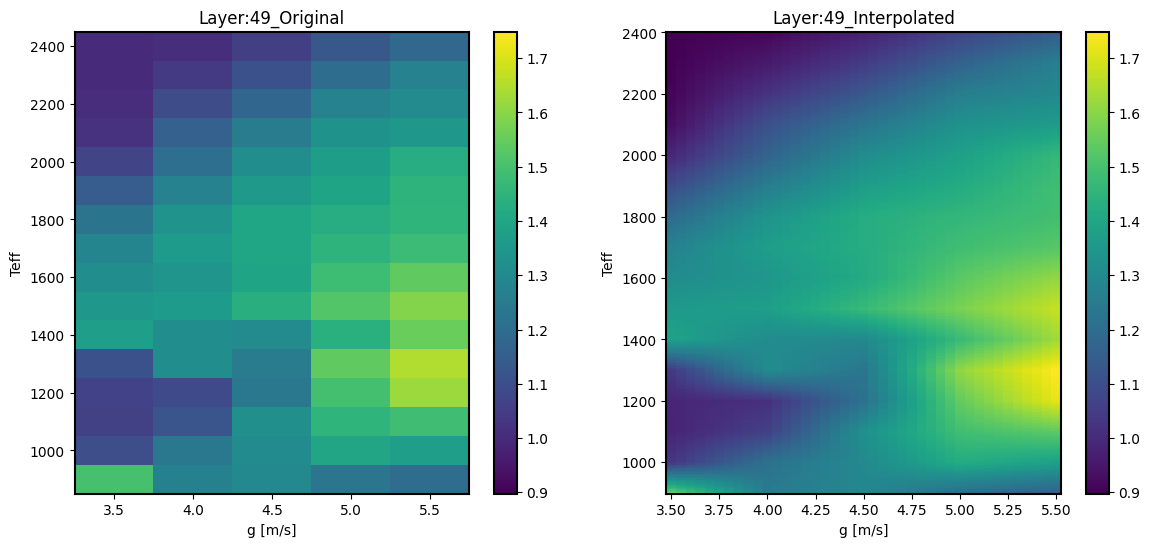

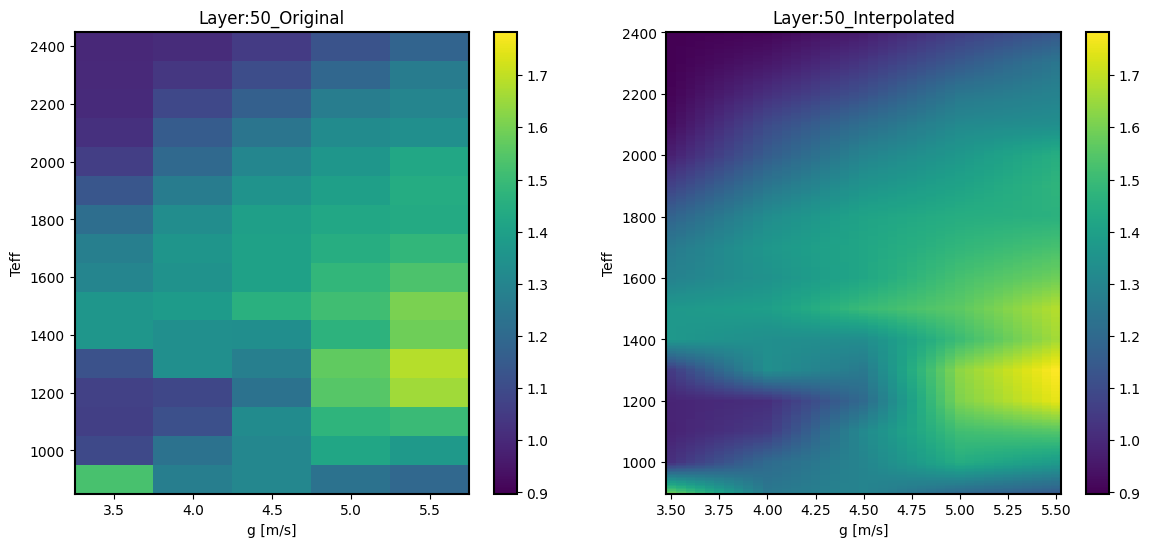

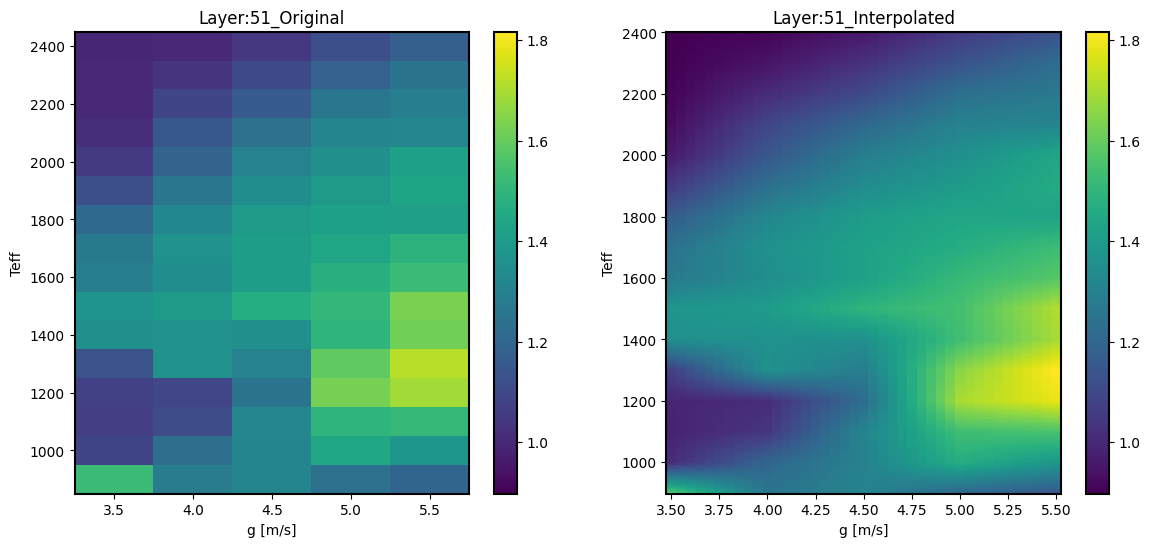

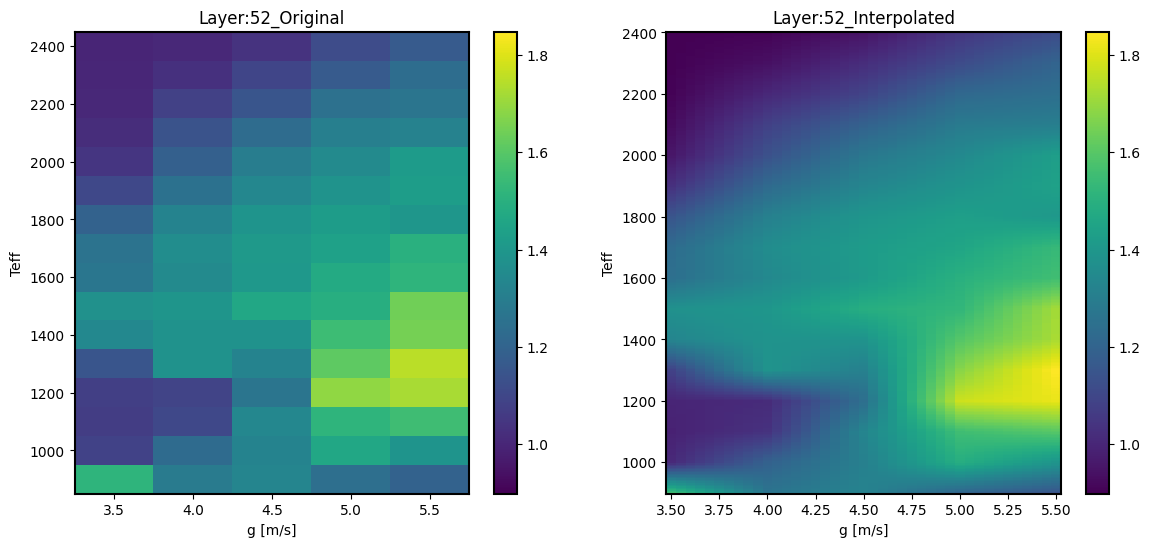

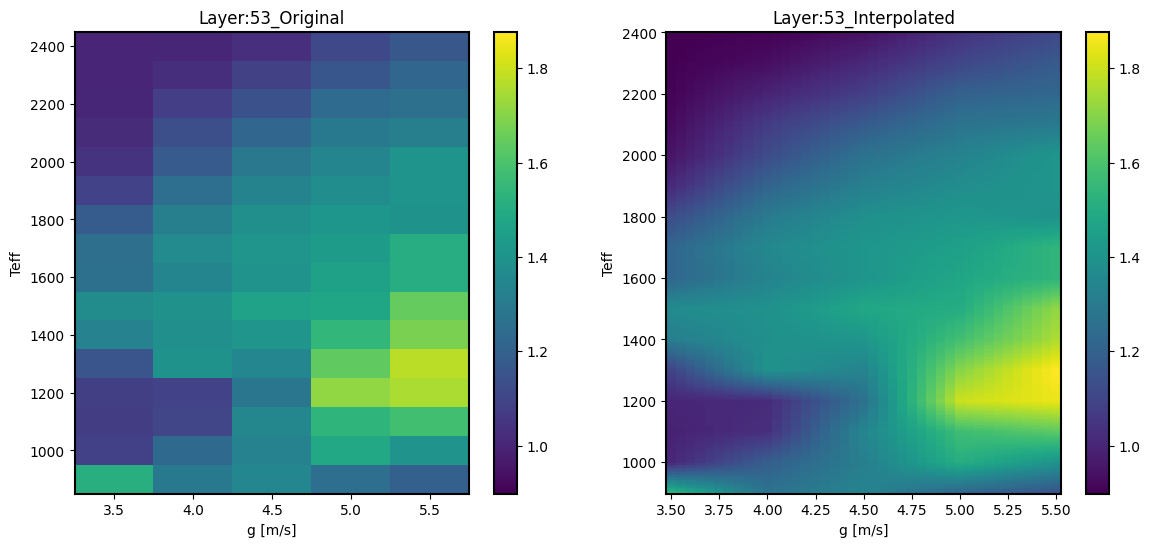

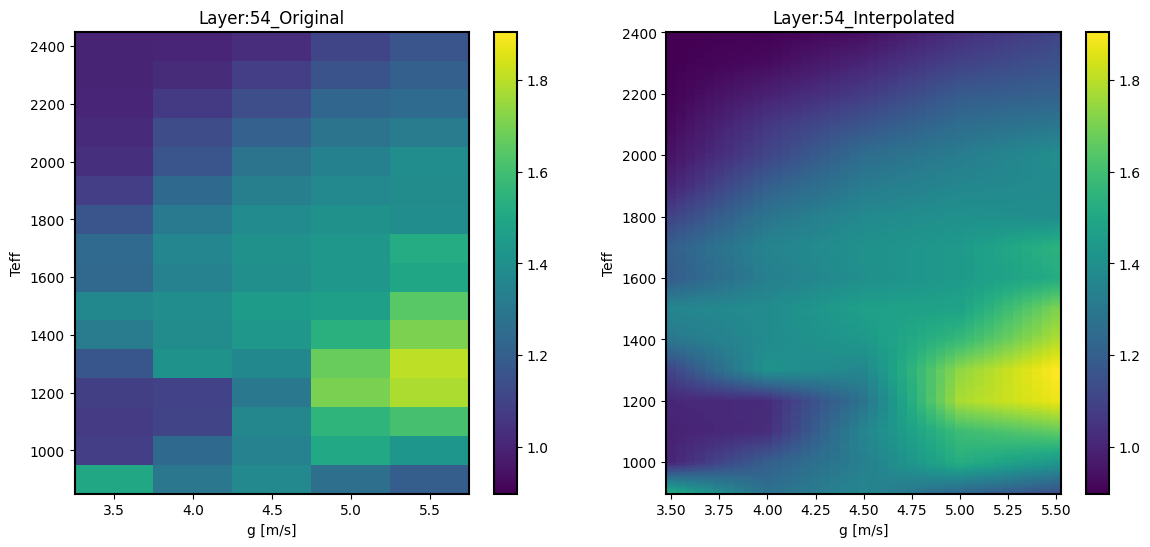

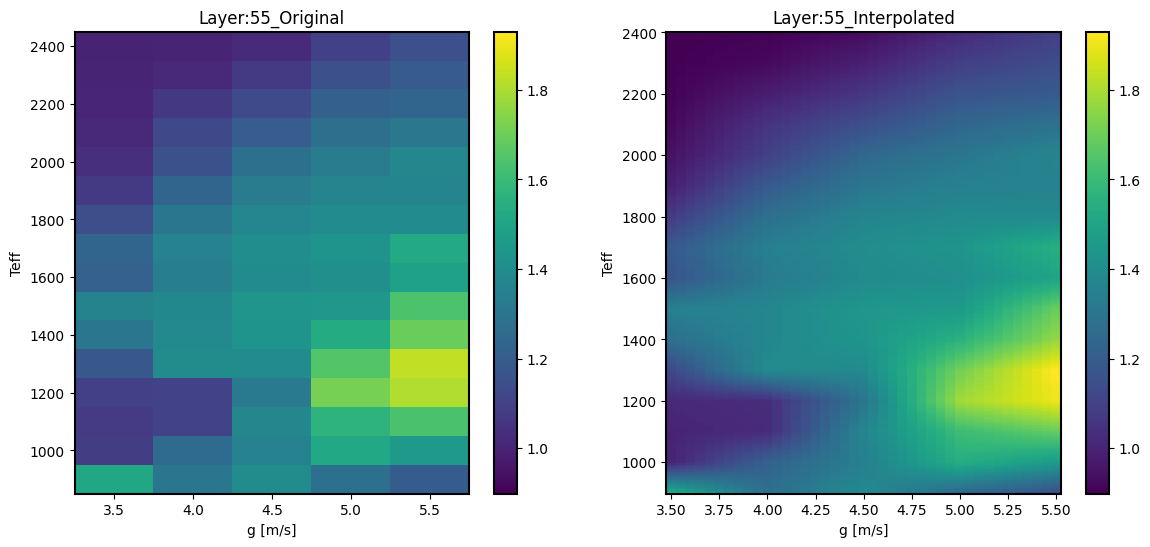

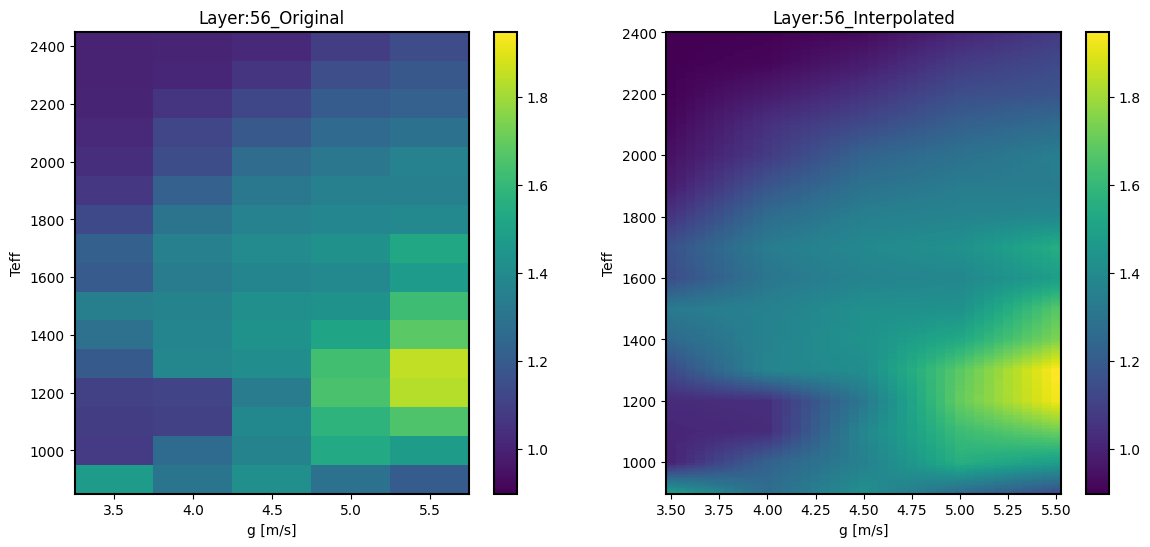

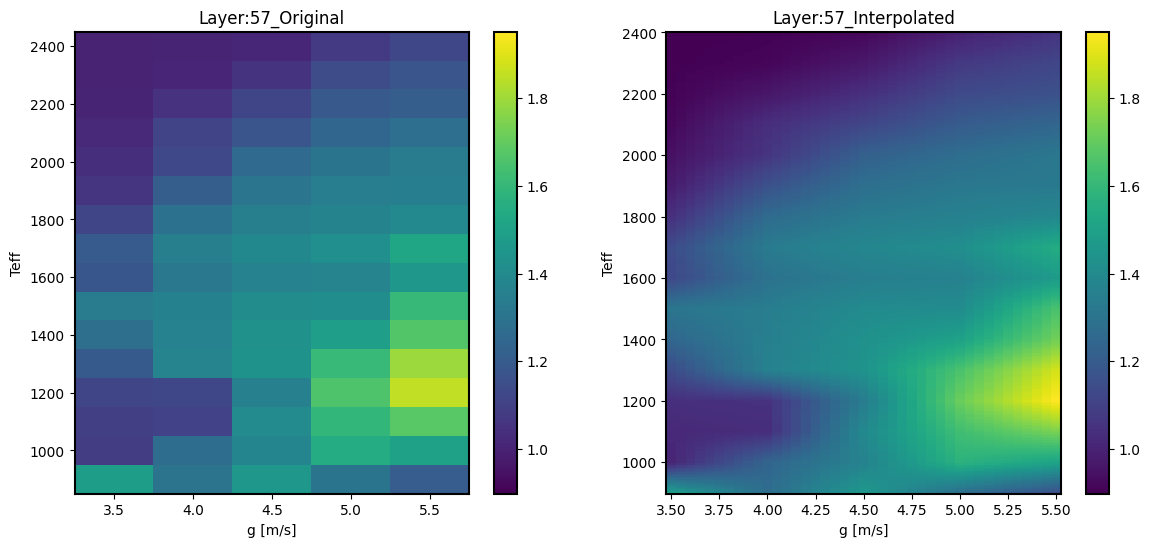

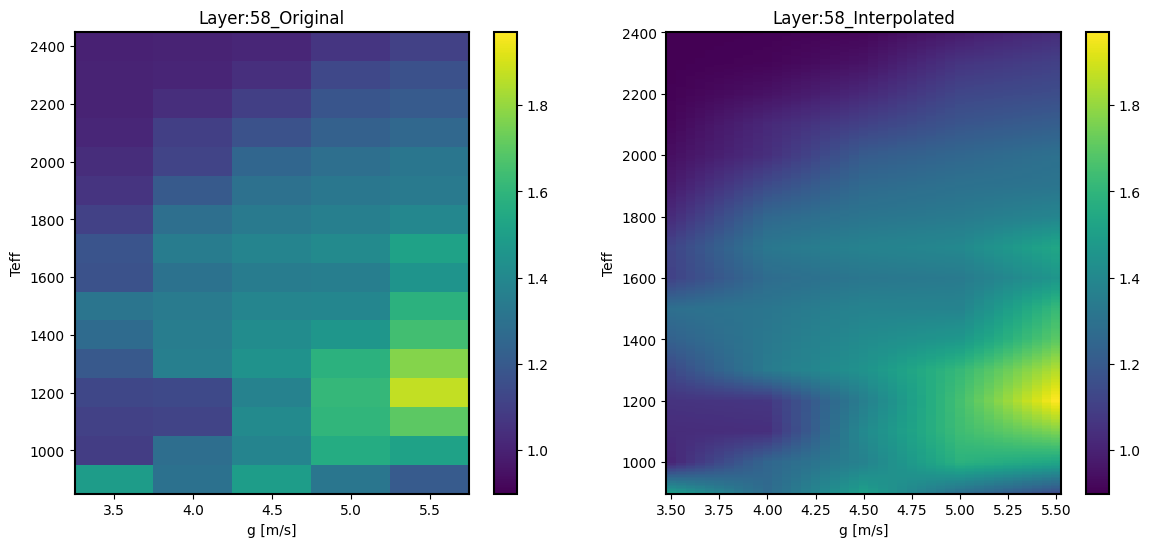

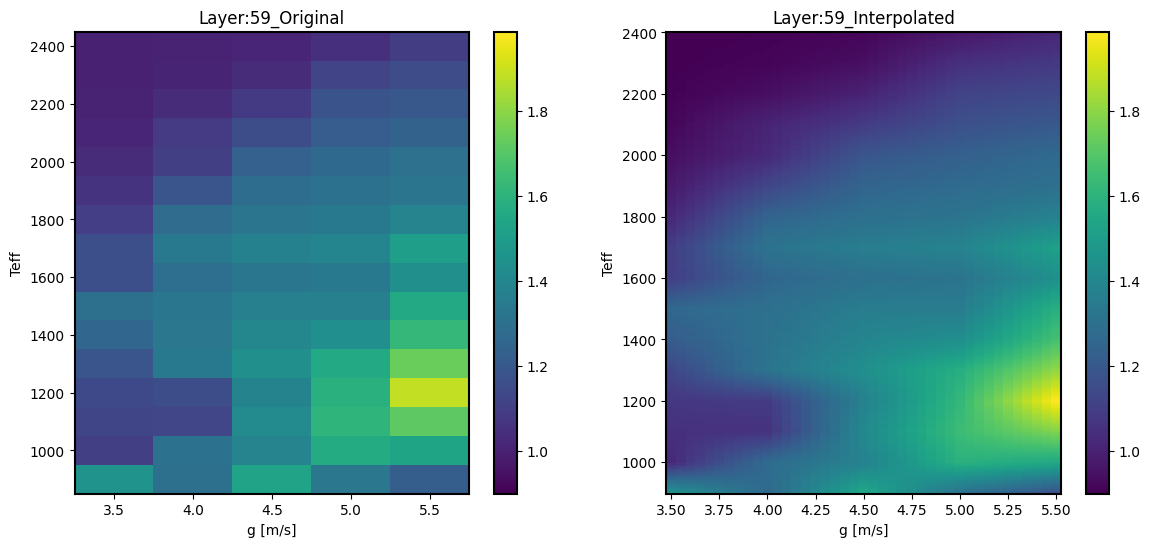

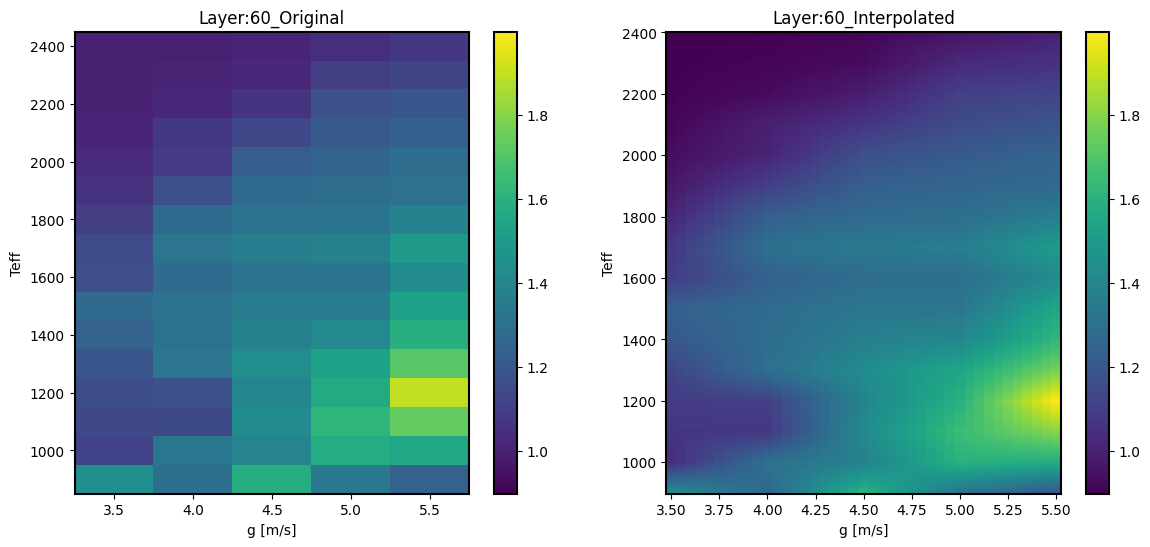

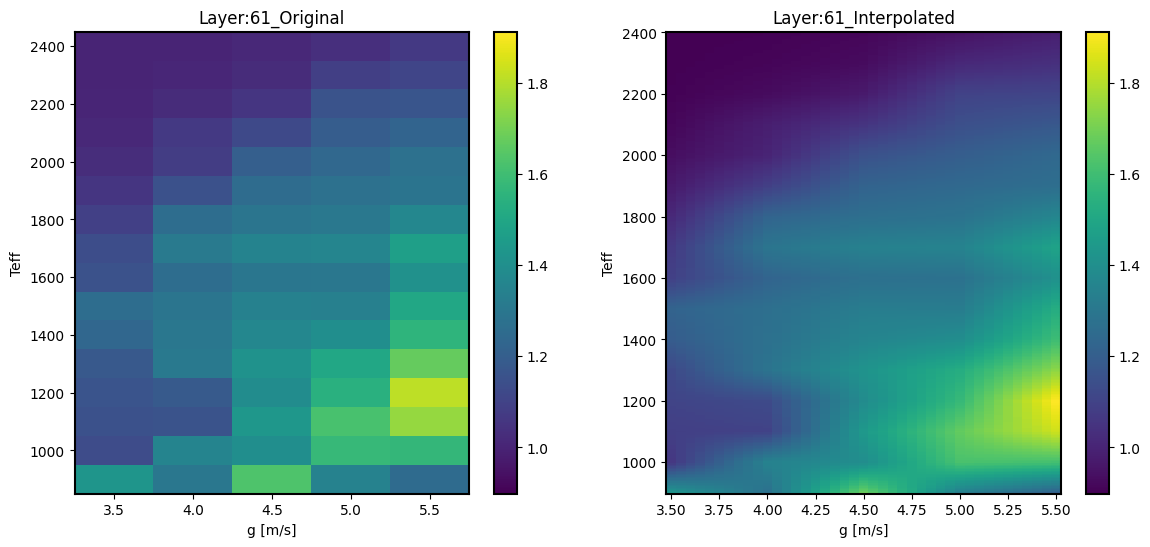

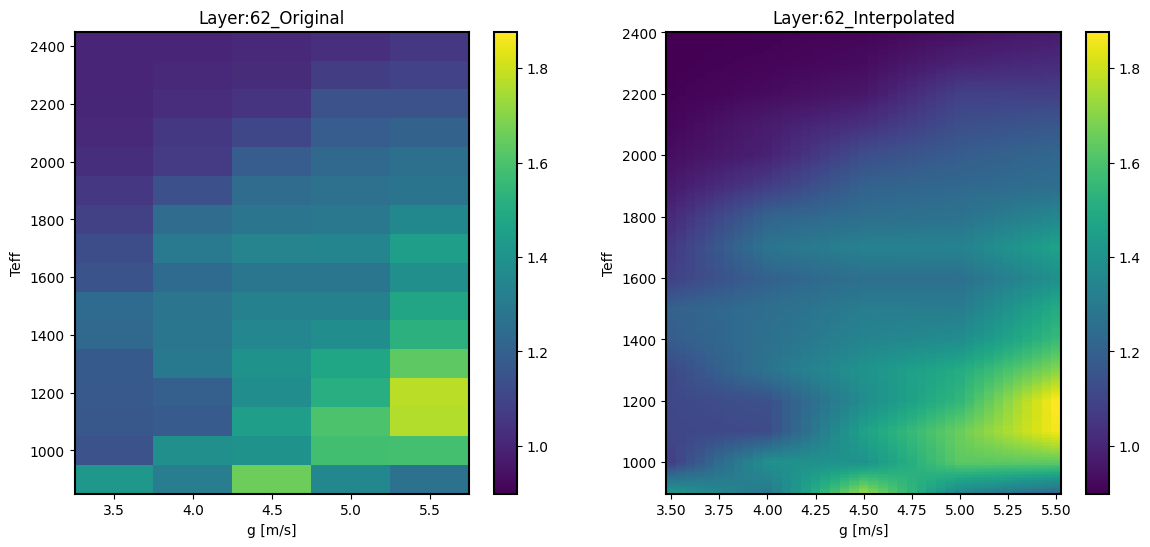

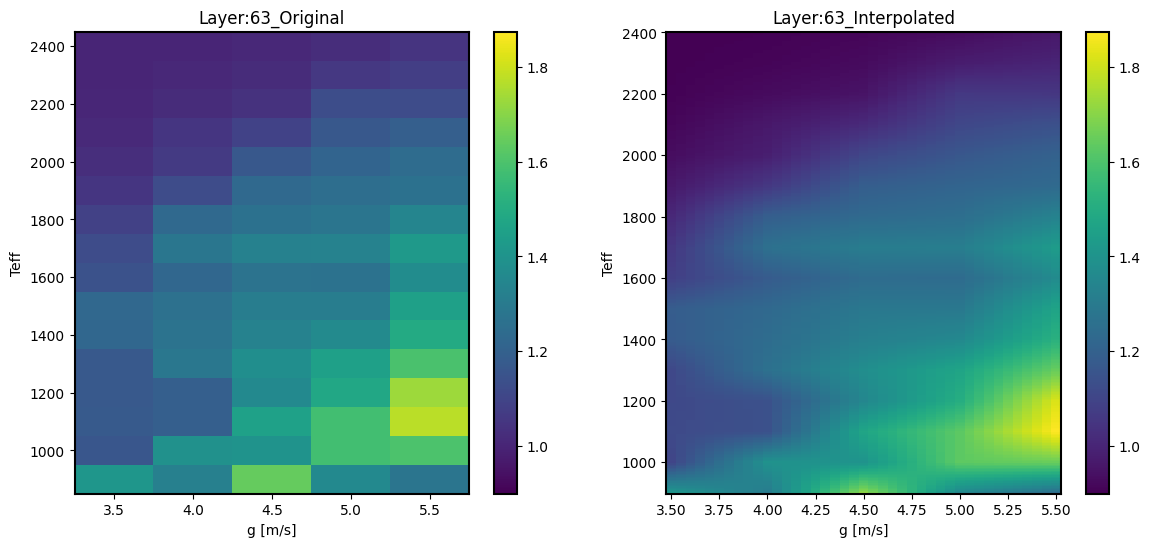

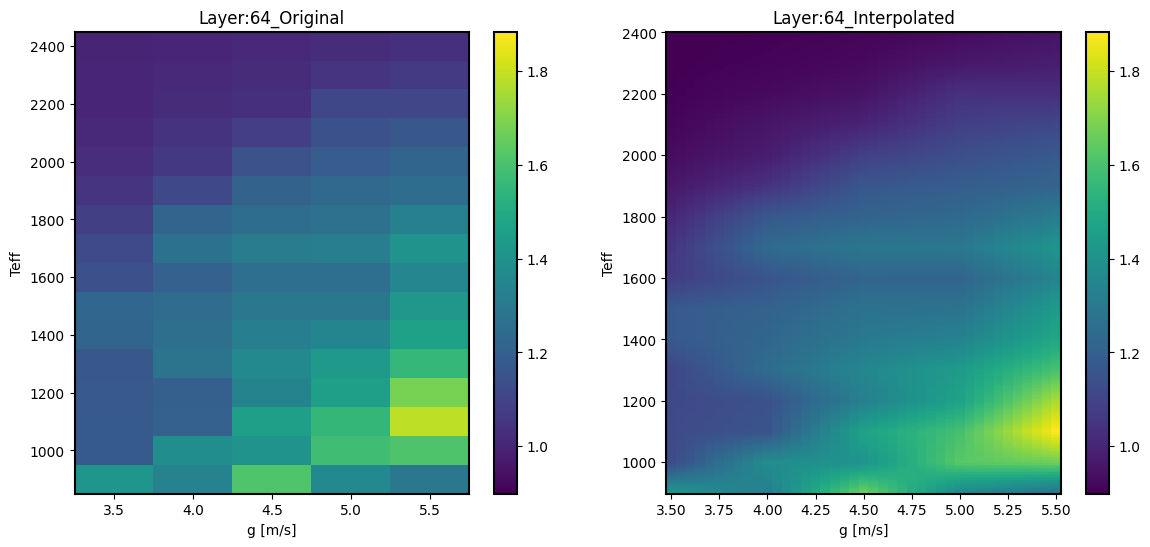

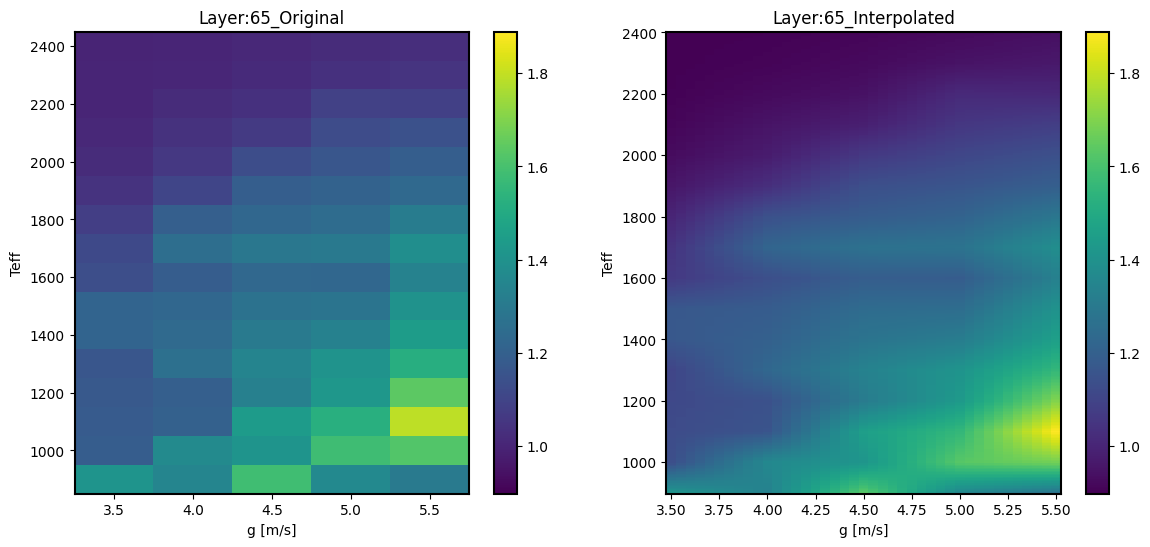

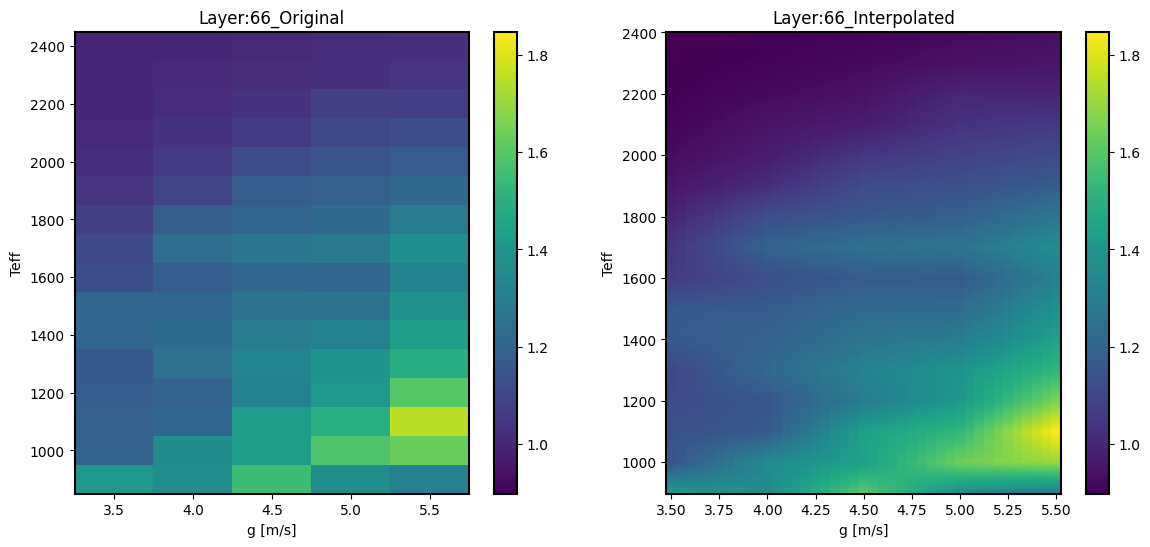

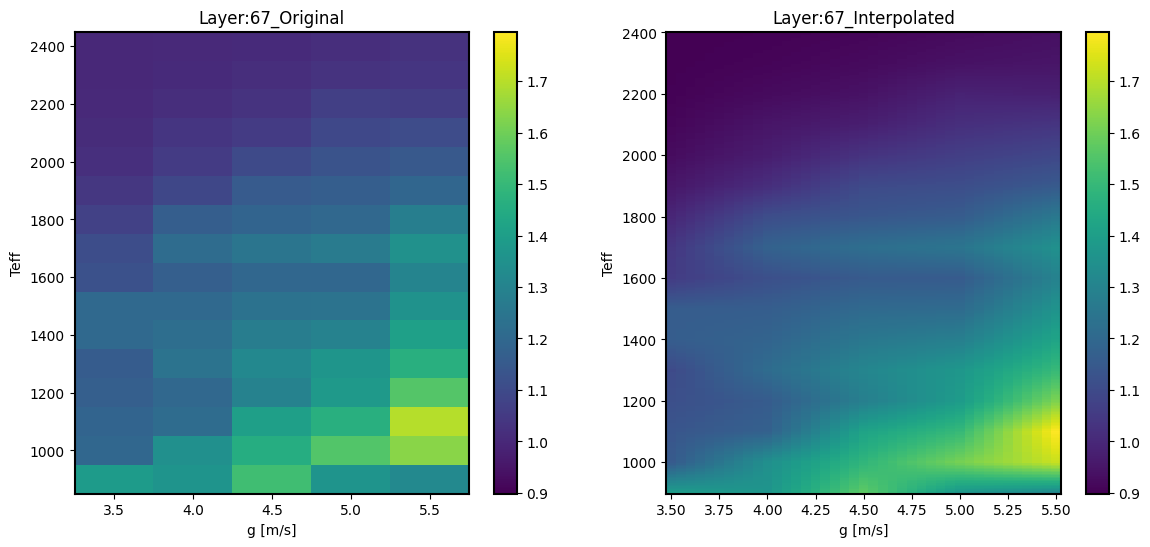

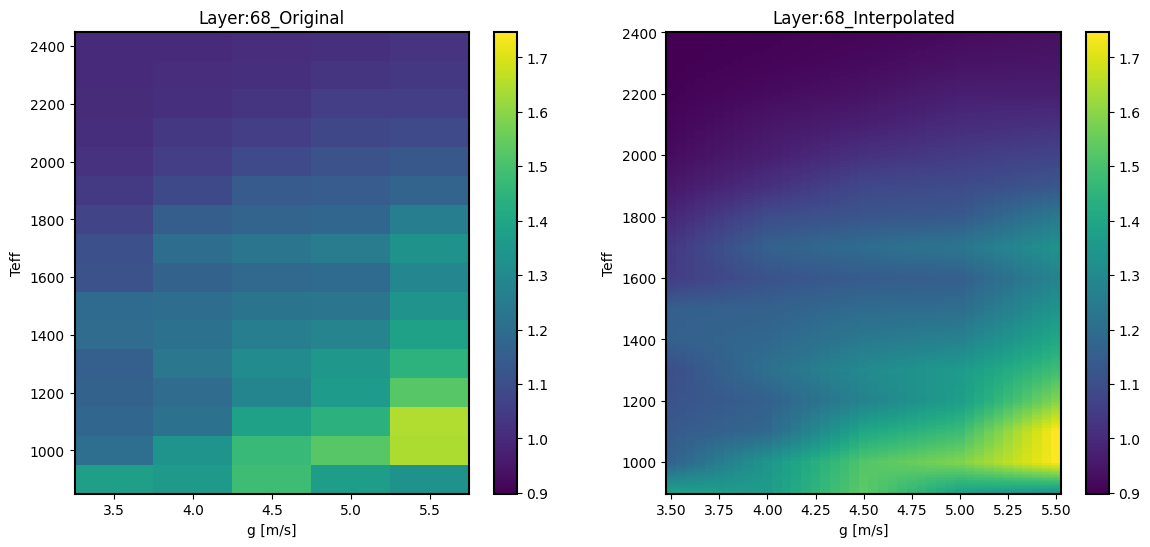

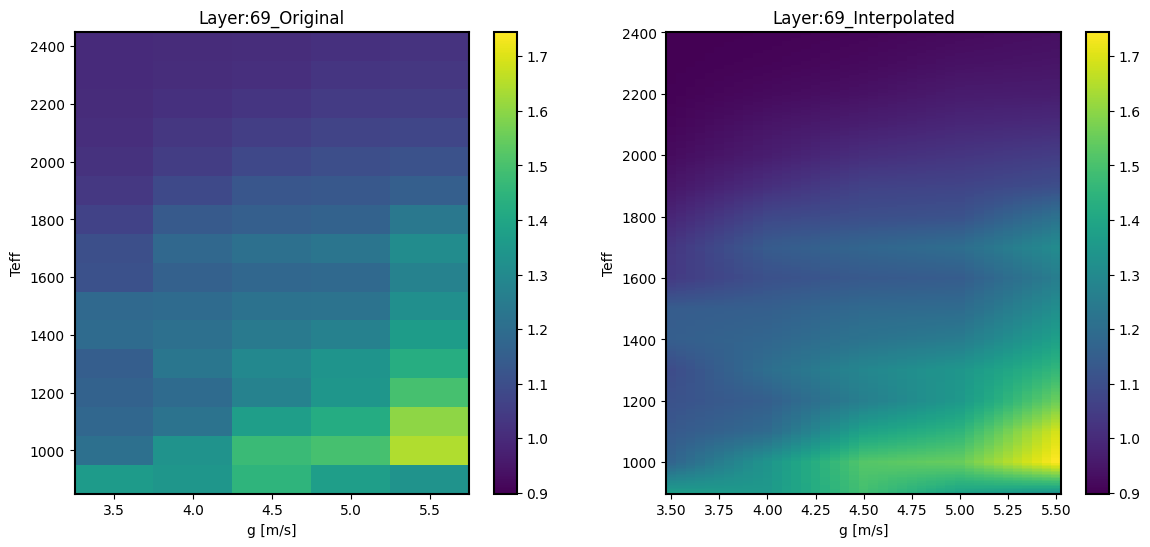

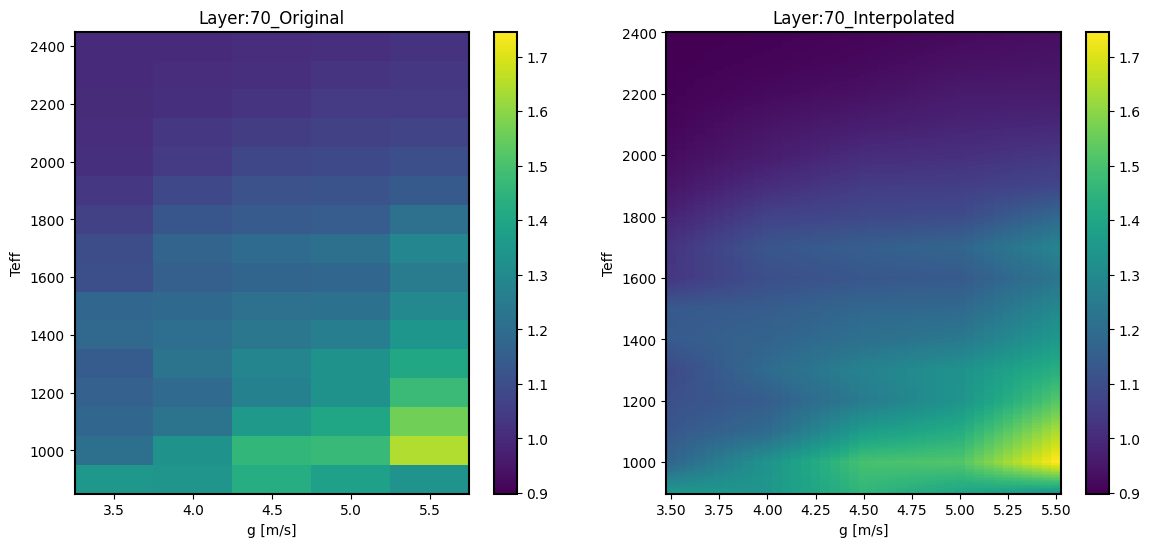

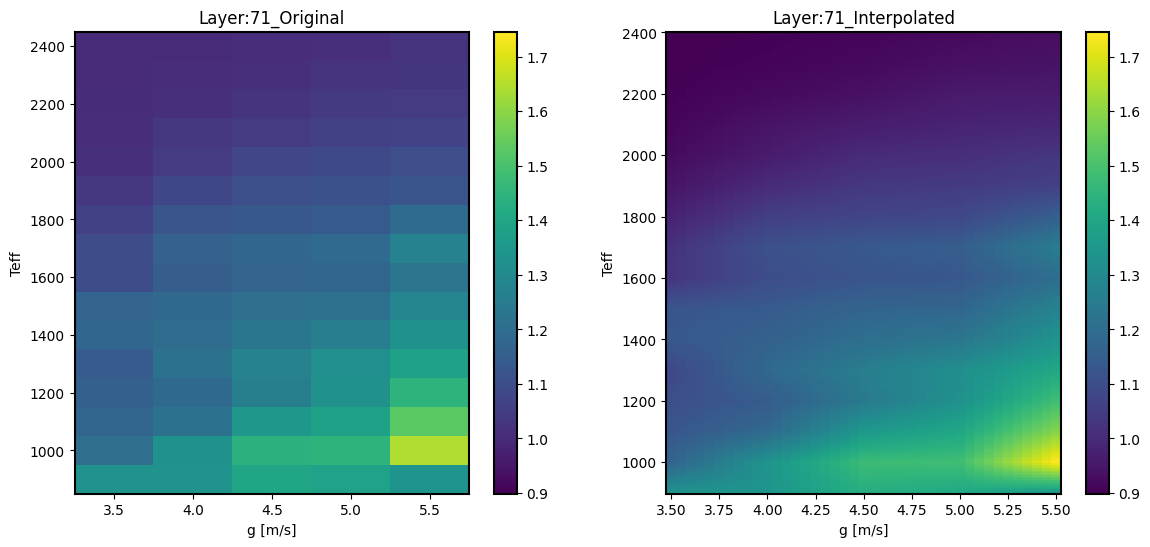

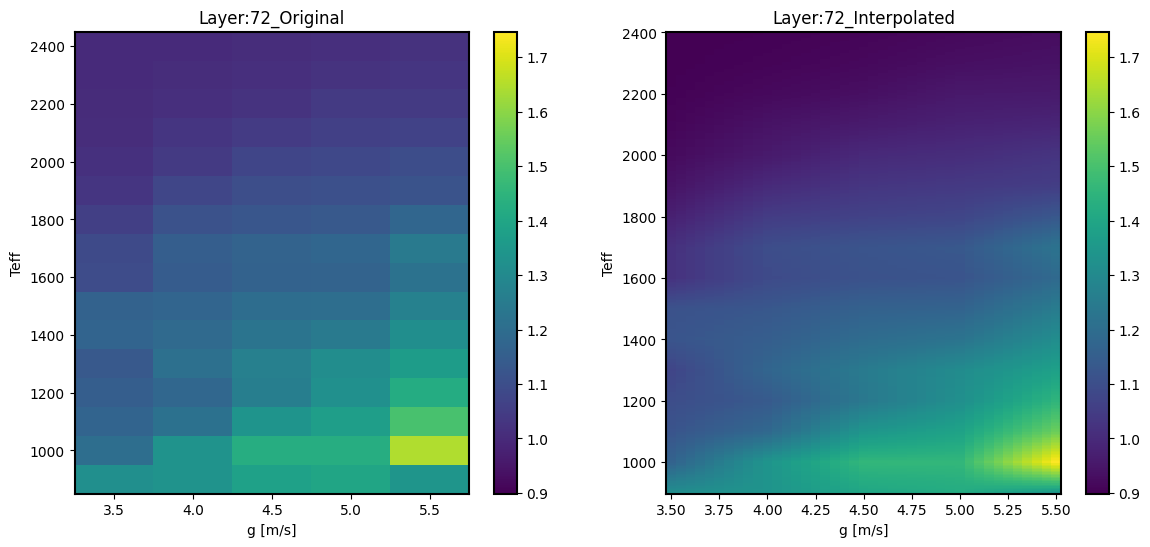

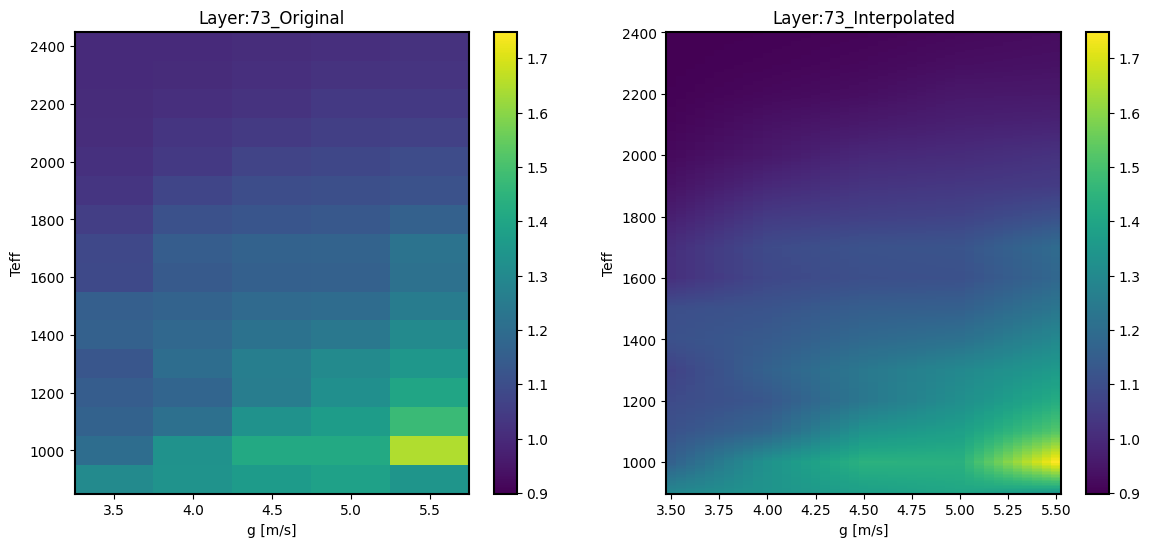

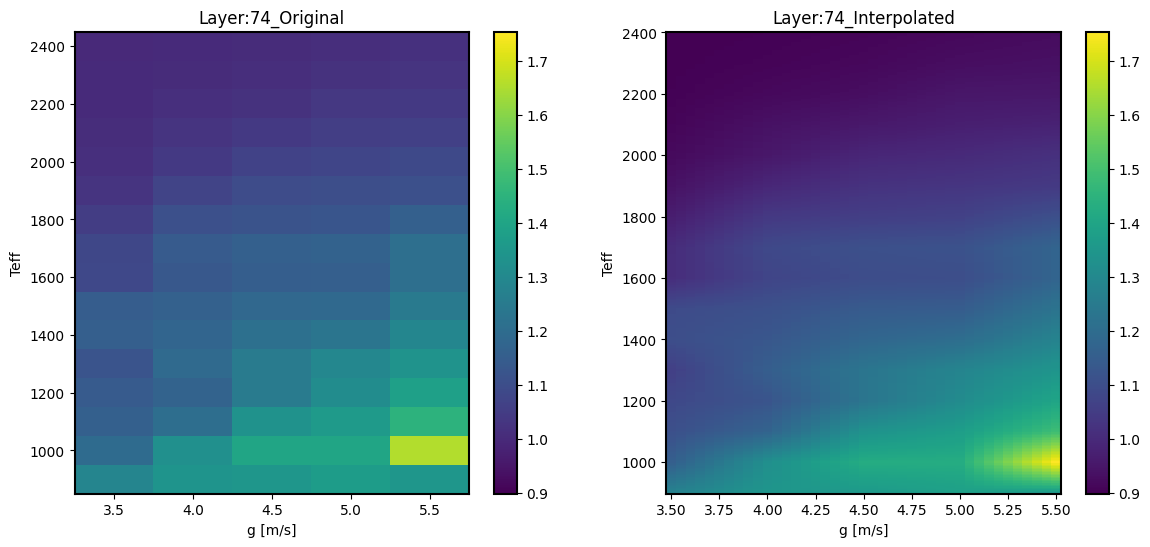

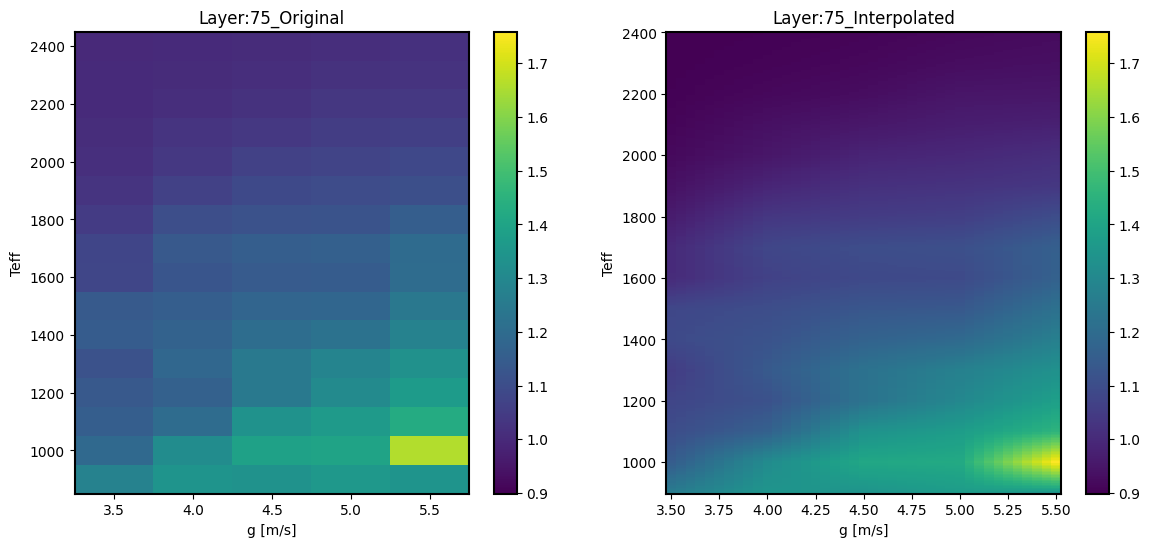

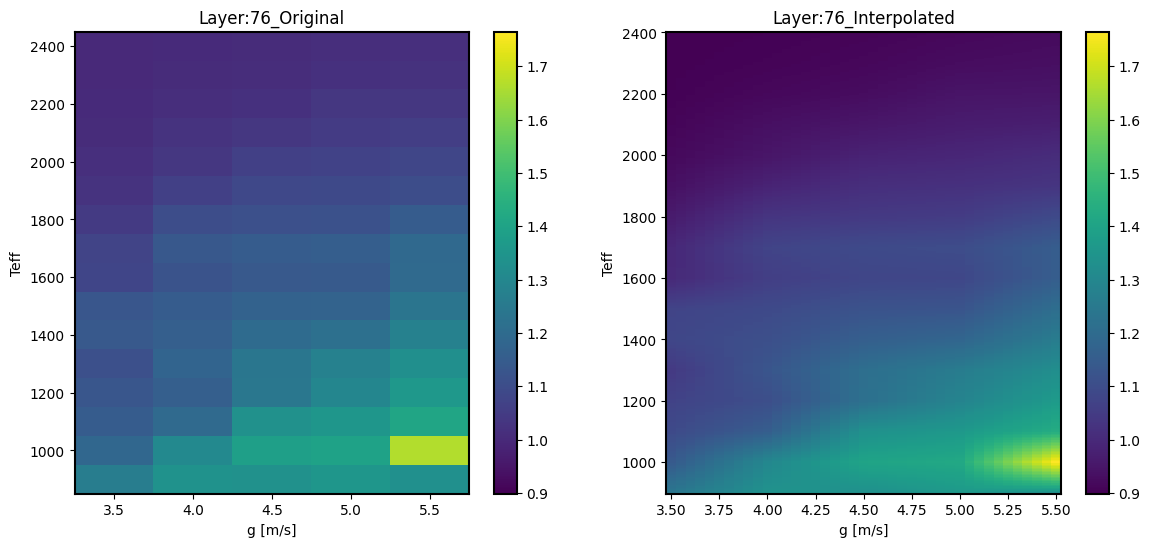

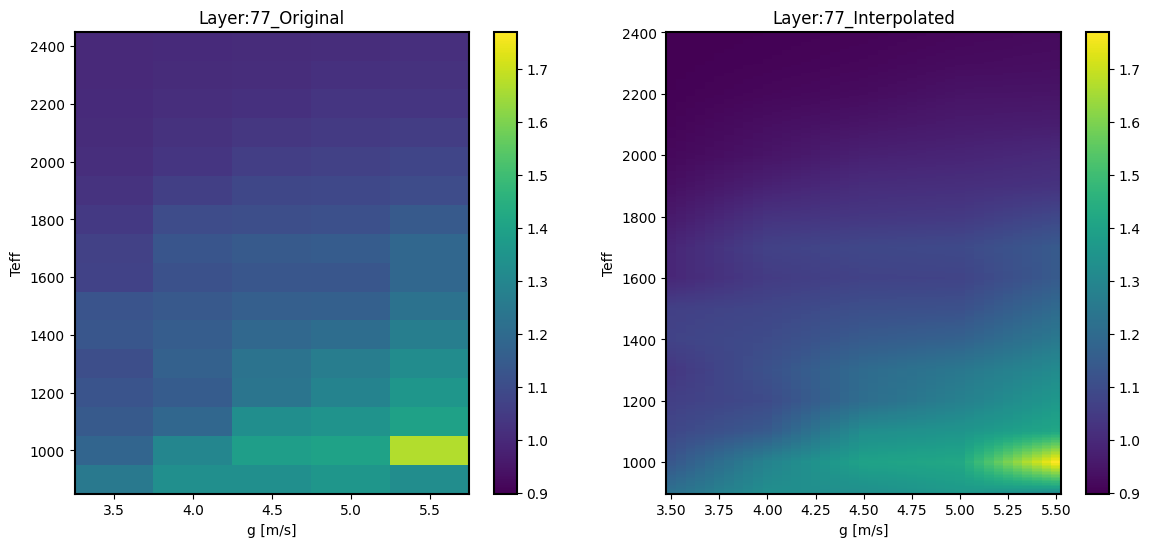

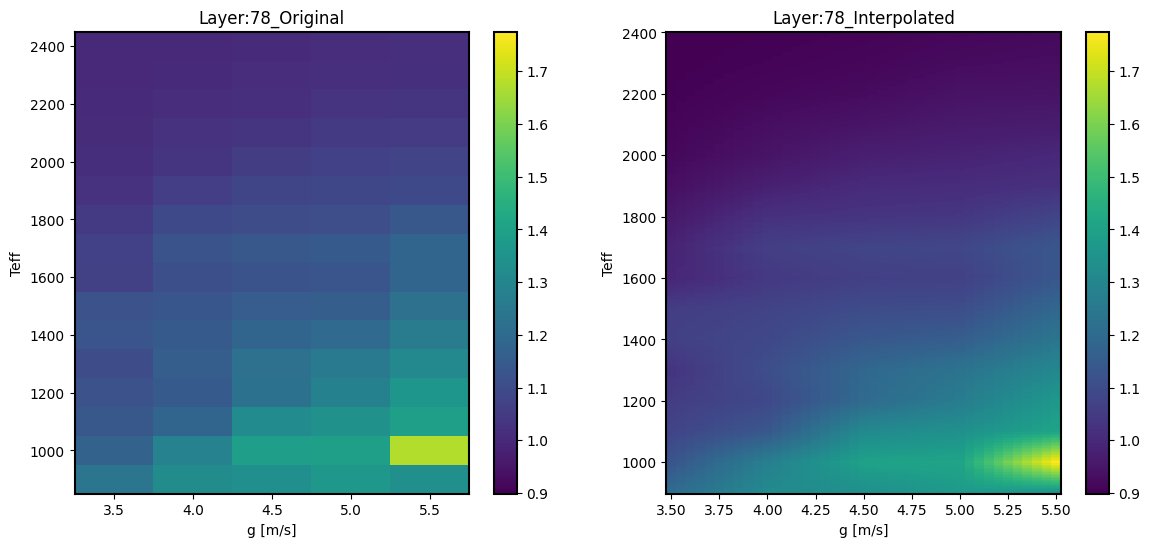

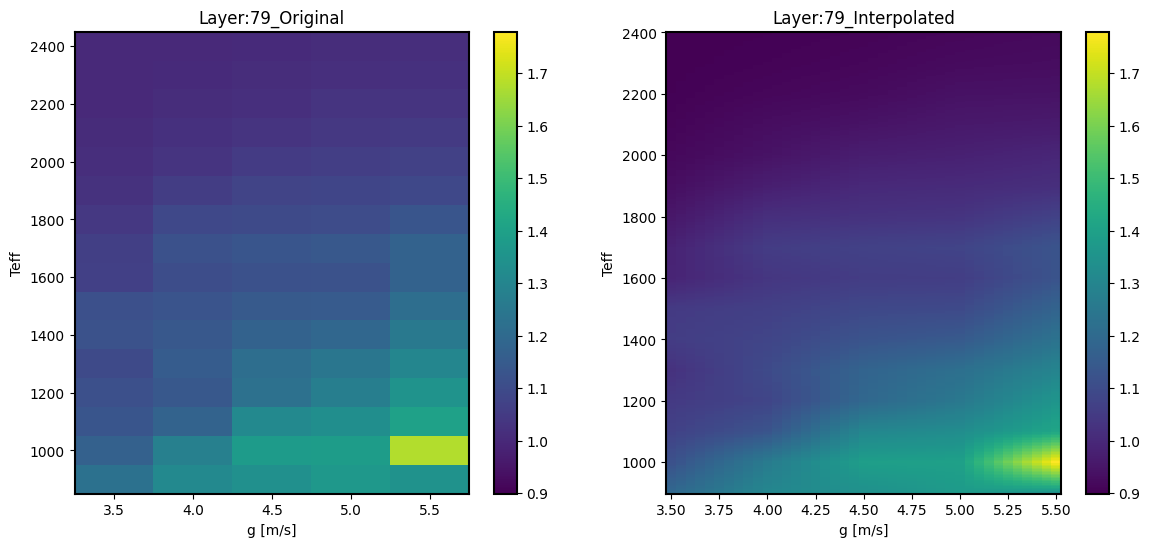

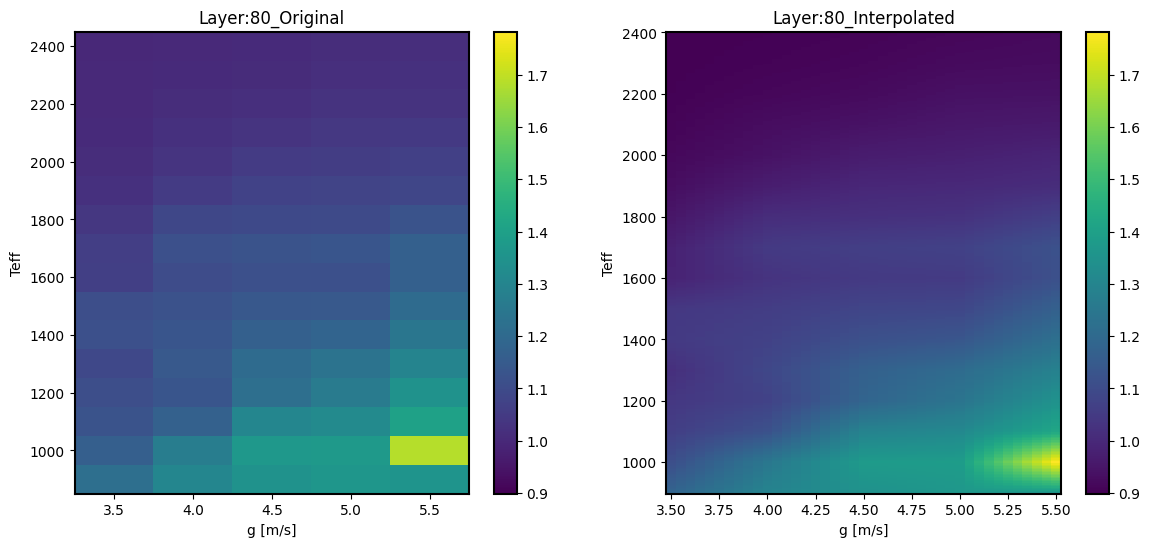

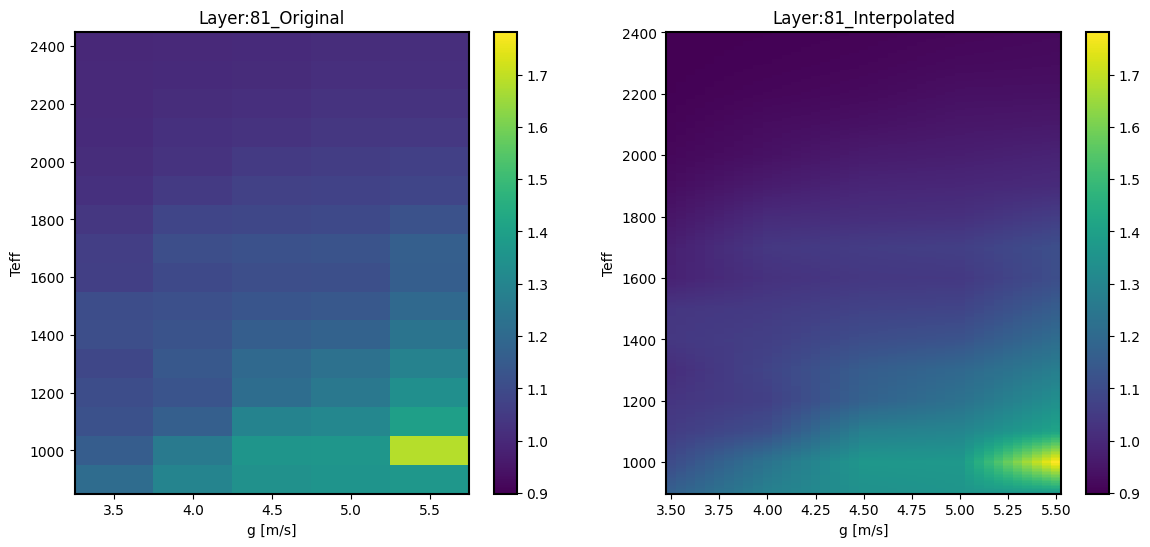

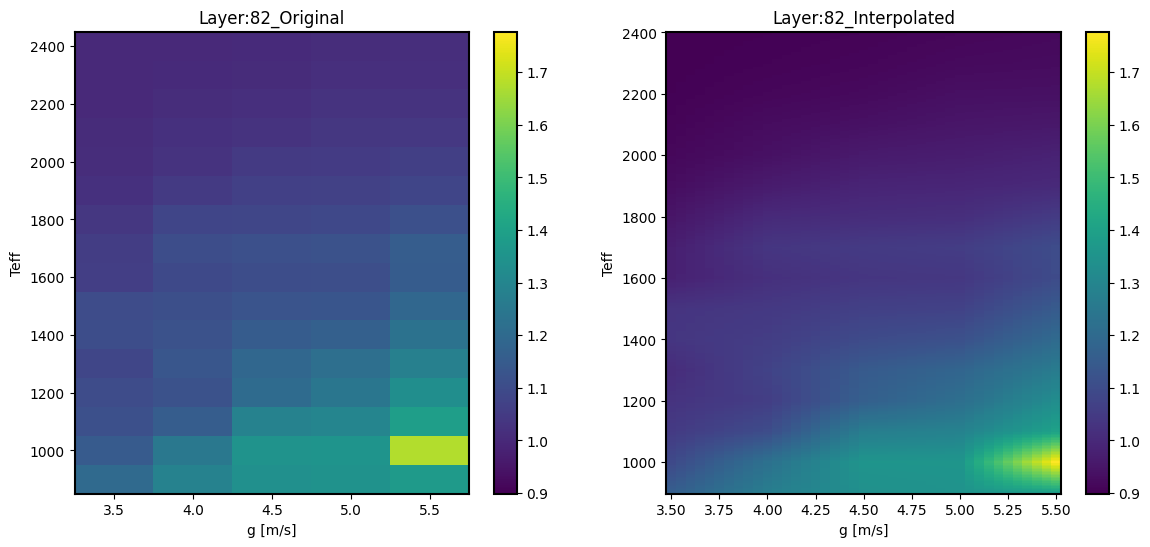

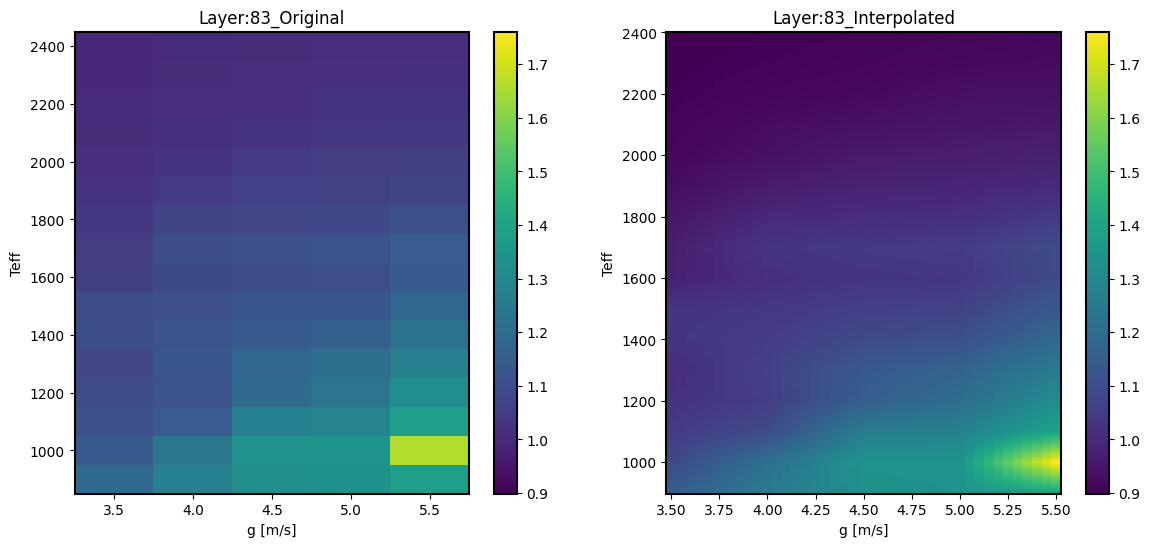

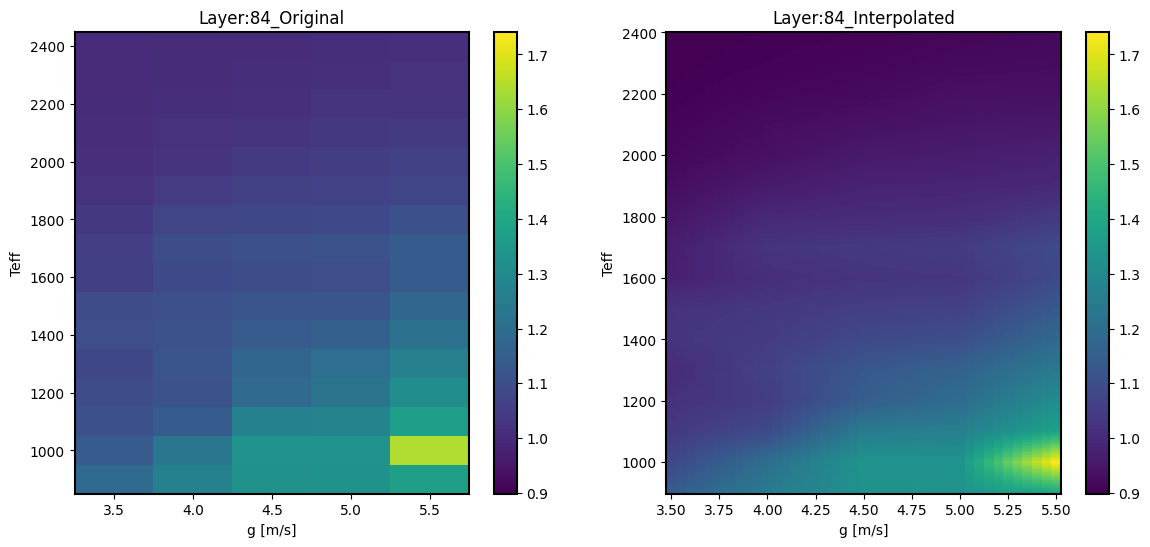

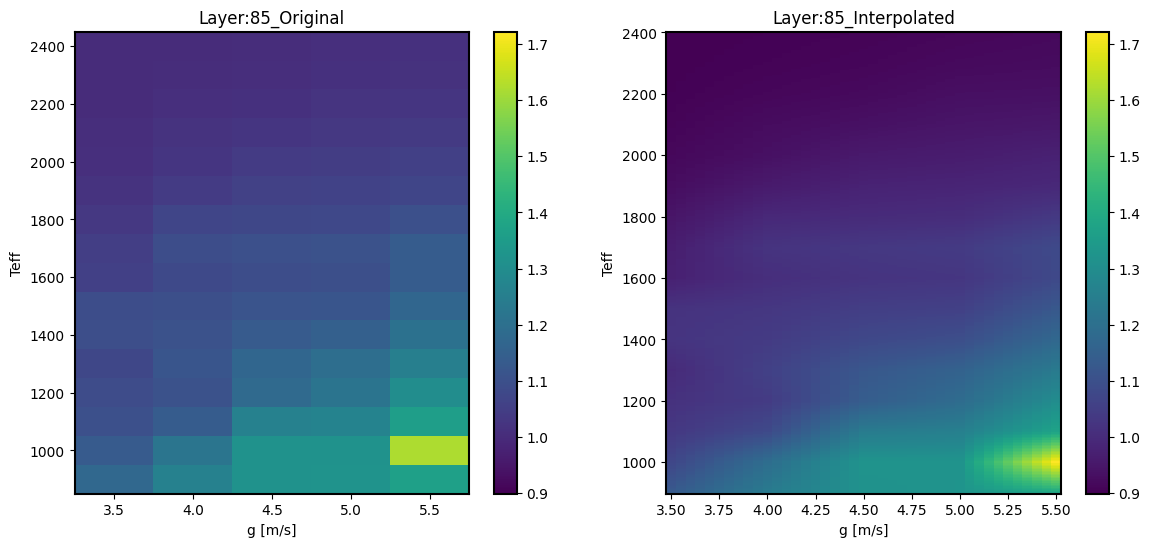

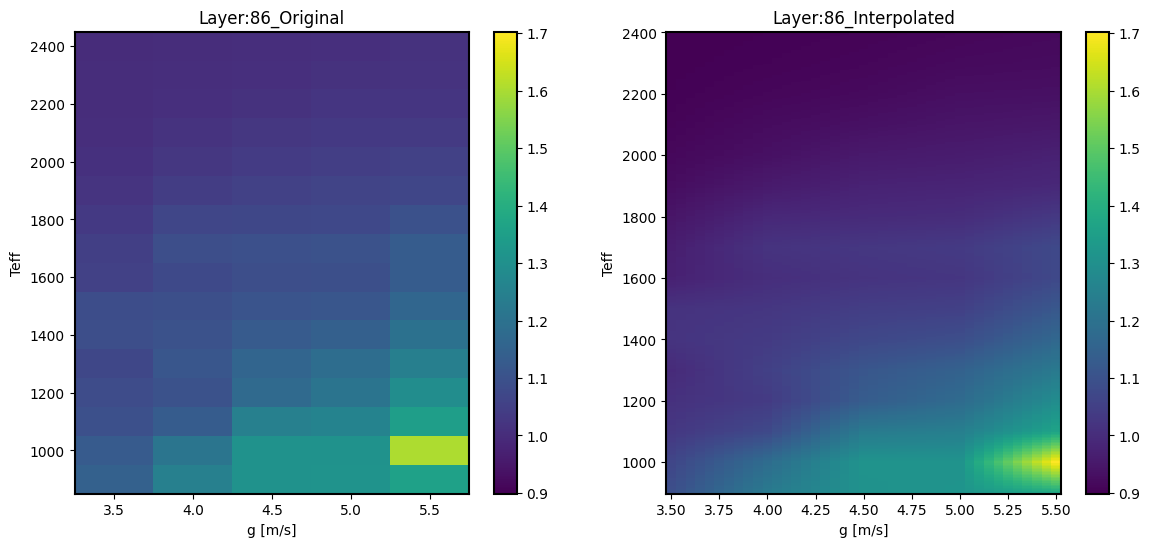

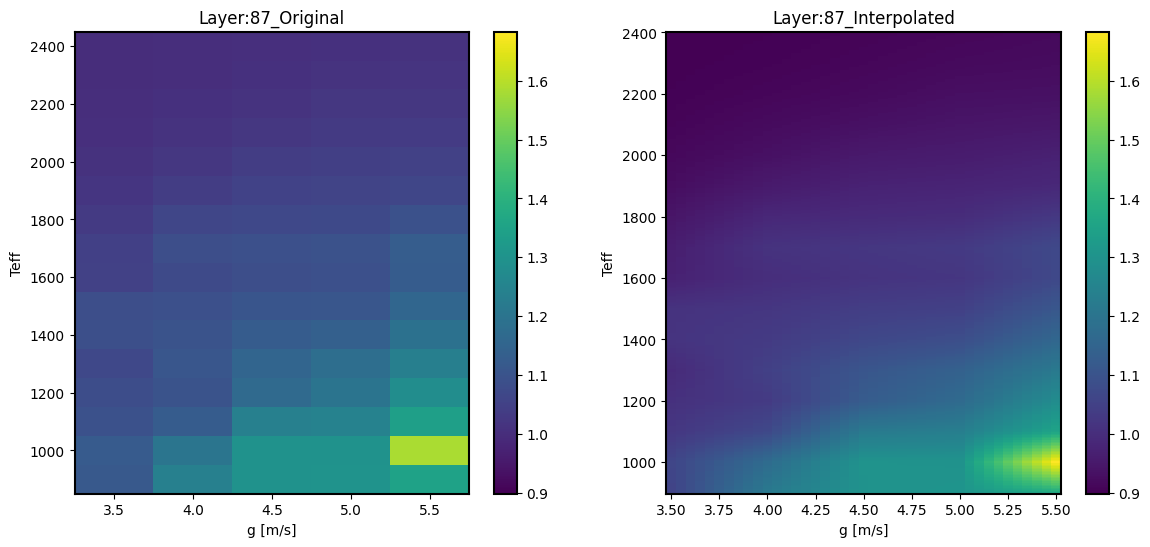

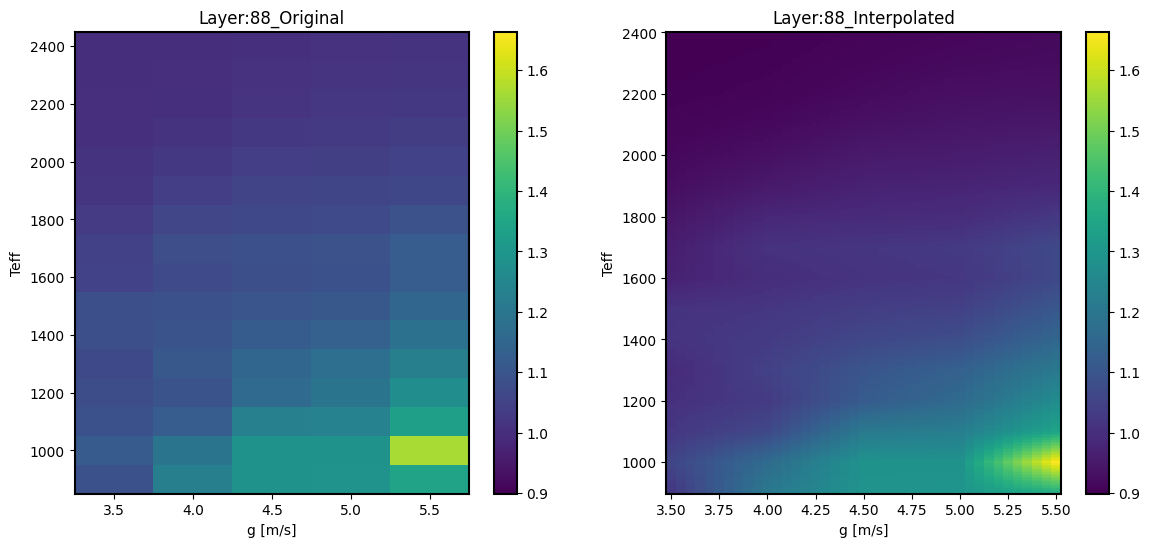

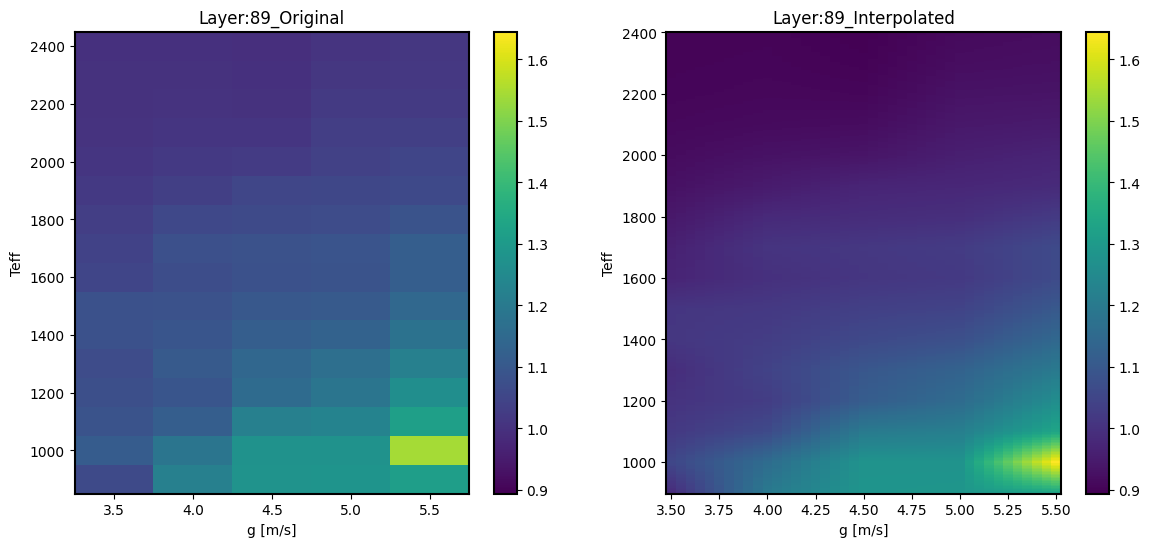

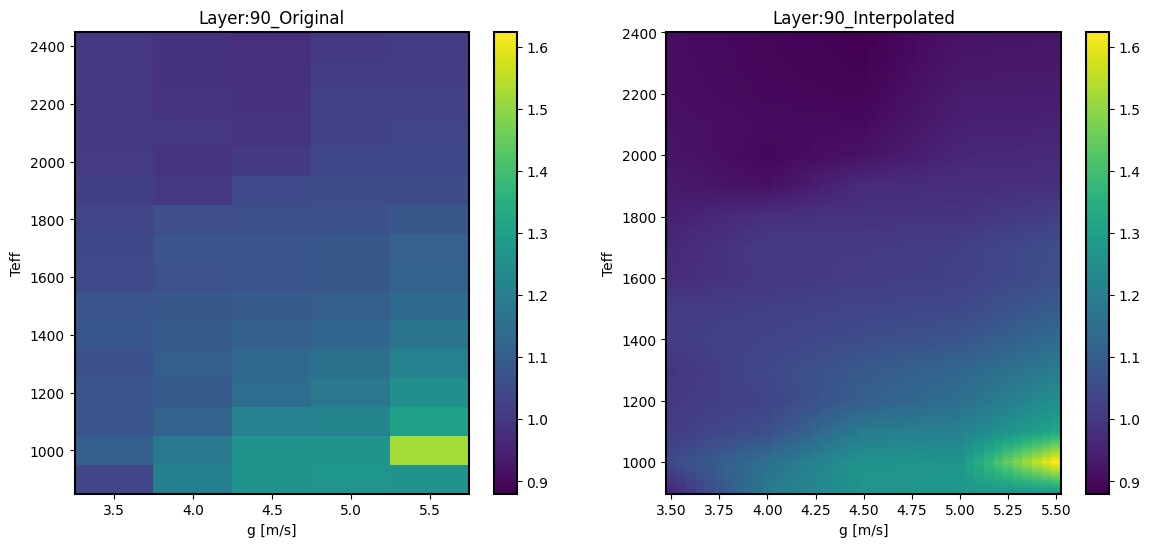

In [438]:
#merge all together into one:


#need imports:
#import numpy as np
#import matplotlib.pyplot as plt

#from matplotlib.colors import BoundaryNorm
#from matplotlib.ticker import MaxNLocator

#import matplotlib.colors as colors
#from pylab import *
#rc('axes', linewidth  = 1.5)
#rc('font', weight = 'normal')
#from scipy.interpolate import RegularGridInterpolator

#define extentions:

diamonds = 'pressure-temperature_profiles_diamondback/'
bobs     = '/home/theodora/Downloads/bobcat_2021/'#'/media/theodora/fbfb9f9c-0f80-42c0-a9d6-1dbd065eddf2/mark_models/'

diamon_ext = '_m0.0_co1.0.pt'
bob_ext    = 'nc_m0.0.dat'#'nc_m0.0.cmp'

#read files:

tt = np.arange( 900, 2500, 100 )
gg = np.array([31, 100, 316, 1000, 3160] )
ff = np.array([1, 2, 3, 4, 8] )

tdiam_bob = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )

t_bobs    = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )
p_bobs    = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )


#for debugging purpose:
#tdiam_bob_init = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )
#pdiam_bob_init = np.zeros( ( len(tt), len(gg), len(ff), 91 ) )
################################

for temps in range(len(tt)):
    for gravs in range( len( gg )):
        for fseds in range( len( ff )):
                
            d1 = np.loadtxt( diamonds+'t'+str(tt[temps])+'g'+
                            str(gg[gravs])+'f'+str(ff[fseds])+
                            diamon_ext, skiprows = 2)
            tdiam = d1[ :, 2 ]
            pdiam = d1[ :, 1 ]

    #        pdiam_bob_init[ temps, gravs, fseds, : ] = pdiam
    #        tdiam_bob_init[ temps, gravs, fseds, : ] = tdiam

            d2 = np.loadtxt(bobs+'t'+str(tt[temps])+'g'+
                            str(gg[gravs])+bob_ext, skiprows = 1)


            t_bobs[ temps, gravs, fseds, : ] = d2[ :, 2 ]
            p_bobs[ temps, gravs, fseds, : ] = d2[ :, 1 ]

            #interpolate diamondback to bobcat P grid:
            
            tdiam_bob[ temps, gravs, fseds, : ] = np.interp( d2[ :, 1 ], pdiam, tdiam )
            

#get g in the right format for the plot and interpolation:
ggpl = np.round(np.log10(gg*100), decimals =1 )#np.log10(gg*100)

#define the denser grids:
tnew = np.arange(900, 2405, 5)
gnew = np.round(np.arange(3.5, 5.54, 0.05), decimals = 3)  #np.floor(10**np.arange(3.5, 5.52, 0.05)/100)


corr_facs = np.zeros( ( len(tnew), len(gnew), len(ff), 91 ) )


#make stupid code to find the indices where tnew/gnew match the old tg grid:
indst = np.zeros( len(tt), dtype = int )
indsg = np.zeros( len(ggpl), dtype = int )

for ii in range( len(tt)):
    indst[ii] = np.where( tnew== tt[ii] )[0][0]

for ii in range( len(ggpl)):
    
    indsg[ii] = np.where( gnew== ggpl[ii] )[0][0]

    


for fsed_ch in range(1,2):
    for p_ch in range(91):
        #make an empty image with NaNs for the interpolation

        inxtrp = np.empty((len(gnew),len(tnew),))
        inxtrp[:] = np.nan


        
        #define the ratio of diamondback to bobcat t 

        img = tdiam_bob[ :, :, fsed_ch, p_ch] / t_bobs [ :, :, fsed_ch, p_ch ]
        
        # I swear this can be done more efficiently but cannot think of how right now
        iin = 0 

        for ii in indst:
            jin = 0
            for jj in indsg:
                inxtrp[ jj, ii ] = img[ iin, jin ]
                jin +=1
            iin +=1

        #change the x and y axis so that it plots as it should
        inxtrp = np.swapaxes(inxtrp,0,1) 
    
    
        #now plot everything
        # first the original grid:
        
        fig, (ax1,ax2) = plt.subplots( 1,2, figsize = (14,6))
        # kernel = Box2DKernel(3)
        bounds = np.linspace( 0, 240, 400)
        norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
        pcm = ax1.pcolormesh( ggpl,tt , 
                        img,
                       vmin= np.min(img)-.1, vmax = np.max(img) +.1)#,   
   # pcm2 = ax.contour( gnew, tnew,np.flip(inxtrp,0))
#                 cmap = 'RdYlBu')
        ax1.set_title('Layer:'+str( p_ch ) +'_Original')
        #ax1.colorbar(pcm, label='Ratio')
        fig.colorbar(pcm, ax=ax1)
        ax1.set_xlabel('g [m/s]')
        dm = ax1.set_ylabel('Teff')
        #plt.show()

        #now the interpolated one:
        
     #   fig, ax = plt.subplots( 1,1, figsize = (6,6))
    
        # kernel = Box2DKernel(13)
        #x_new, y_new = np.meshgrid(gnew, y_new)

        #do the Interpolation
        interp_func  = RegularGridInterpolator((tt, ggpl), img)

        # this is the grid of ratios we are after for going from DB to Peter's grid:
        reconstructed_image2 = interp_func((tnew[:, np.newaxis], gnew))
        bounds = np.linspace( 0, 240, 400)
        norm = colors.BoundaryNorm( boundaries= bounds, ncolors=456)
   # pcm = ax.pcolormesh( ggpl,tt , 
   #                     img,
   #                    vmin= np.min(img)-.1, vmax = np.max(img) +.1)#, 
    
        pcm2 = ax2.pcolormesh( gnew,tnew , reconstructed_image2)#, 
#                 cmap = 'RdYlBu')
        ax2.set_title('Layer:'+str( p_ch )+'_Interpolated' )
        fig.colorbar(pcm, ax=ax2)
    #    ax2.colorbar(pcm2, label='Ratio')
        ax2.set_xlabel('g [m/s]')
        dm = ax2.set_ylabel('Teff')
        plt.show()
        
        #add the correction factors to the mega array that stacks them all:
        corr_facs[ :, :, fsed_ch,p_ch ] = reconstructed_image2


In [405]:
#now lets try to interpolate a TP profile:

import os 
import pandas as pd

path_to_TP_peter = '/media/theodora/opacities3/petermodels/profiles/'
petr_ext    = 'nc_m0.0.cmp.gz'#

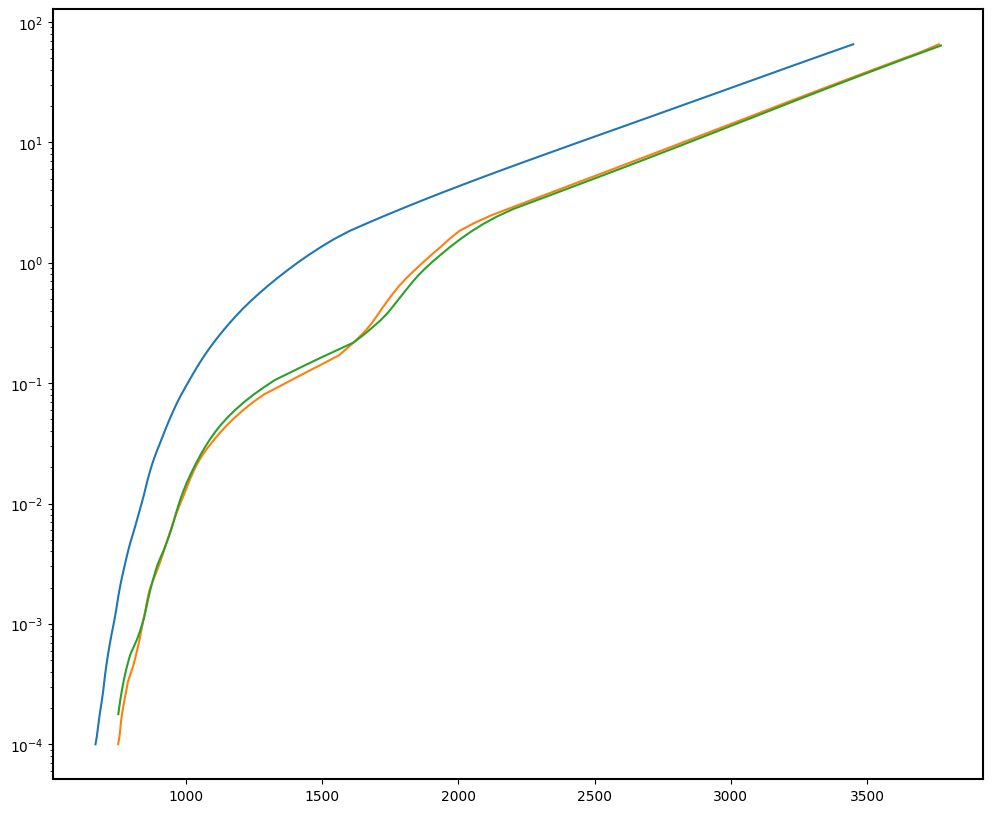

In [449]:
temp = 1500
grav = 316

ptchem = pd.read_csv(path_to_TP_peter+'t'+str(temp)+'g'+str(grav)+petr_ext,sep='\s+',compression='gzip')

t_cld_free = ptchem['TEMP']
p_cld_free = ptchem['P(BARS)']

tloc = np.min(np.where( tnew >= temp) )
gloc = np.min(np.where( gnew >= np.round( np.log10(grav*100), decimals =3 )) )

        

cor_fac_vs_P = corr_facs[ tloc, gloc , fsed_ch, :]

#check it out:

plt.figure(figsize=(12,10))
plt.semilogy( t_cld_free, p_cld_free )
plt.semilogy( t_cld_free*cor_fac_vs_P, p_cld_free )

#oplot the diamondback to compare:
compsmod = np.loadtxt( diamonds+'t'+str(temp)+'g'+
                            str(grav)+'f'+str(ff[fsed_ch])+
                            diamon_ext, skiprows = 2)

plt.semilogy( compsmod[:,2], compsmod[:,1] )

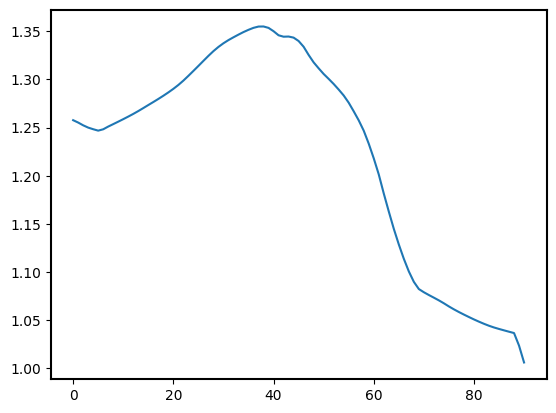

In [391]:
reconstructed_image2

array([[1.30132049, 1.32763143, 1.35394236, ..., 1.99246428, 1.98096611,
        1.96946793],
       [1.29897811, 1.32528076, 1.35158342, ..., 1.99418574, 1.98456657,
        1.9749474 ],
       [1.29663573, 1.3229301 , 1.34922448, ..., 1.9959072 , 1.98816703,
        1.98042686],
       ...,
       [0.99864764, 0.99915777, 0.99966791, ..., 1.10958728, 1.114917  ,
        1.12024673],
       [0.99854662, 0.99901723, 0.99948784, ..., 1.10659791, 1.11205836,
        1.11751881],
       [0.9984456 , 0.99887669, 0.99930777, ..., 1.10360854, 1.10919972,
        1.1147909 ]])

In [319]:
len(list(itertools.product( ggpl,tt )))

80

In [328]:
#len(img.ravel())


len(img.flatten())

80

In [327]:
x_new, y_new = np.meshgrid(gnew, tnew)

    # Interpolation
z_new = griddata(itertools.product(ggpl,tt), img.flatten(), (x_new, y_new), method='cubic')



ValueError: Unknown interpolation method 'cubic' for 0 dimensional data

In [317]:
def func(x, y):
    return x*(1-x)*np.cos(4*np.pi*x) * np.sin(4*np.pi*y**2)**2
points = rng.random((1000, 2))
values = func(points[:,0], points[:,1])

len(points), values.shape

(1000, (1000,))